

> IMTIAZ SETUP



In [ ]:
# ============================================================
# STEP 1 — Install dependencies
# ============================================================
!pip install kagglehub -q

# ============================================================
# STEP 2 — Download Dataset
# ============================================================
import kagglehub
import os

path = kagglehub.dataset_download("nageshsingh/dna-sequence-dataset")
print("Path to dataset files:", path)

# List files
for f in os.listdir(path):
    print(" -", f)

100%|██████████| 1.51M/1.51M [00:00<00:00, 35.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nageshsingh/dna-sequence-dataset/versions/1
 - example_dna.fa
 - human.txt
 - dog.txt
 - chimpanzee.txt


EDA

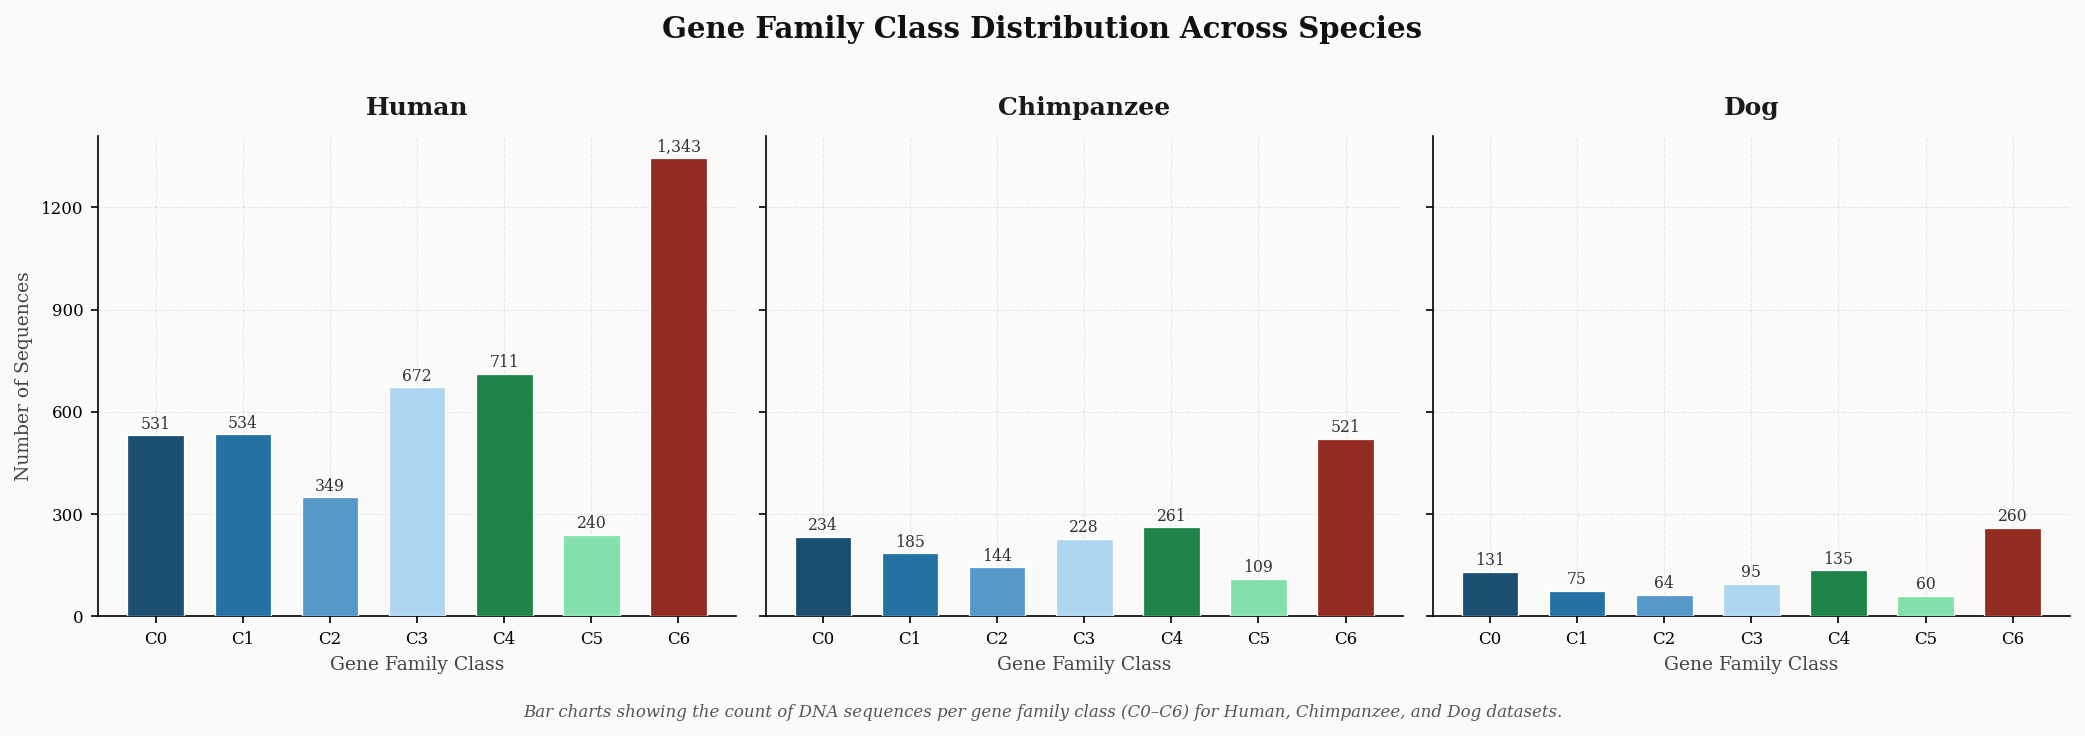

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

# ── Fonts & Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.5,
    'grid.linestyle':    '--',
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

# ── Palette ─────────────────────────────────────────────────────────────────────
SPECIES_COLORS = {
    'Human':      '#2C6E9B',   # steel blue
    'Chimpanzee': '#B5451B',   # terracotta
    'Dog':        '#4A7C59',   # forest green
}
CLASS_PALETTE = [
    '#1B4F72','#2471A3','#5499C7','#AED6F1',
    '#1D8348','#82E0AA','#922B21',
]
BACKGROUND = '#FAFAF8'

# ── Load Data ───────────────────────────────────────────────────────────────────
path = "/root/.cache/kagglehub/datasets/nageshsingh/dna-sequence-dataset/versions/1"
human_df = pd.read_table(os.path.join(path, 'human.txt'))
chimp_df  = pd.read_table(os.path.join(path, 'chimpanzee.txt'))
dog_df    = pd.read_table(os.path.join(path, 'dog.txt'))

species_data = {'Human': human_df, 'Chimpanzee': chimp_df, 'Dog': dog_df}
n_classes    = sorted(human_df['class'].unique())
class_labels = [f'Class {c}' for c in n_classes]

combined_df = pd.concat([human_df, chimp_df, dog_df], ignore_index=True)

# ── Helper ───────────────────────────────────────────────────────────────────────
def seq_lengths(df):
    return df['sequence'].str.len()


# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Class Distribution
# ════════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig1.patch.set_facecolor(BACKGROUND)

for ax, (name, df) in zip(axes, species_data.items()):
    counts = df['class'].value_counts().sort_index()
    bars = ax.bar(
        [f'C{c}' for c in counts.index],
        counts.values,
        color=[CLASS_PALETTE[i % len(CLASS_PALETTE)] for i in range(len(counts))],
        edgecolor='white', linewidth=0.6, width=0.65, zorder=3
    )
    # value labels
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 8, f'{int(h):,}',
                ha='center', va='bottom', fontsize=7.5, color='#333333')
    ax.set_facecolor(BACKGROUND)
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10, color='#1a1a1a')
    ax.set_xlabel('Gene Family Class', fontsize=9, color='#444444')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Number of Sequences', fontsize=9, color='#444444')

fig1.suptitle(
    'Gene Family Class Distribution Across Species',
    fontsize=14, fontweight='bold', y=1.01, color='#111111'
)
fig1.text(
    0.5, -0.03,
    'Bar charts showing the count of DNA sequences per gene family class (C0–C6) '
    'for Human, Chimpanzee, and Dog datasets.',
    ha='center', fontsize=8, color='#555555', style='italic'
)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', facecolor=BACKGROUND)
plt.show()

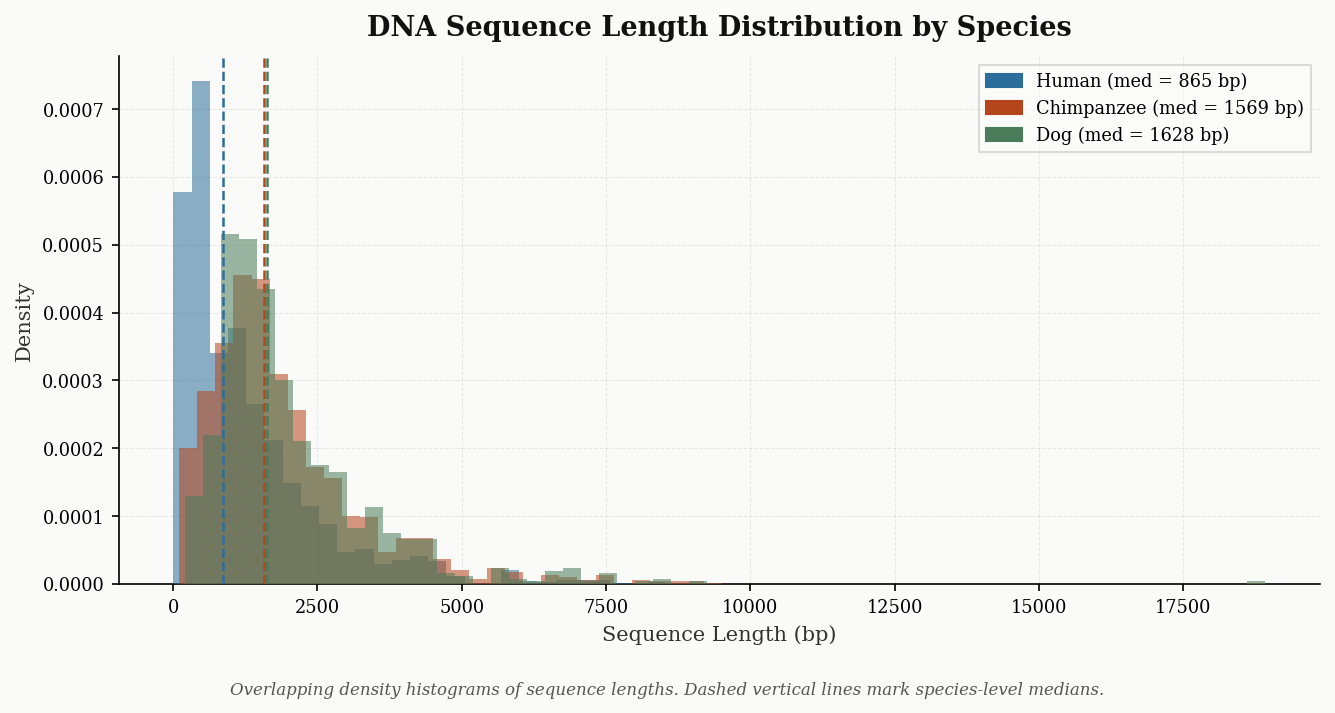

In [ ]:

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Sequence Length Distributions
# ════════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(9, 4.5))
fig2.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

for name, df in species_data.items():
    lengths = seq_lengths(df)
    ax.hist(
        lengths, bins=60, alpha=0.55,
        color=SPECIES_COLORS[name], label=name,
        edgecolor='none', density=True, zorder=3
    )
    ax.axvline(lengths.median(), color=SPECIES_COLORS[name],
               linestyle='--', linewidth=1.2, zorder=4)

ax.set_xlabel('Sequence Length (bp)', fontsize=10, color='#333333')
ax.set_ylabel('Density', fontsize=10, color='#333333')
ax.set_title('DNA Sequence Length Distribution by Species',
             fontsize=13, fontweight='bold', pad=10, color='#111111')
ax.tick_params(labelsize=8.5)

legend_patches = [
    mpatches.Patch(color=SPECIES_COLORS[n], label=f'{n} (med = {seq_lengths(d).median():.0f} bp)')
    for n, d in species_data.items()
]
ax.legend(handles=legend_patches, fontsize=8.5, framealpha=0.4,
          edgecolor='#aaaaaa', fancybox=False)

fig2.text(
    0.5, -0.04,
    'Overlapping density histograms of sequence lengths. Dashed vertical lines mark species-level medians.',
    ha='center', fontsize=8, color='#555555', style='italic'
)
plt.tight_layout()
plt.savefig('fig2_seq_length_dist.png', facecolor=BACKGROUND)
plt.show()

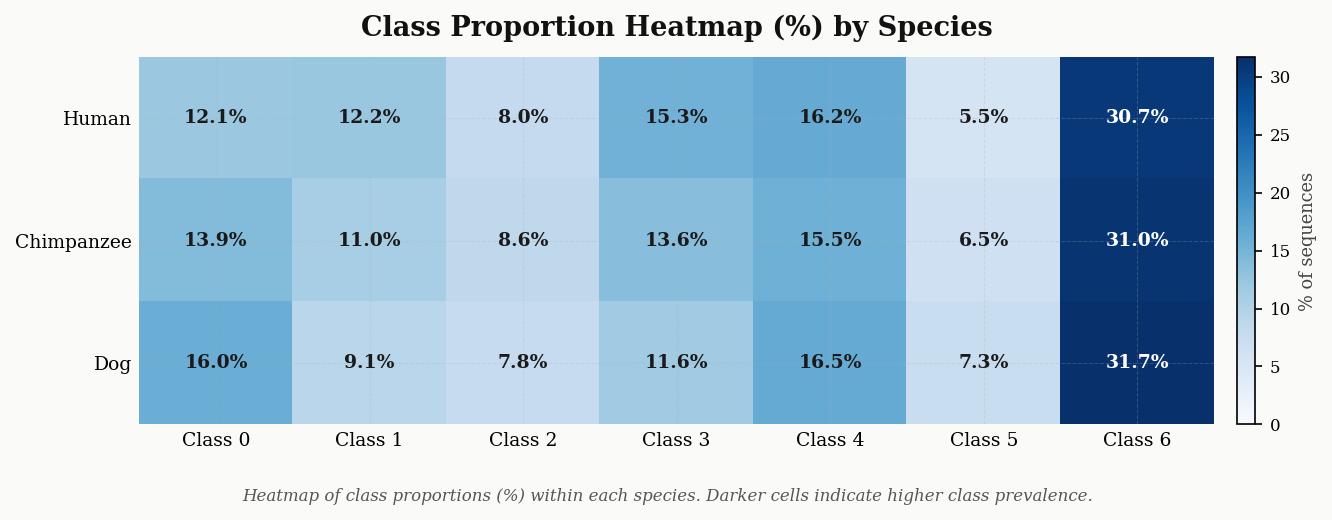

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Class Proportion Heatmap (species × class)
# ════════════════════════════════════════════════════════════════════════════════
prop_matrix = np.zeros((len(species_data), len(n_classes)))
for i, (name, df) in enumerate(species_data.items()):
    for j, cls in enumerate(n_classes):
        prop_matrix[i, j] = (df['class'] == cls).sum() / len(df) * 100

fig3, ax = plt.subplots(figsize=(9, 3.2))
fig3.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

im = ax.imshow(prop_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=prop_matrix.max())

for i in range(prop_matrix.shape[0]):
    for j in range(prop_matrix.shape[1]):
        val = prop_matrix[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white' if val > 25 else '#1a1a1a', fontweight='bold')

ax.set_xticks(range(len(n_classes)))
ax.set_xticklabels(class_labels, fontsize=9)
ax.set_yticks(range(len(species_data)))
ax.set_yticklabels(list(species_data.keys()), fontsize=9)
ax.set_title('Class Proportion Heatmap (%) by Species',
             fontsize=13, fontweight='bold', pad=10, color='#111111')

cbar = fig3.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('% of sequences', fontsize=8.5, color='#444444')
cbar.ax.tick_params(labelsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

fig3.text(
    0.5, -0.06,
    'Heatmap of class proportions (%) within each species. '
    'Darker cells indicate higher class prevalence.',
    ha='center', fontsize=8, color='#555555', style='italic'
)
plt.tight_layout()
plt.savefig('fig3_proportion_heatmap.png', facecolor=BACKGROUND)
plt.show()

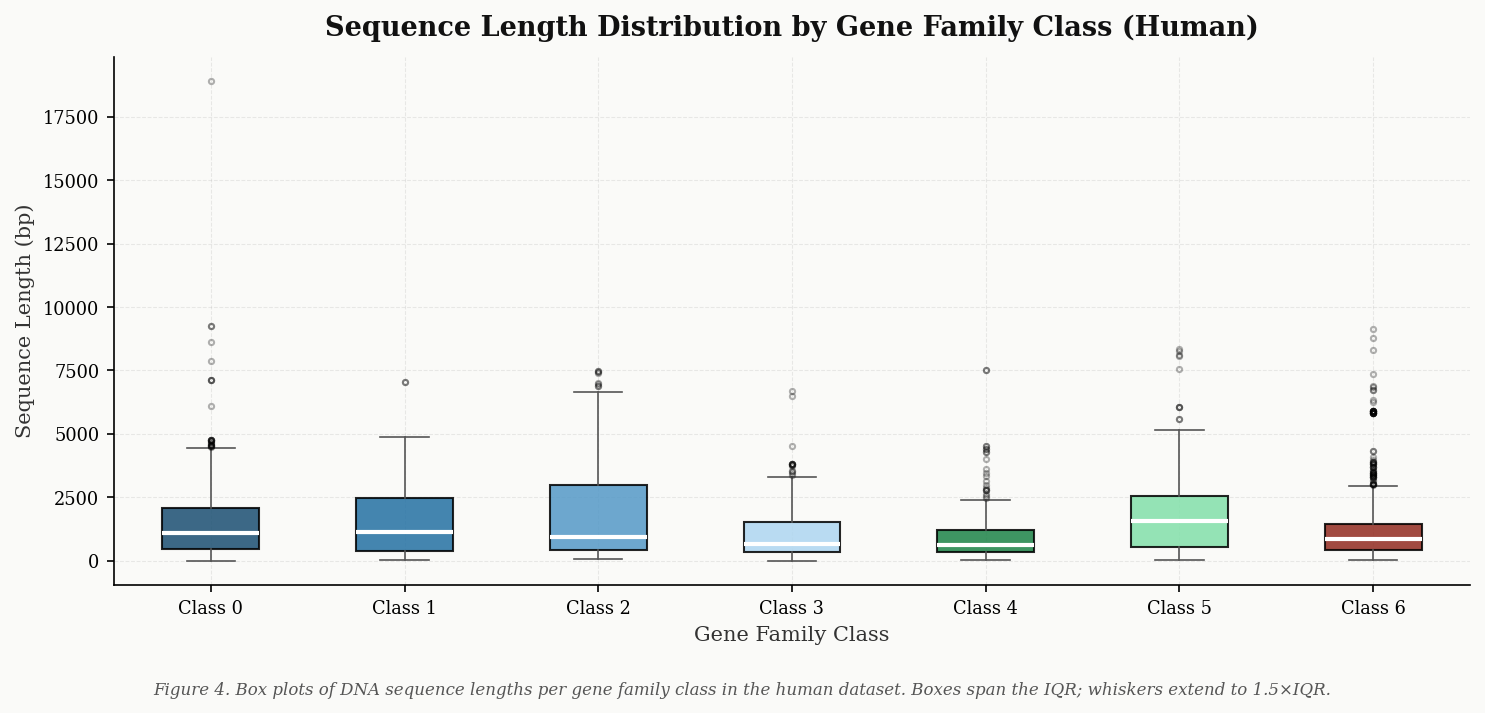

✓ All figures saved (fig1–fig4).


In [ ]:

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Sequence Length by Class (box plots, human only)
# ════════════════════════════════════════════════════════════════════════════════
fig4, ax = plt.subplots(figsize=(10, 4.5))
fig4.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

groups   = [human_df[human_df['class'] == c]['sequence'].str.len().values for c in n_classes]
bp = ax.boxplot(
    groups,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=0.8, color='#555'),
    capprops=dict(linewidth=0.8, color='#555'),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3, linestyle='none'),
    zorder=3
)
for patch, color in zip(bp['boxes'], CLASS_PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_xticks(range(1, len(n_classes)+1))
ax.set_xticklabels(class_labels, fontsize=9)
ax.set_xlabel('Gene Family Class', fontsize=10, color='#333333')
ax.set_ylabel('Sequence Length (bp)', fontsize=10, color='#333333')
ax.set_title('Sequence Length Distribution by Gene Family Class (Human)',
             fontsize=13, fontweight='bold', pad=10, color='#111111')
ax.tick_params(labelsize=8.5)

fig4.text(
    0.5, -0.04,
    'Figure 4. Box plots of DNA sequence lengths per gene family class in the human dataset. '
    'Boxes span the IQR; whiskers extend to 1.5×IQR.',
    ha='center', fontsize=8, color='#555555', style='italic'
)
plt.tight_layout()
plt.savefig('fig4_length_by_class.png', facecolor=BACKGROUND)
plt.show()

print("✓ All figures saved (fig1–fig4).")

In [ ]:
#EDA DONE

In [ ]:
import pandas as pd
import os
import re

path = "/root/.cache/kagglehub/datasets/nageshsingh/dna-sequence-dataset/versions/1"

human_df = pd.read_table(os.path.join(path, 'human.txt'))
chimp_df = pd.read_table(os.path.join(path, 'chimpanzee.txt'))
dog_df   = pd.read_table(os.path.join(path, 'dog.txt'))

# ── Styling helpers ────────────────────────────────────────────
RESET  = "\033[0m"
BOLD   = "\033[1m"
DIM    = "\033[2m"
CYAN   = "\033[36m"
GREEN  = "\033[32m"
YELLOW = "\033[33m"
RED    = "\033[31m"
BLUE   = "\033[34m"

def header(step, title):
    print(f"\n{BOLD}{CYAN}┌{'─'*54}┐{RESET}")
    print(f"{BOLD}{CYAN}│  Step {step}  {RESET}{BOLD}{title:<44}{CYAN}│{RESET}")
    print(f"{BOLD}{CYAN}└{'─'*54}┘{RESET}")

def row_log(name, before, after, reason):
    dropped = before - after
    color   = RED if dropped > 0 else GREEN
    symbol  = "▼" if dropped > 0 else "✓"
    print(f"  {BOLD}{name:<12}{RESET}  {DIM}{before:>5} → {RESET}{GREEN}{after:>5}{RESET}"
          f"  {color}{symbol} {dropped} {reason}{RESET}")

def section_done(msg=""):
    if msg:
        print(f"  {DIM}{msg}{RESET}")

# ═══════════════════════════════════════════════════════════════
# STEP 1 — Lowercase
# ═══════════════════════════════════════════════════════════════
header(1, "Lowercase All Sequences")
for df in [human_df, chimp_df, dog_df]:
    df['sequence'] = df['sequence'].str.lower()
section_done("All sequences normalised to lowercase (a/t/c/g).")

# ═══════════════════════════════════════════════════════════════
# STEP 2 — Remove invalid characters
# ═══════════════════════════════════════════════════════════════
header(2, "Remove Sequences with Invalid Characters")

def remove_invalid(df, name):
    before = len(df)
    df_clean = df[df['sequence'].str.fullmatch(r'[atcg]+')].reset_index(drop=True)
    row_log(name, before, len(df_clean), "invalid-char rows dropped")
    return df_clean

human_df = remove_invalid(human_df, "Human")
chimp_df = remove_invalid(chimp_df, "Chimpanzee")
dog_df   = remove_invalid(dog_df,   "Dog")
section_done("Retained only sequences containing {a, t, c, g}.")

# ═══════════════════════════════════════════════════════════════
# STEP 3 — Drop duplicates
# ═══════════════════════════════════════════════════════════════
header(3, "Remove Duplicate Sequences")

for name, df in [("Human", human_df), ("Chimpanzee", chimp_df), ("Dog", dog_df)]:
    before = len(df)
    df.drop_duplicates(subset='sequence', inplace=True)
    df.reset_index(drop=True, inplace=True)
    row_log(name, before, len(df), "duplicates removed")

section_done("Exact sequence duplicates removed.")

# ═══════════════════════════════════════════════════════════════
# STEP 4 — Drop nulls
# ═══════════════════════════════════════════════════════════════
header(4, "Drop Null Values")

for name, df in [("Human", human_df), ("Chimpanzee", chimp_df), ("Dog", dog_df)]:
    before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    row_log(name, before, len(df), "null rows removed")

section_done("Missing values cleared across all species.")

# ═══════════════════════════════════════════════════════════════
# STEP 5 — k-mer Feature Extraction  (k = 6)
# ═══════════════════════════════════════════════════════════════
header(5, "k-mer Feature Extraction  (k = 6)")

def get_kmers(sequence, k=6):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

def to_kmer_strings(df, k=6):
    df = df.copy()
    df['words'] = df['sequence'].apply(lambda s: ' '.join(get_kmers(s, k)))
    return df

human_df = to_kmer_strings(human_df)
chimp_df = to_kmer_strings(chimp_df)
dog_df   = to_kmer_strings(dog_df)

section_done("Sliding window of k=6 applied → 'words' column added.")

# ═══════════════════════════════════════════════════════════════
# STEP 6 — Final Summary
# ═══════════════════════════════════════════════════════════════
header(6, "Final Dataset Summary")

print(f"\n  {'Species':<12}  {'Rows':>6}  {'Cols':>4}  {'Columns'}")
print(f"  {'─'*12}  {'─'*6}  {'─'*4}  {'─'*30}")
for name, df in [("Human", human_df), ("Chimpanzee", chimp_df), ("Dog", dog_df)]:
    cols_str = ", ".join(df.columns)
    print(f"  {BOLD}{name:<12}{RESET}  {GREEN}{len(df):>6}{RESET}  {len(df.columns):>4}  {DIM}{cols_str}{RESET}")

print(f"\n  {YELLOW}Sample k-mer string {DIM}(Human, row 0, first 120 chars){RESET}")
print(f"  {DIM}{'─'*54}{RESET}")
sample = human_df['words'].iloc[0][:120]
print(f"  {CYAN}{sample}{RESET} {DIM}...{RESET}\n")


┌──────────────────────────────────────────────────────┐
│  Step 1  Lowercase All Sequences                     │
└──────────────────────────────────────────────────────┘
  All sequences normalised to lowercase (a/t/c/g).

┌──────────────────────────────────────────────────────┐
│  Step 2  Remove Sequences with Invalid Characters    │
└──────────────────────────────────────────────────────┘
  Human          4380 →  4020  ▼ 360 invalid-char rows dropped
  Chimpanzee     1682 →  1680  ▼ 2 invalid-char rows dropped
  Dog             820 →   803  ▼ 17 invalid-char rows dropped
  Retained only sequences containing {a, t, c, g}.

┌──────────────────────────────────────────────────────┐
│  Step 3  Remove Duplicate Sequences                  │
└──────────────────────────────────────────────────────┘
  Human          4020 →  3295  ▼ 725 duplicates removed
  Chimpanzee     1680 →  1673  ▼ 7 duplicates removed
  Dog             803 →   800  ▼ 3 duplicates removed
  Exact sequence duplicates remo

K MER FEATURE Engineering


══════════════════════════════════════════════════════════════
  FIG A · Top-20 Most Frequent 6-mers per Species
══════════════════════════════════════════════════════════════

  ✓ Saved → figA_top20_kmers.png


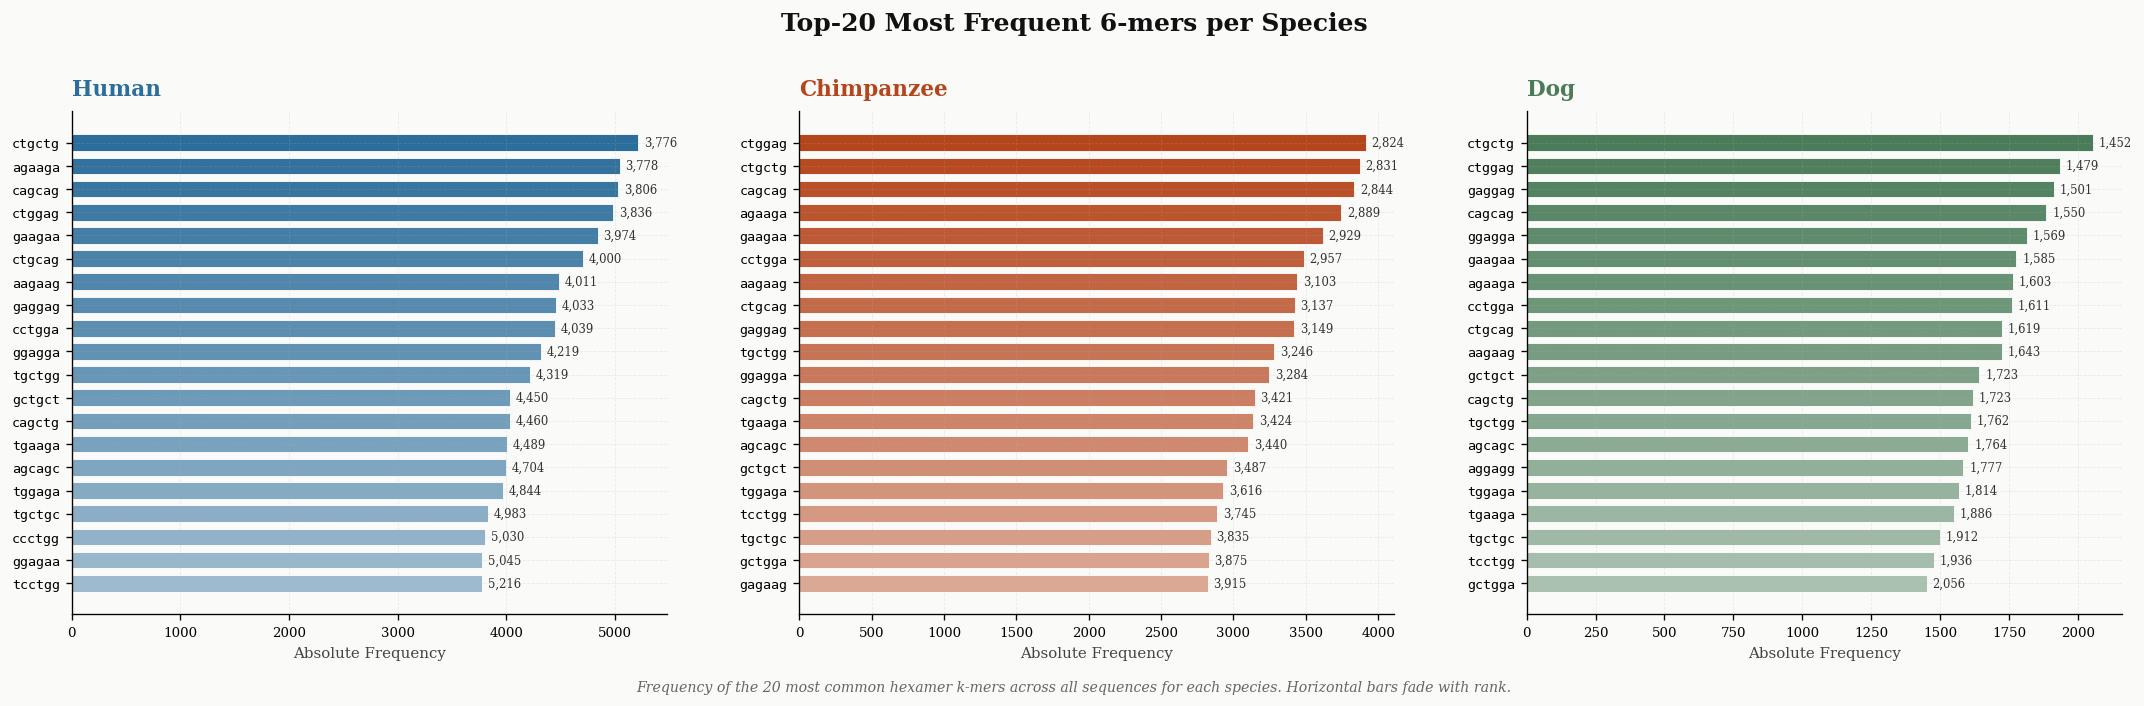


══════════════════════════════════════════════════════════════
  FIG B · Vocabulary Size & Unique k-mers per Sequence
══════════════════════════════════════════════════════════════

  ✓ Saved → figB_vocab_size.png


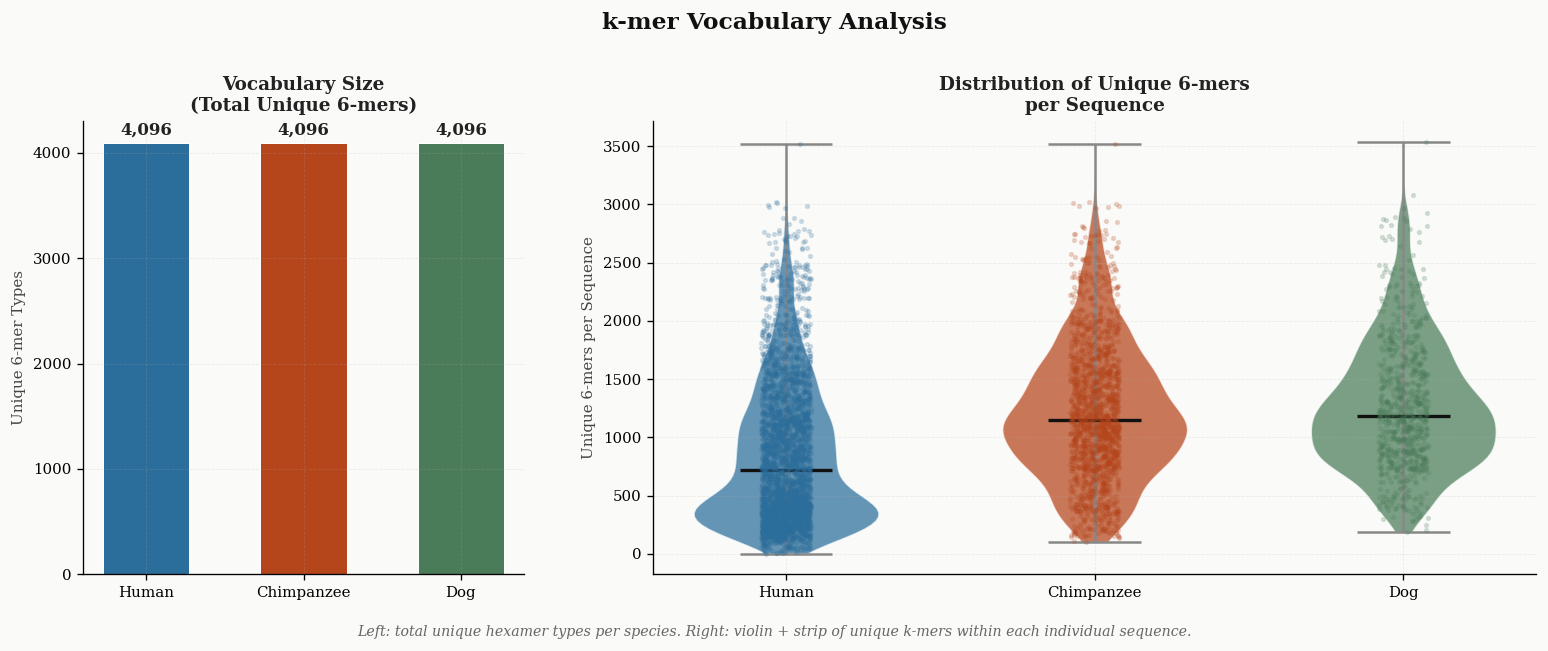


══════════════════════════════════════════════════════════════
  FIG C · Shared vs Unique k-mer Sets (Venn Diagram)
══════════════════════════════════════════════════════════════

  ✓ Saved → figC_venn_kmers.png


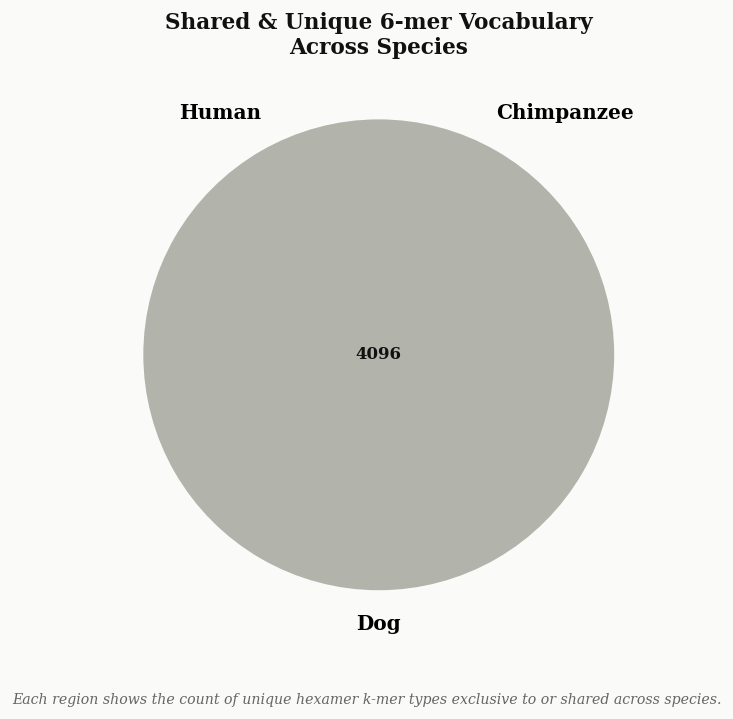


══════════════════════════════════════════════════════════════
  FIG D · Class-wise Top-10 k-mer Heatmap (Human)
══════════════════════════════════════════════════════════════

  ✓ Saved → figD_classwise_heatmap.png


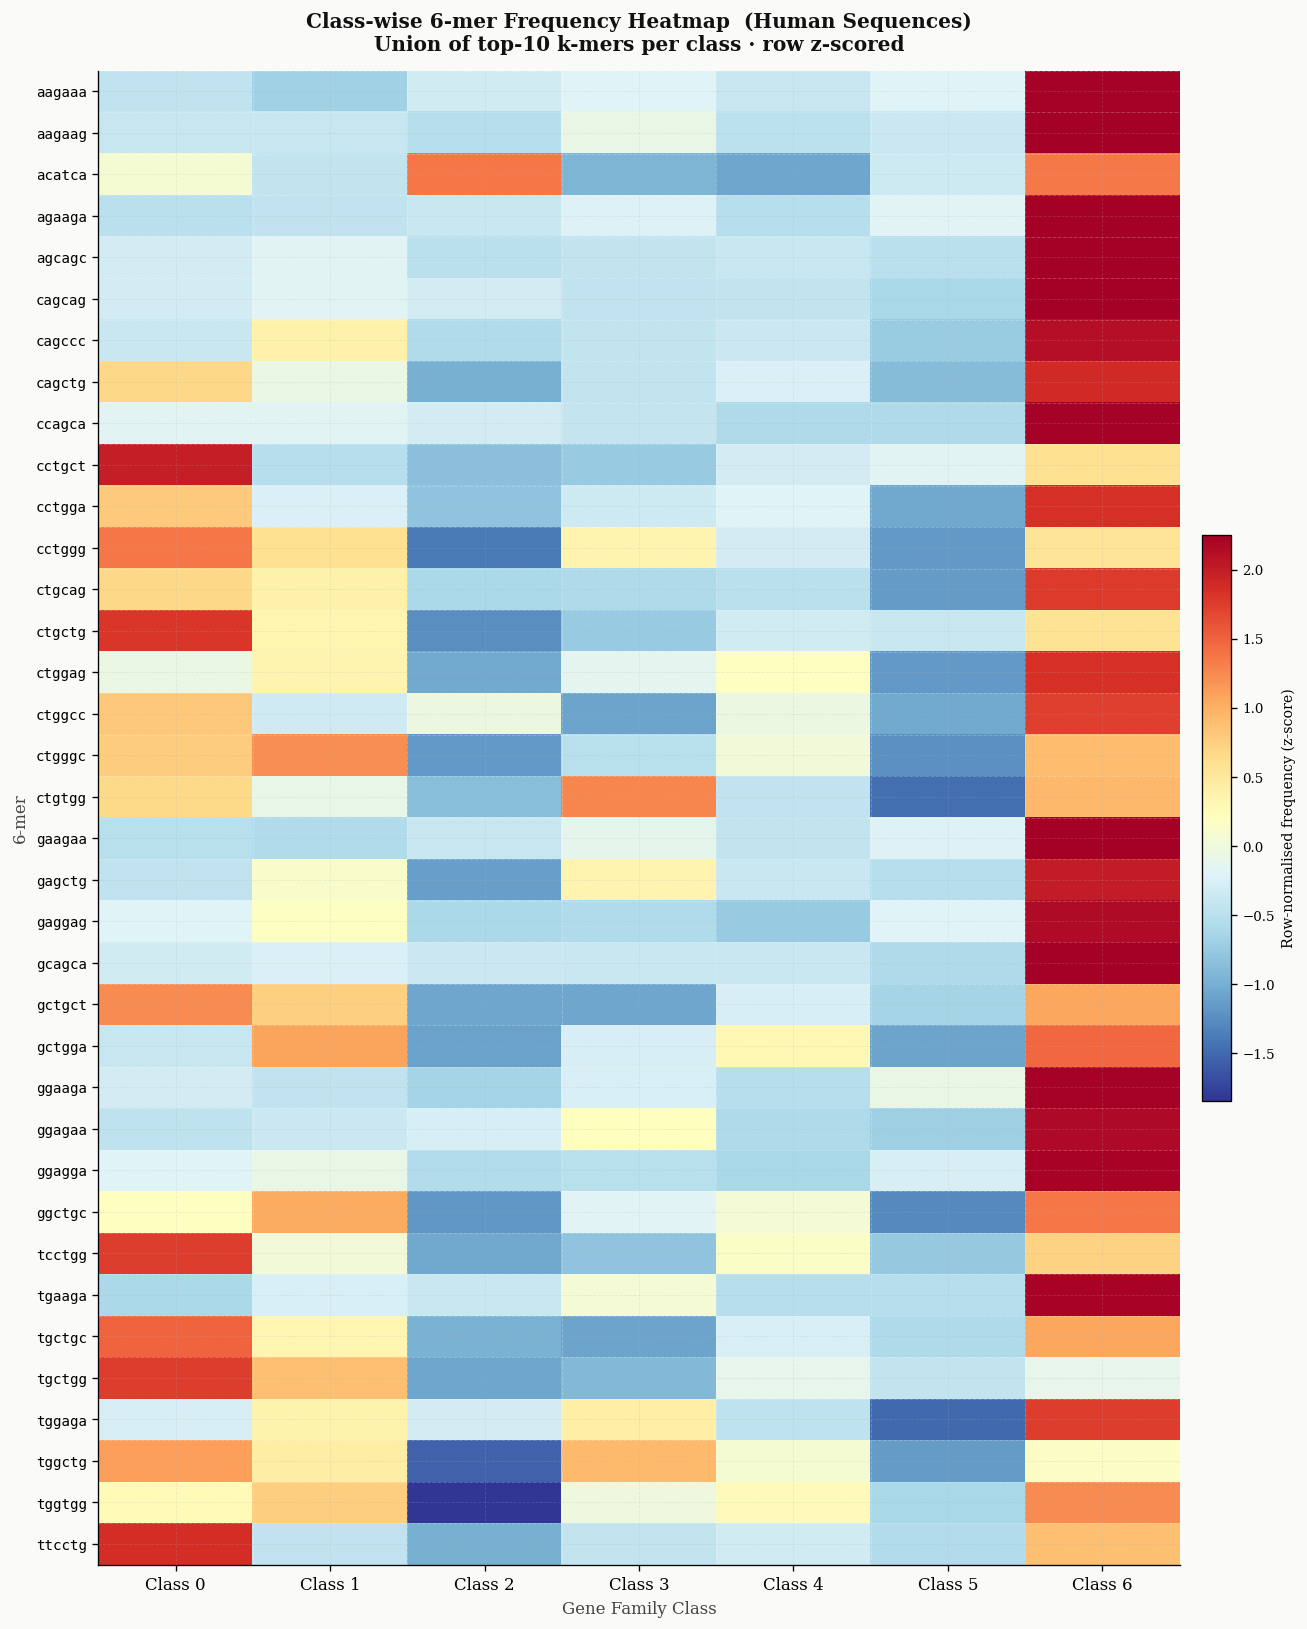


══════════════════════════════════════════════════════════════
  FIG E · PCA of k-mer Count Feature Matrix (Human)
══════════════════════════════════════════════════════════════

  ✓ Saved → figE_pca_kmer.png


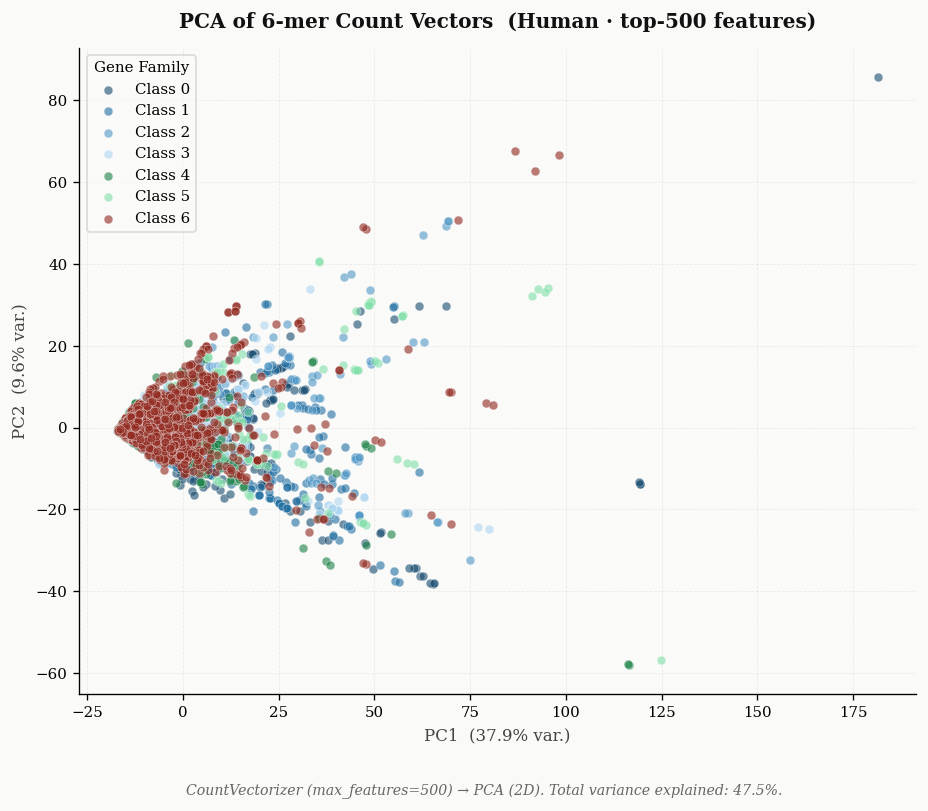


══════════════════════════════════════════════════════════════
  FIG F · TF-IDF PCA · Scree + 2D Scatter (Human)
══════════════════════════════════════════════════════════════

  ✓ Saved → figF_tfidf_pca.png


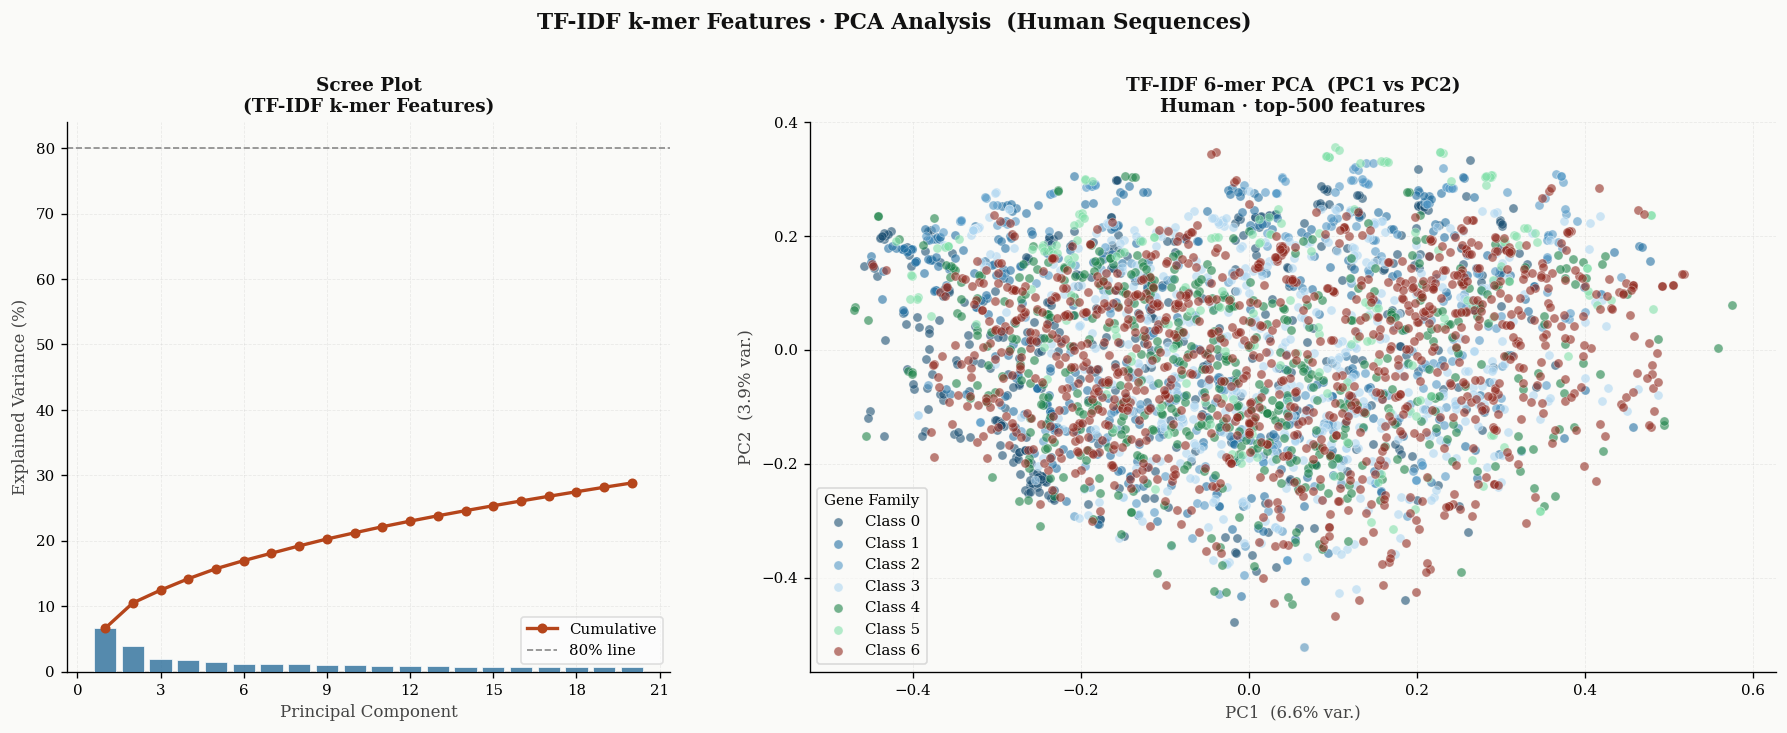


══════════════════════════════════════════════════════════════
  FIG G · Total k-mers per Sequence by Class (Human)
══════════════════════════════════════════════════════════════

  ✓ Saved → figG_kmer_count_class.png


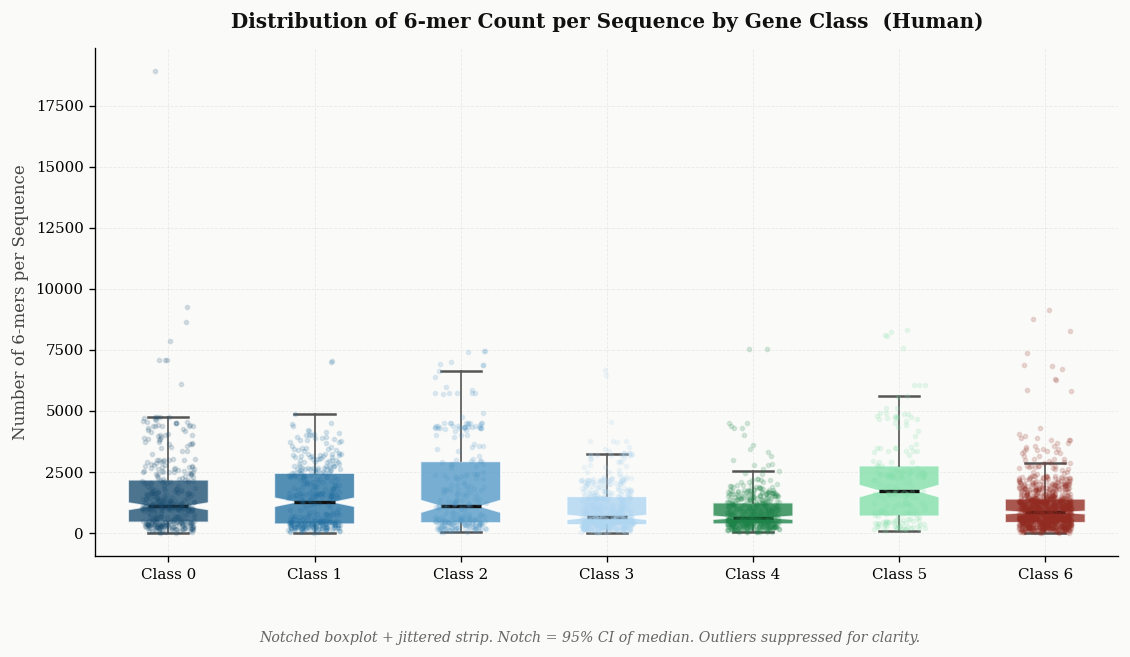


══════════════════════════════════════════════════════════════
  FIG H · Cross-species Normalised Frequency Heatmap (Top-40 k-mers)
══════════════════════════════════════════════════════════════

  ✓ Saved → figH_cross_species_heatmap.png


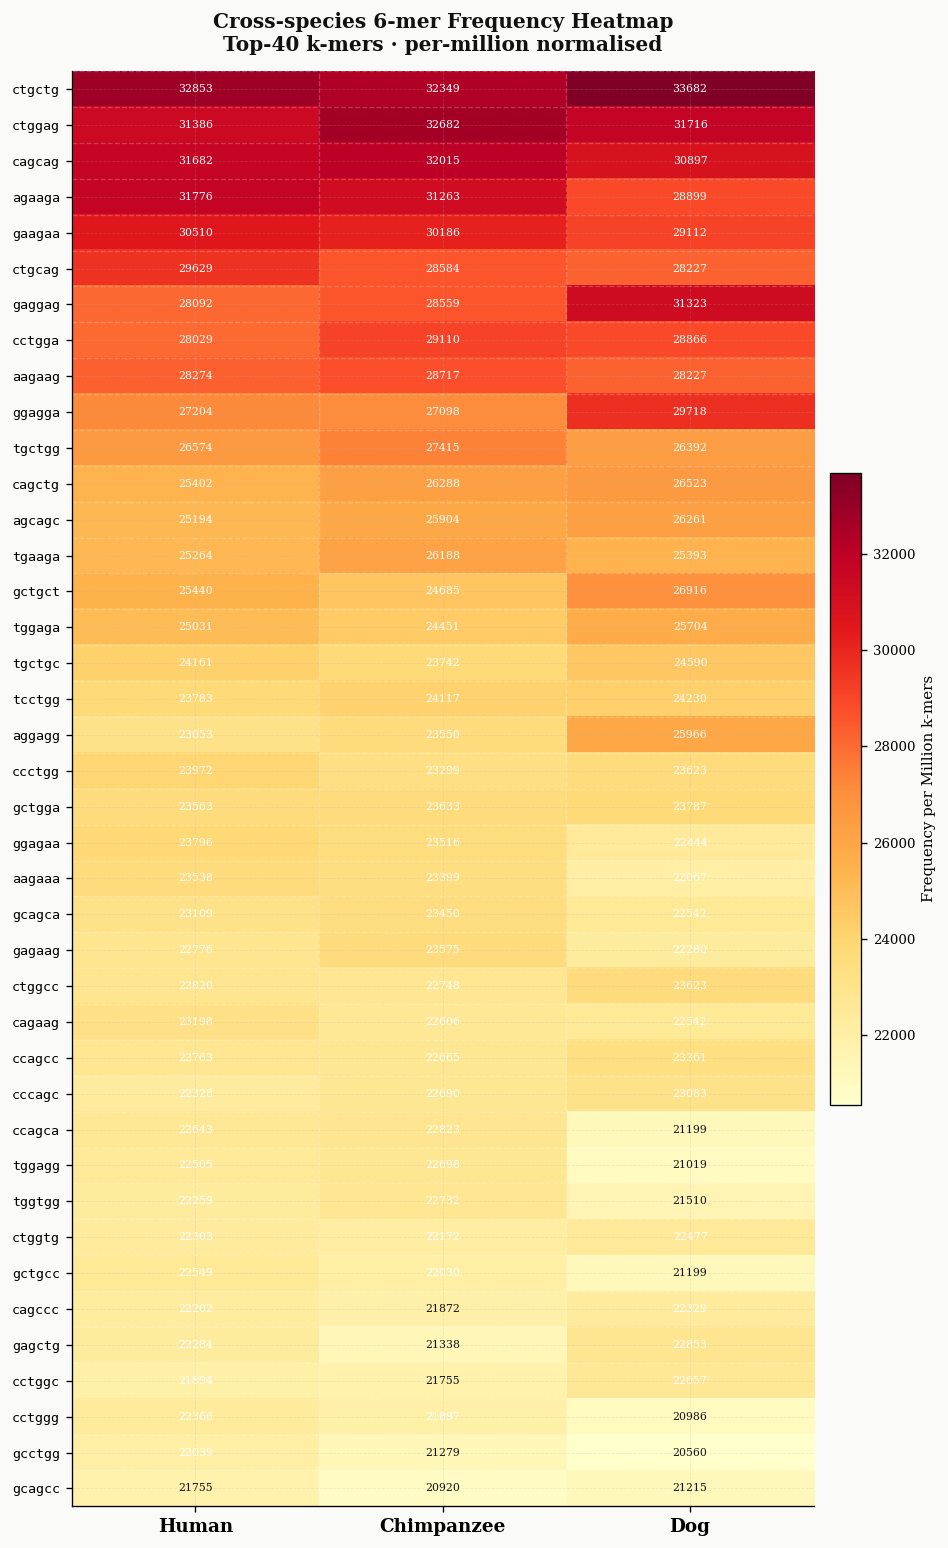


══════════════════════════════════════════════════════════════
  All k-mer Feature Engineering Figures Saved at 300 DPI
══════════════════════════════════════════════════════════════

  File                                   Description
  ────────────────────────────────────── ──────────────────────────────────────────
  figA_top20_kmers.png                   Top-20 most frequent 6-mers per species
  figB_vocab_size.png                    Vocabulary size & unique k-mers per sequence
  figC_venn_kmers.png                    Shared vs unique k-mer sets (Venn)
  figD_classwise_heatmap.png             Class-wise top-10 k-mer heatmap (Human)
  figE_pca_kmer.png                      PCA of CountVectorizer k-mer features (Human)
  figF_tfidf_pca.png                     TF-IDF PCA scree + 2D scatter (Human)
  figG_kmer_count_class.png              Distribution of k-mer count by class (Human)
  figH_cross_species_heatmap.png         Cross-species normalised frequency heatmap



In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         K-MER FEATURE ENGINEERING  ·  Full Visualization Suite              ║
# ║         Paste this cell AFTER your preprocessing block in Colab             ║
# ║         All figures saved at 300 DPI                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
from matplotlib_venn import venn3          # pip install matplotlib-venn
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── install venn if needed ────────────────────────────────────────────────────
try:
    from matplotlib_venn import venn3
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib-venn", "-q"])
    from matplotlib_venn import venn3

# ═══════════════════════════════════════════════════════════════════════════════
# GLOBAL STYLE
# ═══════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['DejaVu Serif'],
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'axes.grid'        : True,
    'grid.alpha'       : 0.22,
    'grid.linewidth'   : 0.5,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 120,          # screen preview
    'savefig.dpi'      : 300,          # disk output
    'savefig.bbox'     : 'tight',
})

BG   = '#FAFAF8'
DARK = '#1a1a2e'

SPECIES_COLORS = {
    'Human'     : '#2C6E9B',
    'Chimpanzee': '#B5451B',
    'Dog'       : '#4A7C59',
}
CLASS_PAL = ['#1B4F72','#2471A3','#5499C7','#AED6F1',
             '#1D8348','#82E0AA','#922B21']

# ── convenience ───────────────────────────────────────────────────────────────
def save(name, fig):
    fig.savefig(name, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f"  ✓ Saved → {name}")

def kmer_counter(df, col='words'):
    """Flat Counter over all k-mers in a DataFrame."""
    ctr = Counter()
    for row in df[col]:
        ctr.update(row.split())
    return ctr

def section_banner(title):
    w = 62
    print(f"\n\033[1m\033[36m{'═'*w}\033[0m")
    print(f"\033[1m\033[36m  {title}\033[0m")
    print(f"\033[1m\033[36m{'═'*w}\033[0m\n")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE A — Top-20 Most Frequent k-mers per Species
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG A · Top-20 Most Frequent 6-mers per Species")

species_dfs = {'Human': human_df, 'Chimpanzee': chimp_df, 'Dog': dog_df}
counters    = {sp: kmer_counter(df) for sp, df in species_dfs.items()}

fig_a, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig_a.patch.set_facecolor(BG)

for ax, (sp, ctr) in zip(axes, counters.items()):
    top20  = ctr.most_common(20)
    kmers  = [k for k, _ in top20]
    counts = [v for _, v in top20]
    color  = SPECIES_COLORS[sp]

    # gradient alpha
    alphas = np.linspace(1.0, 0.45, 20)
    colors = [mcolors.to_rgba(color, alpha=a) for a in alphas]

    bars = ax.barh(range(19, -1, -1), counts, color=colors,
                   edgecolor='white', linewidth=0.5, height=0.72)
    ax.set_yticks(range(20))
    ax.set_yticklabels(kmers[::-1], fontsize=8.5, fontfamily='monospace')
    ax.set_xlabel('Absolute Frequency', fontsize=9, color='#444')
    ax.set_title(sp, fontsize=13, fontweight='bold', pad=10,
                 color=color, loc='left')
    ax.set_facecolor(BG)
    ax.tick_params(labelsize=8)

    # value labels
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=7, color='#333')

fig_a.suptitle('Top-20 Most Frequent 6-mers per Species',
               fontsize=15, fontweight='bold', y=1.01, color='#111')
fig_a.text(0.5, -0.02,
           'Frequency of the 20 most common hexamer k-mers across all sequences '
           'for each species. Horizontal bars fade with rank.',
           ha='center', fontsize=8.5, color='#666', style='italic')
plt.tight_layout(w_pad=3.5)
save('figA_top20_kmers.png', fig_a)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE B — k-mer Vocabulary Size & Unique-kmer Distribution
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG B · Vocabulary Size & Unique k-mers per Sequence")

fig_b, (ax_b1, ax_b2) = plt.subplots(1, 2, figsize=(13, 5),
                                      gridspec_kw={'width_ratios': [1, 2]})
fig_b.patch.set_facecolor(BG)

# --- Left: vocabulary sizes (bar) ---
vocab_sizes = {sp: len(ctr) for sp, ctr in counters.items()}
sp_names    = list(vocab_sizes.keys())
sp_vals     = list(vocab_sizes.values())
bar_colors  = [SPECIES_COLORS[s] for s in sp_names]

bars = ax_b1.bar(sp_names, sp_vals, color=bar_colors,
                 edgecolor='white', linewidth=0.6, width=0.55)
for bar, val in zip(bars, sp_vals):
    ax_b1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
               f'{val:,}', ha='center', fontsize=10, fontweight='bold', color='#222')
ax_b1.set_ylabel('Unique 6-mer Types', fontsize=9, color='#444')
ax_b1.set_title('Vocabulary Size\n(Total Unique 6-mers)', fontsize=11,
                fontweight='bold', color='#222')
ax_b1.set_facecolor(BG)
ax_b1.tick_params(labelsize=9)
ax_b1.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

# --- Right: violin of unique k-mers per sequence ---
unique_per_seq = {sp: df['words'].apply(lambda w: len(set(w.split())))
                  for sp, df in species_dfs.items()}
data_list  = [unique_per_seq[sp].values for sp in sp_names]
positions  = [1, 2, 3]

vp = ax_b2.violinplot(data_list, positions=positions,
                      showmedians=True, showextrema=True,
                      widths=0.6)
for i, (body, sp) in enumerate(zip(vp['bodies'], sp_names)):
    body.set_facecolor(SPECIES_COLORS[sp])
    body.set_alpha(0.72)
    body.set_edgecolor('white')

vp['cmedians'].set_color('#111')
vp['cmedians'].set_linewidth(2)
vp['cbars'].set_color('#888')
vp['cmins'].set_color('#888')
vp['cmaxes'].set_color('#888')

# overlay strip jitter
for i, (sp, pos) in enumerate(zip(sp_names, positions)):
    y   = unique_per_seq[sp].values
    jit = np.random.uniform(-0.08, 0.08, len(y))
    ax_b2.scatter(pos + jit, y, alpha=0.18, s=5,
                  color=SPECIES_COLORS[sp], zorder=3)

ax_b2.set_xticks(positions)
ax_b2.set_xticklabels(sp_names, fontsize=10)
ax_b2.set_ylabel('Unique 6-mers per Sequence', fontsize=9, color='#444')
ax_b2.set_title('Distribution of Unique 6-mers\nper Sequence', fontsize=11,
                fontweight='bold', color='#222')
ax_b2.set_facecolor(BG)
ax_b2.tick_params(labelsize=9)

fig_b.suptitle('k-mer Vocabulary Analysis', fontsize=14,
               fontweight='bold', y=1.01, color='#111')
fig_b.text(0.5, -0.03,
           'Left: total unique hexamer types per species. '
           'Right: violin + strip of unique k-mers within each individual sequence.',
           ha='center', fontsize=8.5, color='#666', style='italic')
plt.tight_layout(w_pad=3.5)
save('figB_vocab_size.png', fig_b)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE C — Shared vs Unique k-mers (Venn)
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG C · Shared vs Unique k-mer Sets (Venn Diagram)")

sets = {sp: set(ctr.keys()) for sp, ctr in counters.items()}
sp_list = list(sets.keys())

fig_c, ax_c = plt.subplots(figsize=(8, 6))
fig_c.patch.set_facecolor(BG)
ax_c.set_facecolor(BG)

v = venn3(
    [sets['Human'], sets['Chimpanzee'], sets['Dog']],
    set_labels=('Human', 'Chimpanzee', 'Dog'),
    set_colors=[SPECIES_COLORS['Human'],
                SPECIES_COLORS['Chimpanzee'],
                SPECIES_COLORS['Dog']],
    alpha=0.55,
    ax=ax_c
)

# style labels
for label in v.set_labels:
    if label:
        label.set_fontsize(12)
        label.set_fontweight('bold')
for label in v.subset_labels:
    if label:
        label.set_fontsize(10)
        label.set_fontweight('bold')
        label.set_color('#111')

ax_c.set_title('Shared & Unique 6-mer Vocabulary\nAcross Species',
               fontsize=13, fontweight='bold', color='#111', pad=14)
fig_c.text(0.5, 0.01,
           'Each region shows the count of unique hexamer k-mer types '
           'exclusive to or shared across species.',
           ha='center', fontsize=8.5, color='#666', style='italic')
save('figC_venn_kmers.png', fig_c)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE D — Class-wise Top-10 k-mers (Heatmap, Human only)
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG D · Class-wise Top-10 k-mer Heatmap (Human)")

classes     = sorted(human_df['class'].unique())
class_ctrs  = {}
for cls in classes:
    sub = human_df[human_df['class'] == cls]
    class_ctrs[cls] = kmer_counter(sub)

# union of top-10 per class
top_per_class = {}
union_kmers   = set()
for cls, ctr in class_ctrs.items():
    top = [k for k, _ in ctr.most_common(10)]
    top_per_class[cls] = top
    union_kmers.update(top)

union_kmers = sorted(union_kmers)
heat_df = pd.DataFrame(
    {cls: {km: class_ctrs[cls].get(km, 0) for km in union_kmers}
     for cls in classes}
)
# row-normalise (z-score per k-mer for contrast)
heat_norm = heat_df.sub(heat_df.mean(axis=1), axis=0).div(
    heat_df.std(axis=1).replace(0, 1), axis=0)

fig_d, ax_d = plt.subplots(figsize=(11, max(6, len(union_kmers)*0.38)))
fig_d.patch.set_facecolor(BG)
ax_d.set_facecolor(BG)

im = ax_d.imshow(heat_norm.values, aspect='auto',
                 cmap='RdYlBu_r', interpolation='nearest')
cbar = fig_d.colorbar(im, ax=ax_d, fraction=0.025, pad=0.02)
cbar.set_label('Row-normalised frequency (z-score)', fontsize=8.5)
cbar.ax.tick_params(labelsize=8)

ax_d.set_xticks(range(len(classes)))
ax_d.set_xticklabels([f'Class {c}' for c in classes], fontsize=10)
ax_d.set_yticks(range(len(union_kmers)))
ax_d.set_yticklabels(union_kmers, fontsize=8.5, fontfamily='monospace')
ax_d.set_xlabel('Gene Family Class', fontsize=10, color='#444')
ax_d.set_ylabel('6-mer', fontsize=10, color='#444')
ax_d.set_title('Class-wise 6-mer Frequency Heatmap  (Human Sequences)\n'
               'Union of top-10 k-mers per class · row z-scored',
               fontsize=12, fontweight='bold', color='#111', pad=12)

# grid lines
ax_d.set_xticks(np.arange(-.5, len(classes), 1), minor=True)
ax_d.set_yticks(np.arange(-.5, len(union_kmers), 1), minor=True)
ax_d.grid(which='minor', color='white', linewidth=0.6)
ax_d.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
save('figD_classwise_heatmap.png', fig_d)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE E — CountVectorizer Feature Matrix + PCA (2D)
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG E · PCA of k-mer Count Feature Matrix (Human)")

# Vectorise human sequences
cv    = CountVectorizer(analyzer='word', ngram_range=(1,1), max_features=500)
X_h   = cv.fit_transform(human_df['words']).toarray()
y_h   = human_df['class'].values

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_h)

fig_e, ax_e = plt.subplots(figsize=(9, 7))
fig_e.patch.set_facecolor(BG)
ax_e.set_facecolor(BG)

for cls, color in zip(sorted(np.unique(y_h)), CLASS_PAL):
    mask = y_h == cls
    ax_e.scatter(X_pca[mask, 0], X_pca[mask, 1],
                 s=28, alpha=0.62, color=color,
                 label=f'Class {cls}', edgecolors='white', linewidths=0.3,
                 zorder=3)

ax_e.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var.)',
                fontsize=10, color='#444')
ax_e.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% var.)',
                fontsize=10, color='#444')
ax_e.set_title('PCA of 6-mer Count Vectors  (Human · top-500 features)',
               fontsize=12, fontweight='bold', color='#111', pad=12)
leg = ax_e.legend(title='Gene Family', fontsize=9, title_fontsize=9,
                  framealpha=0.7, edgecolor='#ccc', loc='best')
leg.get_frame().set_facecolor(BG)
ax_e.tick_params(labelsize=9)

fig_e.text(0.5, -0.01,
           f'CountVectorizer (max_features=500) → PCA (2D). '
           f'Total variance explained: '
           f'{sum(pca.explained_variance_ratio_[:2])*100:.1f}%.',
           ha='center', fontsize=8.5, color='#666', style='italic')
save('figE_pca_kmer.png', fig_e)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE F — TF-IDF PCA + Explained Variance Scree (Human)
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG F · TF-IDF PCA · Scree + 2D Scatter (Human)")

tfidf  = TfidfVectorizer(analyzer='word', ngram_range=(1,1), max_features=500)
X_tf   = tfidf.fit_transform(human_df['words']).toarray()

pca_tf = PCA(n_components=min(20, X_tf.shape[1]), random_state=42)
X_tf_pca = pca_tf.fit_transform(X_tf)
ev_ratio = pca_tf.explained_variance_ratio_

fig_f, (ax_f1, ax_f2) = plt.subplots(1, 2, figsize=(15, 6),
                                       gridspec_kw={'width_ratios': [1, 1.6]})
fig_f.patch.set_facecolor(BG)

# ── Scree plot ──
comps = range(1, len(ev_ratio)+1)
ax_f1.bar(comps, ev_ratio*100, color='#2C6E9B', alpha=0.8,
          edgecolor='white', linewidth=0.5, zorder=3)
ax_f1.plot(comps, np.cumsum(ev_ratio)*100,
           color='#B5451B', linewidth=2, marker='o', markersize=5, zorder=4,
           label='Cumulative')
ax_f1.axhline(80, color='#888', linewidth=1, linestyle='--', label='80% line')
ax_f1.set_xlabel('Principal Component', fontsize=10, color='#444')
ax_f1.set_ylabel('Explained Variance (%)', fontsize=10, color='#444')
ax_f1.set_title('Scree Plot\n(TF-IDF k-mer Features)', fontsize=11,
                fontweight='bold', color='#111')
ax_f1.set_facecolor(BG)
ax_f1.tick_params(labelsize=9)
ax_f1.legend(fontsize=9, framealpha=0.6, edgecolor='#ccc')
ax_f1.xaxis.set_major_locator(MaxNLocator(integer=True))

# ── 2D scatter (PC1 vs PC2) ──
for cls, color in zip(sorted(np.unique(y_h)), CLASS_PAL):
    mask = y_h == cls
    ax_f2.scatter(X_tf_pca[mask, 0], X_tf_pca[mask, 1],
                  s=30, alpha=0.60, color=color,
                  label=f'Class {cls}', edgecolors='white', linewidths=0.3,
                  zorder=3)

ax_f2.set_xlabel(f'PC1  ({ev_ratio[0]*100:.1f}% var.)', fontsize=10, color='#444')
ax_f2.set_ylabel(f'PC2  ({ev_ratio[1]*100:.1f}% var.)', fontsize=10, color='#444')
ax_f2.set_title('TF-IDF 6-mer PCA  (PC1 vs PC2)\nHuman · top-500 features',
                fontsize=11, fontweight='bold', color='#111')
ax_f2.set_facecolor(BG)
ax_f2.tick_params(labelsize=9)
leg2 = ax_f2.legend(title='Gene Family', fontsize=9, title_fontsize=9,
                    framealpha=0.7, edgecolor='#ccc')
leg2.get_frame().set_facecolor(BG)

fig_f.suptitle('TF-IDF k-mer Features · PCA Analysis  (Human Sequences)',
               fontsize=13, fontweight='bold', y=1.01, color='#111')
plt.tight_layout(w_pad=4)
save('figF_tfidf_pca.png', fig_f)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE G — k-mer Count per Sequence (box plots, all 3 species combined)
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG G · Total k-mers per Sequence by Class (Human)")

human_df['n_kmers'] = human_df['words'].apply(lambda w: len(w.split()))
classes_sorted = sorted(human_df['class'].unique())

fig_g, ax_g = plt.subplots(figsize=(11, 5.5))
fig_g.patch.set_facecolor(BG)
ax_g.set_facecolor(BG)

bp_data   = [human_df[human_df['class']==c]['n_kmers'].values for c in classes_sorted]
positions = list(range(len(classes_sorted)))

bp = ax_g.boxplot(
    bp_data,
    positions=positions,
    patch_artist=True,
    notch=True,
    widths=0.55,
    showfliers=False,
    medianprops=dict(color='#111', linewidth=2),
    whiskerprops=dict(color='#555', linewidth=1),
    capprops=dict(color='#555', linewidth=1.5),
)

for patch, color in zip(bp['boxes'], CLASS_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.78)
    patch.set_edgecolor('white')

# overlay strip jitter
for i, (cls, color) in enumerate(zip(classes_sorted, CLASS_PAL)):
    y   = human_df[human_df['class']==cls]['n_kmers'].values
    jit = np.random.uniform(-0.18, 0.18, len(y))
    ax_g.scatter(i + jit, y, alpha=0.15, s=6, color=color, zorder=3)

ax_g.set_xticks(positions)
ax_g.set_xticklabels([f'Class {c}' for c in classes_sorted], fontsize=10)
ax_g.set_ylabel('Number of 6-mers per Sequence', fontsize=10, color='#444')
ax_g.set_title('Distribution of 6-mer Count per Sequence by Gene Class  (Human)',
               fontsize=12, fontweight='bold', color='#111', pad=12)
ax_g.tick_params(labelsize=9)

fig_g.text(0.5, -0.02,
           'Notched boxplot + jittered strip. Notch = 95% CI of median. '
           'Outliers suppressed for clarity.',
           ha='center', fontsize=8.5, color='#666', style='italic')
save('figG_kmer_count_class.png', fig_g)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE H — Cross-species Top-k-mer Overlap Heatmap
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("FIG H · Cross-species Normalised Frequency Heatmap (Top-40 k-mers)")

# Choose top-40 by total frequency across all species
total_ctr = Counter()
for ctr in counters.values():
    total_ctr.update(ctr)
top40 = [km for km, _ in total_ctr.most_common(40)]

matrix = pd.DataFrame(
    {sp: {km: counters[sp].get(km, 0) for km in top40}
     for sp in species_dfs.keys()}
)
# Column-normalise (relative frequency per species)
matrix_norm = matrix.div(matrix.sum(axis=0), axis=1) * 1e6   # per-million

fig_h, ax_h = plt.subplots(figsize=(8, 13))
fig_h.patch.set_facecolor(BG)
ax_h.set_facecolor(BG)

im_h = ax_h.imshow(matrix_norm.values, aspect='auto',
                   cmap='YlOrRd', interpolation='nearest')
cbar_h = fig_h.colorbar(im_h, ax=ax_h, fraction=0.04, pad=0.02)
cbar_h.set_label('Frequency per Million k-mers', fontsize=9)
cbar_h.ax.tick_params(labelsize=8)

ax_h.set_xticks(range(3))
ax_h.set_xticklabels(list(species_dfs.keys()), fontsize=11, fontweight='bold')
ax_h.set_yticks(range(40))
ax_h.set_yticklabels(top40, fontsize=8, fontfamily='monospace')
ax_h.set_title('Cross-species 6-mer Frequency Heatmap\nTop-40 k-mers · per-million normalised',
               fontsize=12, fontweight='bold', color='#111', pad=12)

# annotation
for i in range(40):
    for j in range(3):
        val = matrix_norm.values[i, j]
        ax_h.text(j, i, f'{val:.0f}', ha='center', va='center',
                  fontsize=6.5, color='#111' if val < matrix_norm.values.max()*0.65 else 'white')

# minor grid
ax_h.set_xticks(np.arange(-.5, 3, 1), minor=True)
ax_h.set_yticks(np.arange(-.5, 40, 1), minor=True)
ax_h.grid(which='minor', color='white', linewidth=0.8)
ax_h.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
save('figH_cross_species_heatmap.png', fig_h)
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY PRINT
# ═══════════════════════════════════════════════════════════════════════════════
section_banner("All k-mer Feature Engineering Figures Saved at 300 DPI")

files = [
    ('figA_top20_kmers.png',         'Top-20 most frequent 6-mers per species'),
    ('figB_vocab_size.png',          'Vocabulary size & unique k-mers per sequence'),
    ('figC_venn_kmers.png',          'Shared vs unique k-mer sets (Venn)'),
    ('figD_classwise_heatmap.png',   'Class-wise top-10 k-mer heatmap (Human)'),
    ('figE_pca_kmer.png',            'PCA of CountVectorizer k-mer features (Human)'),
    ('figF_tfidf_pca.png',           'TF-IDF PCA scree + 2D scatter (Human)'),
    ('figG_kmer_count_class.png',    'Distribution of k-mer count by class (Human)'),
    ('figH_cross_species_heatmap.png','Cross-species normalised frequency heatmap'),
]

print(f"  {'File':<38} Description")
print(f"  {'─'*38} {'─'*42}")
for fname, desc in files:
    print(f"  \033[32m{fname:<38}\033[0m \033[2m{desc}\033[0m")
print()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ═══════════════════════════════════════════════════════════════
# Combine ALL 3 species
# ═══════════════════════════════════════════════════════════════
combined_df = pd.concat([human_df, chimp_df, dog_df], ignore_index=True)

print(f"Human      : {len(human_df):>5} rows")
print(f"Chimpanzee : {len(chimp_df):>5} rows")
print(f"Dog        : {len(dog_df):>5} rows")
print(f"Combined   : {len(combined_df):>5} rows")

X = combined_df['words'].values
y = combined_df['class'].values

# ═══════════════════════════════════════════════════════════════
# Train 80 / Val 10 / Test 10  — stratified
# ═══════════════════════════════════════════════════════════════

# Step 1 — 80% train | 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 2 — temp → 10% val | 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ── Summary ──────────────────────────────────────────────────
total = len(X)
print(f"\nTotal samples : {total}")
print(f"Train         : {len(X_train):>5}  ({len(X_train)/total*100:.1f}%)")
print(f"Validation    : {len(X_val):>5}  ({len(X_val)/total*100:.1f}%)")
print(f"Test          : {len(X_test):>5}  ({len(X_test)/total*100:.1f}%)")

# ── Class distribution across splits ─────────────────────────
print("\n── Class distribution across splits ──")
print(f"{'Class':<8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 36)
for cls in sorted(np.unique(y)):
    tr  = np.sum(y_train == cls)
    val = np.sum(y_val   == cls)
    te  = np.sum(y_test  == cls)
    print(f"  {cls:<6} {tr:>8} {val:>8} {te:>8}")
print("-" * 36)
print(f"  {'Total':<6} {len(y_train):>8} {len(y_val):>8} {len(y_test):>8}")

# ═══════════════════════════════════════════════════════════════
# Also keep per-species test sets for cross-species prediction
# ═══════════════════════════════════════════════════════════════
X_human_test = human_df['words'].values
y_human_test = human_df['class'].values

X_chimp_test = chimp_df['words'].values
y_chimp_test = chimp_df['class'].values

X_dog_test   = dog_df['words'].values
y_dog_test   = dog_df['class'].values

print("\n── Per-species test sets (for cross-species eval later) ──")
print(f"  Human full      : {len(X_human_test)} sequences")
print(f"  Chimpanzee full : {len(X_chimp_test)} sequences")
print(f"  Dog full        : {len(X_dog_test)} sequences")

Human      :  3295 rows
Chimpanzee :  1673 rows
Dog        :   800 rows
Combined   :  5768 rows

Total samples : 5768
Train         :  4614  (80.0%)
Validation    :   577  (10.0%)
Test          :   577  (10.0%)

── Class distribution across splits ──
Class       Train      Val     Test
------------------------------------
  0           618       77       77
  1           507       63       64
  2           378       47       47
  3           669       84       84
  4           727       91       91
  5           289       36       36
  6          1426      179      178
------------------------------------
  Total      4614      577      577

── Per-species test sets (for cross-species eval later) ──
  Human full      : 3295 sequences
  Chimpanzee full : 1673 sequences
  Dog full        : 800 sequences


ENV CREEATE FOR MODEL

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 0. SETUP
# ═══════════════════════════════════════════════════════════════
!pip install kagglehub -q

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

import kagglehub
path = kagglehub.dataset_download('nageshsingh/dna-sequence-dataset')
print('Dataset path:', path)


# ═══════════════════════════════════════════════════════════════
# 1. DATA LOADING & K-MER PREPROCESSING
# ═══════════════════════════════════════════════════════════════
human_df = pd.read_table(os.path.join(path, 'human.txt'))
chimp_df  = pd.read_table(os.path.join(path, 'chimpanzee.txt'))
dog_df    = pd.read_table(os.path.join(path, 'dog.txt'))

def get_kmers(seq, k=6):
    seq = seq.upper()
    return ' '.join([seq[i:i+k] for i in range(len(seq) - k + 1)])

for df in [human_df, chimp_df, dog_df]:
    df['words'] = df['sequence'].apply(get_kmers)

combined = pd.concat([human_df, chimp_df, dog_df], ignore_index=True)
print(f'Total samples: {len(combined)}  |  Classes: {sorted(combined["class"].unique())}')



# ═══════════════════════════════════════════════════════════════
# 2. TOKENISATION & SEQUENCE ENCODING
# ═══════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

MAX_LEN   = 512   # truncate/pad all sequences
VOCAB_CAP = 5000  # top k-mers

tok = Tokenizer(num_words=VOCAB_CAP, oov_token='<OOV>')
tok.fit_on_texts(combined['words'].values)
VOCAB_SIZE = min(len(tok.word_index) + 1, VOCAB_CAP + 1)

X_all = pad_sequences(tok.texts_to_sequences(combined['words'].values),
                      maxlen=MAX_LEN, padding='post', truncating='post')
y_all = combined['class'].values
NUM_CLASSES = len(np.unique(y_all))

# 70 / 20 / 10 stratified split

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp,
    test_size=0.3333,
    random_state=42,
    stratify=y_tmp
)

print(f'Train: {X_tr.shape}  Val: {X_val.shape}  Test: {X_te.shape}')
print(f'Vocab size: {VOCAB_SIZE}  |  Num classes: {NUM_CLASSES}')


Using Colab cache for faster access to the 'dna-sequence-dataset' dataset.
Dataset path: /kaggle/input/dna-sequence-dataset
Total samples: 6882  |  Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Train: (4817, 512)  Val: (1376, 512)  Test: (689, 512)
Vocab size: 4558  |  Num classes: 7


 NusraGenX ARCHITECTURE

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3. NusraGenX v2  ARCHITECTURE
#    CNN-Pyramid → Bi-LSTM → Multi-Head Self-Attention → MoE Head
# ═══════════════════════════════════════════════════════════════
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model, Input, backend as K
from tensorflow.keras.regularizers import l2

# ── Helpers ─────────────────────────────────────────────────────
def gelu(x):
    """Gaussian Error Linear Unit — smoother than ReLU, less dead neurons."""
    return 0.5 * x * (1.0 + tf.math.erf(x / tf.cast(tf.sqrt(2.0), x.dtype)))

# ── 1. Squeeze-and-Excitation (channel-wise recalibration after CNN) ──
class SqueezeExcite(layers.Layer):
    def __init__(self, filters, ratio=8, **kw):
        super().__init__(**kw)
        self.gap   = layers.GlobalAveragePooling1D()
        self.fc1   = layers.Dense(max(filters // ratio, 4), activation='relu')
        self.fc2   = layers.Dense(filters, activation='sigmoid')

    def call(self, x):
        # x : (B, T, C)
        s = self.gap(x)              # (B, C)
        s = self.fc2(self.fc1(s))    # (B, C)
        return x * tf.expand_dims(s, 1)  # broadcast → (B, T, C)

# ── 2. Multi-Head Self-Attention (Transformer-style) ────────────
class MultiHeadSelfAttention(layers.Layer):
    """
    Drop-in MHSA that replaces Bahdanau:
    - captures global long-range deps
    - positional-agnostic (good with CNN prefix)
    """
    def __init__(self, embed_dim, num_heads=4, **kw):
        super().__init__(**kw)
        self.mha   = layers.MultiHeadAttention(num_heads=num_heads,
                                               key_dim=embed_dim // num_heads,
                                               dropout=0.1)
        self.norm  = layers.LayerNormalization(epsilon=1e-6)
        self.pool  = layers.GlobalAveragePooling1D()

    def call(self, x, training=False):
        attn_out = self.mha(x, x, training=training)   # self-attention
        x = self.norm(x + attn_out)                    # residual + LN
        return self.pool(x)                            # (B, D)

# ── 3. Mixture-of-Experts classifier head ───────────────────────
class MoEHead(layers.Layer):
    """
    2 lightweight expert branches + a gating network that blends them.
    Adds capacity without scaling parameters uniformly.
    """
    def __init__(self, units, num_experts=2, drop=0.2, **kw):
        super().__init__(**kw)
        self.experts = [
            tf.keras.Sequential([
                layers.Dense(units, activation=gelu,
                             kernel_regularizer=l2(1e-4)),
                layers.Dropout(drop)
            ]) for _ in range(num_experts)
        ]
        self.gate = layers.Dense(num_experts, activation='softmax')

    def call(self, x, training=False):
        gate_w = self.gate(x)                          # (B, E)
        expert_outs = tf.stack(
            [e(x, training=training) for e in self.experts], axis=1)  # (B,E,units)
        gate_w = tf.expand_dims(gate_w, -1)            # (B, E, 1)
        return tf.reduce_sum(gate_w * expert_outs, axis=1)  # (B, units)

# ── 4. CNN Pyramid block (multi-scale motif detection) ───────────
def cnn_pyramid(x, filters, drop, name_prefix='cnn'):
    """
    Three parallel conv branches with different receptive fields,
    concatenated → richer local feature map than stacked Conv1Ds.
    """
    branches = []
    for k, tag in zip([3, 5, 7], ['k3', 'k5', 'k7']):
        b = layers.Conv1D(filters, k, padding='same', activation=None,
                          name=f'{name_prefix}_{tag}')(x)
        b = layers.BatchNormalization(name=f'{name_prefix}_bn_{tag}')(b)
        b = layers.Activation(gelu, name=f'{name_prefix}_act_{tag}')(b)
        branches.append(b)
    x = layers.Concatenate(name=f'{name_prefix}_cat')(branches)      # (B,T,3*F)
    x = layers.Conv1D(filters, 1, name=f'{name_prefix}_proj')(x)     # project back → (B,T,F)
    x = layers.BatchNormalization(name=f'{name_prefix}_proj_bn')(x)
    x = SqueezeExcite(filters, name=f'{name_prefix}_se')(x)
    x = layers.Dropout(drop, name=f'{name_prefix}_drop')(x)
    x = layers.MaxPooling1D(2, name=f'{name_prefix}_pool')(x)
    return x

# ── 5. NusraGenX v2 builder ─────────────────────────────────────
def build_nusragenx_v2(
        vocab_size   = VOCAB_SIZE,
        seq_len      = MAX_LEN,
        num_classes  = NUM_CLASSES,
        embed_dim    = 128,
        cnn_filters  = 96,
        lstm_units   = 128,
        mhsa_heads   = 4,
        moe_units    = 128,
        drop         = 0.35):

    inp = Input(shape=(seq_len,), name='sequence_input')

    # ── Embedding + positional-aware dropout ─────────────────────
    x = layers.Embedding(vocab_size, embed_dim,
                         embeddings_regularizer=l2(1e-5),
                         name='embedding')(inp)
    x = layers.SpatialDropout1D(drop * 0.6, name='spatial_drop')(x)

    # ── CNN Pyramid  (multi-scale local features) ─────────────────
    x = cnn_pyramid(x, cnn_filters, drop * 0.8, name_prefix='cnn')

    # ── Bi-LSTM  (sequential context) ────────────────────────────
    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True,
                        dropout=drop * 0.4, recurrent_dropout=0.0,
                        kernel_regularizer=l2(1e-5)),
            merge_mode='concat', name='bilstm')(x)
    x = layers.LayerNormalization(name='lstm_ln')(x)

    # ── Multi-Head Self-Attention  (global context + pooling) ─────
    x = MultiHeadSelfAttention(lstm_units * 2, num_heads=mhsa_heads,
                               name='mhsa')(x)

    # ── MoE classifier head ───────────────────────────────────────
    x = MoEHead(moe_units, num_experts=2, drop=drop * 0.5, name='moe')(x)

    # ── Output ────────────────────────────────────────────────────
    out = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=l2(1e-4), name='output')(x)

    model = Model(inp, out, name='NusraGenX_v2')
    return model

model = build_nusragenx_v2()
model.summary(line_length=95)

Model: "NusraGenX_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃       Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input            │ (None, 512)            │             0 │ -                      │
│ (InputLayer)              │                        │               │                        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 512, 128)       │       583,424 │ sequence_input[0][0]   │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ spatial_drop              │ (None, 512, 128)       │             0 │ embedding[0][0]        │
│ (SpatialDropout1D)        │                        │               │                        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_k3 (Conv1D)           │ (None, 512, 96)        │        36,960 │ spatial_drop[0][0]     │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_k5 (Conv1D)           │ (None, 512, 96)        │        61,536 │ spatial_drop[0][0]     │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_k7 (Conv1D)           │ (None, 512, 96)        │        86,112 │ spatial_drop[0][0]     │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_bn_k3                 │ (None, 512, 96)        │           384 │ cnn_k3[0][0]           │
│ (BatchNormalization)      │                        │               │                        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_bn_k5                 │ (None, 512, 96)        │           384 │ cnn_k5[0][0]           │
│ (BatchNormalization)      │                        │               │                        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_bn_k7                 │ (None, 512, 96)        │           384 │ cnn_k7[0][0]           │
│ (BatchNormalization)      │                        │               │                        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_act_k3 (Activation)   │ (None, 512, 96)        │             0 │ cnn_bn_k3[0][0]        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_act_k5 (Activation)   │ (None, 512, 96)        │             0 │ cnn_bn_k5[0][0]        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_act_k7 (Activation)   │ (None, 512, 96)        │             0 │ cnn_bn_k7[0][0]        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_cat (Concatenate)     │ (None, 512, 288)       │             0 │ cnn_act_k3[0][0],      │
│                           │                        │               │ cnn_act_k5[0][0],      │
│                           │                        │               │ cnn_act_k7[0][0]       │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_proj (Conv1D)         │ (None, 512, 96)        │        27,744 │ cnn_cat[0][0]          │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_proj_bn               │ (None, 512, 96)        │           384 │ cnn_proj[0][0]         │
│ (BatchNormalization)      │                        │               │                        │
├───────────────────────────┼────────────────────────┼───────────────┼────────────────────────┤
│ cnn_se (SqueezeExcite)    │ (None, 512, 96)        │         2

 Total params: 1,361,525 (5.19 MB)

 Trainable params: 1,360,757 (5.19 MB)

 Non-trainable params: 768 (3.00 KB)

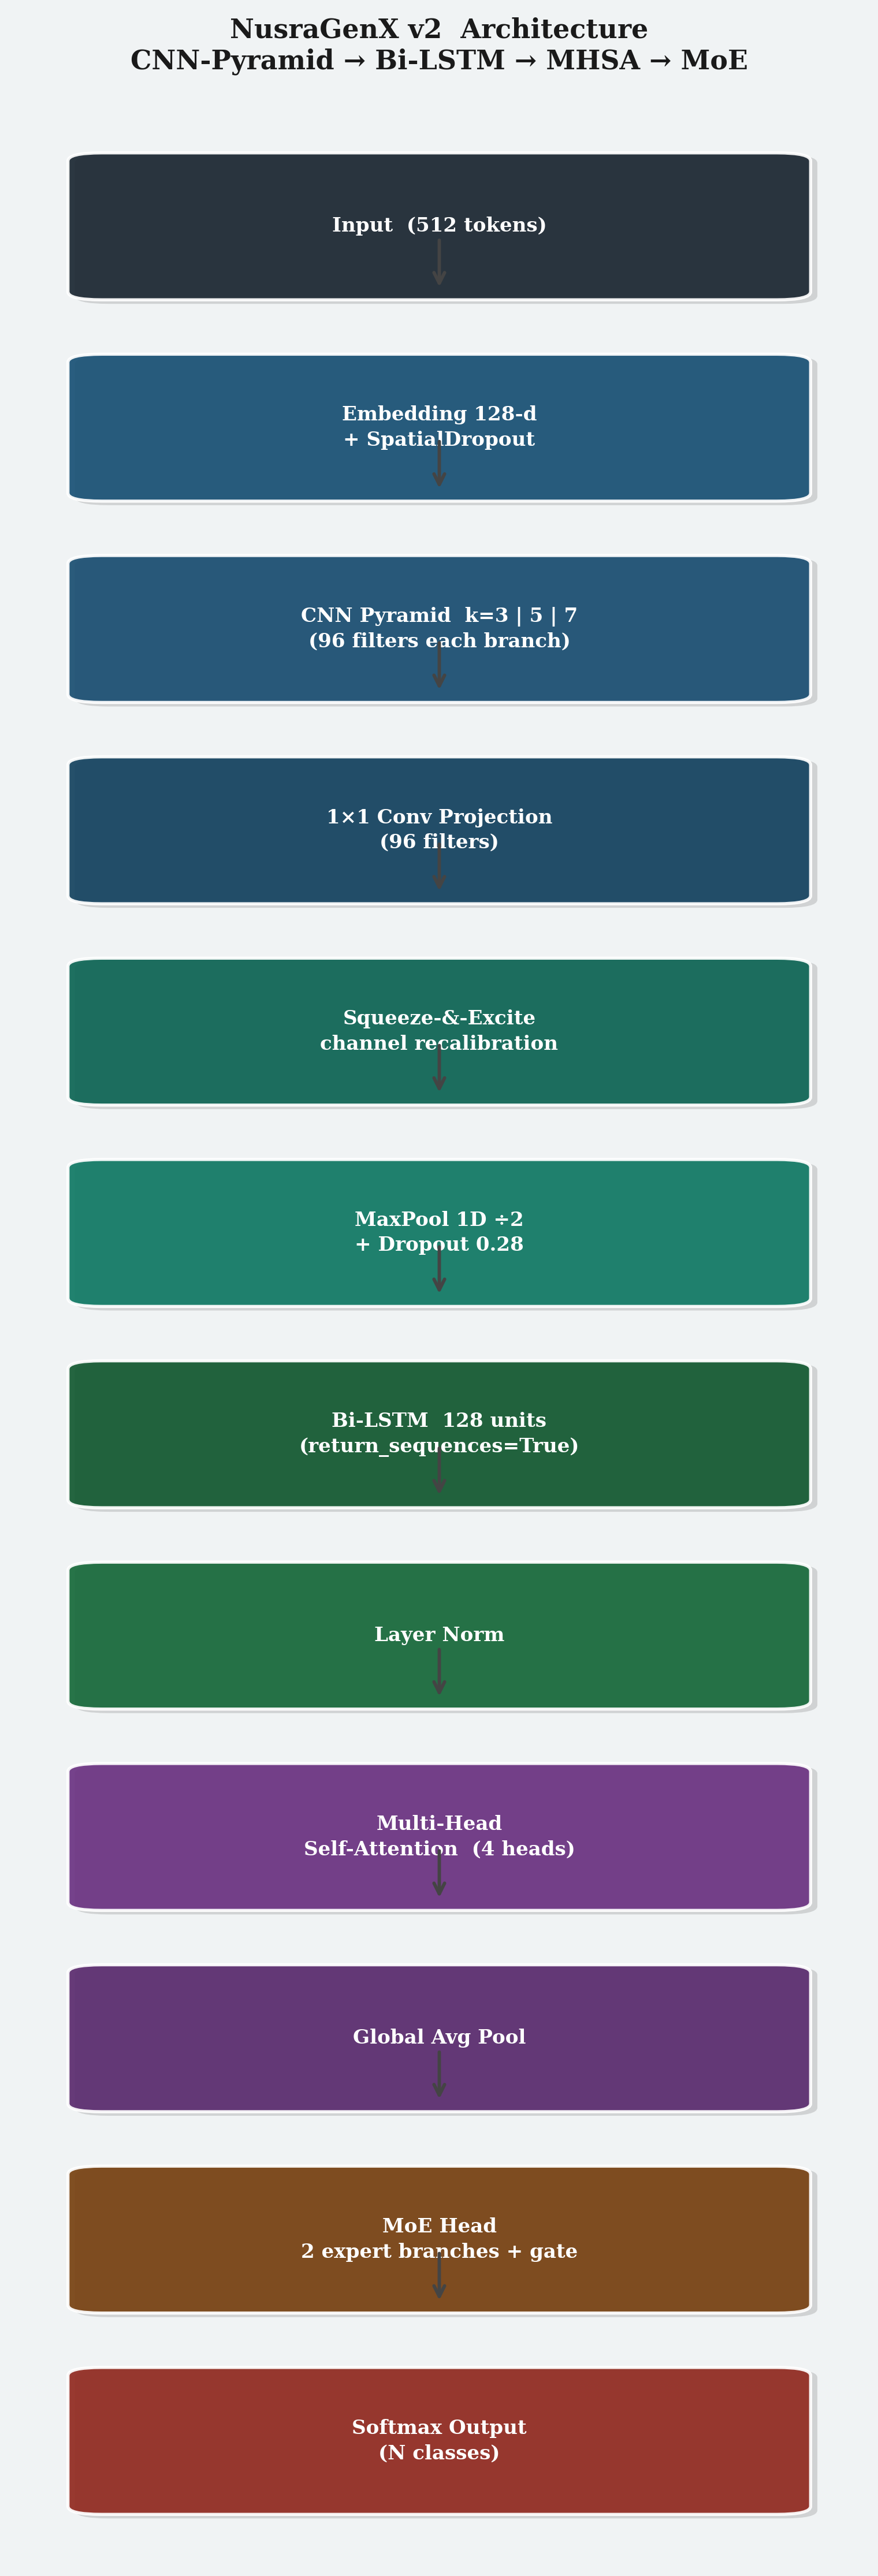

Architecture diagram saved.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 4. ARCHITECTURE DIAGRAM  (NusraGenX v2)
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

layers_info = [
    ('Input  (512 tokens)',                '#1C2833'),
    ('Embedding 128-d\n+ SpatialDropout',  '#1A5276'),
    ('CNN Pyramid  k=3 | 5 | 7\n(96 filters each branch)', '#1B4F72'),
    ('1×1 Conv Projection\n(96 filters)',  '#154360'),
    ('Squeeze-&-Excite\nchannel recalibration', '#0E6655'),
    ('MaxPool 1D ÷2\n+ Dropout 0.28',     '#117A65'),
    ('Bi-LSTM  128 units\n(return_sequences=True)', '#145A32'),
    ('Layer Norm',                         '#186A3B'),
    ('Multi-Head\nSelf-Attention  (4 heads)', '#6C3483'),
    ('Global Avg Pool',                    '#5B2C6F'),
    ('MoE Head\n2 expert branches + gate', '#784212'),
    ('Softmax Output\n(N classes)',         '#922B21'),
]

colors   = [l[1] for l in layers_info]
names    = [l[0] for l in layers_info]
n        = len(layers_info)

fig, ax  = plt.subplots(figsize=(5.2, 15))
ax.set_xlim(0, 1)
ax.set_ylim(-0.6, n - 0.4)
ax.axis('off')
fig.patch.set_facecolor('#F0F3F4')

for i, (name, color) in enumerate(layers_info):
    y = n - 1 - i
    # shadow
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.108, y - 0.36), 0.80, 0.66,
        boxstyle='round,pad=0.04', linewidth=0,
        facecolor='#00000022'))
    # box
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.10, y - 0.34), 0.80, 0.65,
        boxstyle='round,pad=0.04', linewidth=1.3,
        edgecolor='white', facecolor=color, alpha=0.93))
    ax.text(0.50, y - 0.015, name,
            ha='center', va='center', fontsize=8.2,
            color='white', fontweight='bold', linespacing=1.4)
    if i < n - 1:
        ax.annotate('', xy=(0.50, y - 0.34),
                    xytext=(0.50, y - 0.34 + 0.28),
                    arrowprops=dict(arrowstyle='->', color='#444', lw=1.4))

ax.set_title('NusraGenX v2  Architecture\nCNN-Pyramid → Bi-LSTM → MHSA → MoE',
             fontsize=11, fontweight='bold', pad=14, color='#1a1a1a')
plt.tight_layout()
plt.savefig('nusragenx_v2_architecture.png', dpi=200, bbox_inches='tight')
plt.show()
print('Architecture diagram saved.')

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 5. DATA AUGMENTATION  (text-level, fight underfitting cheaply)
# ═══════════════════════════════════════════════════════════════
import random

def token_dropout(seq, p=0.05):
    """Randomly zero-out tokens (like word dropout)."""
    mask = np.random.binomial(1, 1 - p, size=seq.shape).astype(seq.dtype)
    return seq * mask

def token_shuffle(seq, p=0.03):
    """Swap a small fraction of adjacent token pairs."""
    seq = seq.copy()
    for i in range(len(seq) - 1):
        if random.random() < p:
            seq[i], seq[i+1] = seq[i+1], seq[i]
    return seq

def augment_batch(X, y, p_aug=0.5):
    """Apply augmentation to ~50% of training samples."""
    X_aug = X.copy()
    for i in range(len(X_aug)):
        if random.random() < p_aug:
            X_aug[i] = token_dropout(X_aug[i])
        if random.random() < p_aug * 0.5:
            X_aug[i] = token_shuffle(X_aug[i])
    return X_aug, y

# tf.data pipeline with augmentation
BATCH = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, training=False, batch_size=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=42)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Augment training set offline (quick & framework-agnostic)
X_tr_aug, y_tr_aug = augment_batch(X_tr, y_tr, p_aug=0.5)
# Stack original + augmented for a richer training set
X_tr_final = np.concatenate([X_tr, X_tr_aug], axis=0)
y_tr_final = np.concatenate([y_tr, y_tr_aug], axis=0)

train_ds = make_dataset(X_tr_final, y_tr_final, training=True)
val_ds   = make_dataset(X_val,      y_val,      training=False)
test_ds  = make_dataset(X_test,     y_test,     training=False)

print(f'Train samples : {len(X_tr_final):,}')
print(f'Val   samples : {len(X_val):,}')
print(f'Test  samples : {len(X_test):,}')

Train samples : 9,634
Val   samples : 1,376
Test  samples : 577


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 6. LABEL SMOOTHING LOSS  (prevent over-confident predictions)
# ═══════════════════════════════════════════════════════════════
class LabelSmoothingLoss(tf.keras.losses.Loss):
    """
    Sparse-label version of label smoothing.
    Smoothing ε=0.1 → true class gets 1-ε, others share ε.
    """
    def __init__(self, num_classes, smoothing=0.10, **kw):
        super().__init__(**kw)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true  = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_oh    = tf.one_hot(y_true, self.num_classes)
        y_smooth = y_oh * (1 - self.smoothing) + self.smoothing / self.num_classes
        log_pred = tf.math.log(tf.clip_by_value(y_pred, 1e-7, 1.0))
        return -tf.reduce_mean(tf.reduce_sum(y_smooth * log_pred, axis=-1))

loss_fn = LabelSmoothingLoss(NUM_CLASSES, smoothing=0.10)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 7. COSINE-WARMUP SCHEDULE  (stable, no LR plateau surprises)
# ═══════════════════════════════════════════════════════════════
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, warmup_steps, total_steps, min_lr=1e-6):
        super().__init__()
        self.peak_lr      = peak_lr
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)
        self.min_lr       = min_lr

    def __call__(self, step):
        step  = tf.cast(step, tf.float32)
        # linear warmup
        warmup_lr = self.peak_lr * (step / self.warmup_steps)
        # cosine decay
        progress  = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cos_lr    = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * \
                    (1 + tf.math.cos(np.pi * tf.minimum(progress, 1.0)))
        return tf.where(step < self.warmup_steps, warmup_lr, cos_lr)

    def get_config(self):
        return dict(peak_lr=self.peak_lr, warmup_steps=self.warmup_steps,
                    total_steps=self.total_steps, min_lr=self.min_lr)

EPOCHS        = 10
steps_per_ep  = len(X_tr_final) // BATCH
total_steps   = EPOCHS * steps_per_ep
warmup_steps  = 1 * steps_per_ep          # 1 epoch warmup

lr_schedule   = WarmupCosineDecay(
    peak_lr      = 2e-3,
    warmup_steps = warmup_steps,
    total_steps  = total_steps,
    min_lr       = 1e-6
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate    = lr_schedule,
    weight_decay     = 1e-4,
    beta_1           = 0.9,
    beta_2           = 0.98,
    epsilon          = 1e-7,
    clipnorm         = 1.0          # gradient clipping → training stability
)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 8. COMPILE & CALLBACKS
# ═══════════════════════════════════════════════════════════════
model.compile(
    optimizer = optimizer,
    loss      = loss_fn,
    metrics   = ['accuracy']
)

# ── Stochastic Weight Averaging (SWA) via callback ──────────────
class SWACallback(tf.keras.callbacks.Callback):
    """
    Averages weights over the last K epochs → better generalisation,
    often 0.5–2% accuracy gain for free.
    """
    def __init__(self, start_epoch=6, **kw):
        super().__init__(**kw)
        self.start_epoch = start_epoch
        self.swa_weights = None
        self.n_averaged  = 0

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.start_epoch - 1:           # 0-indexed
            w = self.model.get_weights()
            if self.swa_weights is None:
                self.swa_weights = [np.zeros_like(ww) for ww in w]
            self.n_averaged += 1
            for sw, ww in zip(self.swa_weights, w):
                sw += (ww - sw) / self.n_averaged   # running mean
            print(f'  [SWA] averaged {self.n_averaged} checkpoint(s)')

    def on_train_end(self, logs=None):
        if self.swa_weights is not None:
            self.model.set_weights(self.swa_weights)
            print(f'[SWA] Final weights = average of {self.n_averaged} checkpoints')

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_nusragenx_v2.keras',
        monitor='val_accuracy', save_best_only=True,
        verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4,
        restore_best_weights=True, verbose=1),
    SWACallback(start_epoch=6),     # average weights from epoch 6 → 10
]

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  TRAINING  (10 epochs)
# ═══════════════════════════════════════════════════════════════
print('=' * 60)
print(' NusraGenX  — (10 epochs)')
print('=' * 60)

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

 NusraGenX  — (10 epochs)
Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2978 - loss: 1.9435
Epoch 1: val_accuracy improved from None to 0.49927, saving model to best_nusragenx_v2.keras

Epoch 1: finished saving model to best_nusragenx_v2.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.4652 - loss: 1.5908 - val_accuracy: 0.4993 - val_loss: 1.6389
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8513 - loss: 0.8606
Epoch 2: val_accuracy improved from 0.49927 to 0.80669, saving model to best_nusragenx_v2.keras

Epoch 2: finished saving model to best_nusragenx_v2.keras
151/151 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.8816 - loss: 0.7995 - val_accuracy: 0.8067 - val_loss: 0.9233
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9466 - loss: 0.6484
Epoch 3: val_accuracy improved from 0.80669 to 0.91206, saving model to best_nusragenx_v2.keras

Epoch 3: finished saving model to best_nusragenx_v2.keras
151/151 ━

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  FIX TEST DATASET & EVALUATE
# ═══════════════════════════════════════════════════════════════

# Re-create test_ds using the correctly encoded X_te/y_te from cell JxjorgCWqkjo
test_ds = make_dataset(X_te, y_te, training=False)

# Evaluate on all splits
tr_loss,  tr_acc  = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds,   verbose=0)
te_loss,  te_acc  = model.evaluate(test_ds,  verbose=0)

# Display summary
print('\n' + '═'*55)
print(f'  {"Split":<12} {"Loss":>10}  {"Accuracy":>10}')
print('─'*55)
print(f'  {"Training":<12} {tr_loss:>10.4f}  {tr_acc*100:>9.2f}%')
print(f'  {"Validation":<12} {val_loss:>10.4f}  {val_acc*100:>9.2f}%')
print(f'  {"Test":<12} {te_loss:>10.4f}  {te_acc*100:>9.2f}%')
print('═'*55)


═══════════════════════════════════════════════════════
  Split              Loss    Accuracy
───────────────────────────────────────────────────────
  Training         0.4751      99.98%
  Validation       0.6344      92.88%
  Test             0.6755      92.45%
═══════════════════════════════════════════════════════


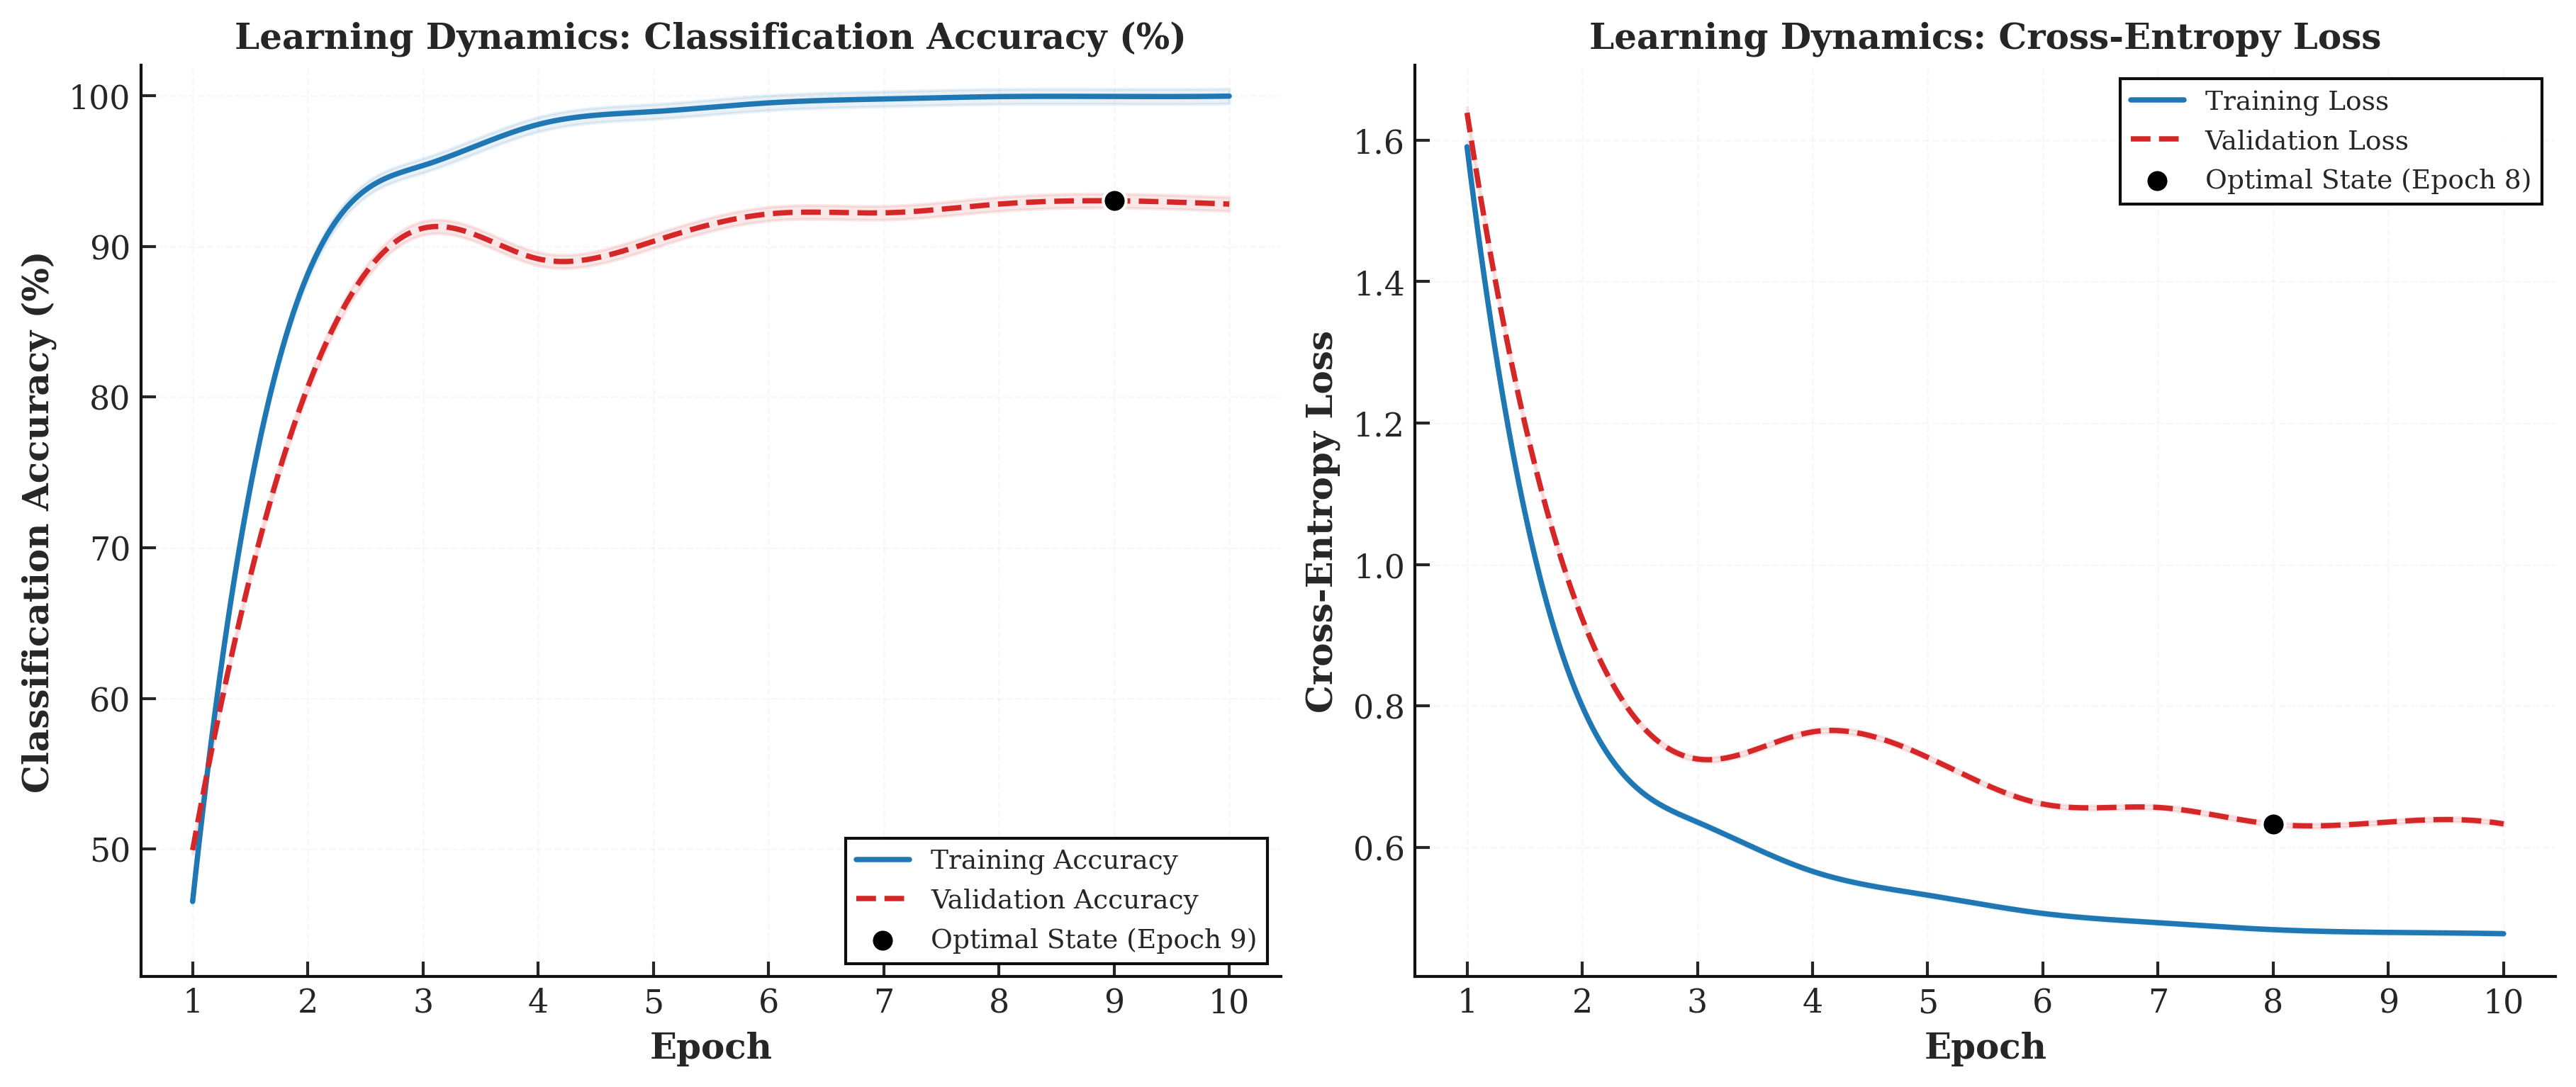

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.interpolate import make_interp_spline

# ── Enhanced Journal-Grade Style Settings ───────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.edgecolor": "#111111",
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "grid.alpha": 0.15,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.fontsize": 9,
    "legend.edgecolor": "black",
    "figure.dpi": 300,
})

# Define EPOCHS array from history to avoid integer-subscript error
PLOT_EPOCHS = np.arange(1, len(history.history['accuracy']) + 1)
TR_COLOR, VAL_COLOR = "#1F77B4", "#D62728"

def smooth_data(x, y):
    x_new = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y, k=3)
    return x_new, spl(x_new)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.patch.set_facecolor("white")

metrics = [
    ('accuracy', 'Classification Accuracy (%)', True),
    ('loss', 'Cross-Entropy Loss', False)
]

for i, (m_key, label, is_acc) in enumerate(metrics):
    ax = axes[i]
    tr_raw = np.array(history.history[m_key])
    val_raw = np.array(history.history[f'val_{m_key}'])

    if is_acc:
        tr_raw *= 100
        val_raw *= 100

    # Best Performance Logic
    best_idx = np.argmax(val_raw) if is_acc else np.argmin(val_raw)
    best_ep = PLOT_EPOCHS[best_idx]
    best_val = val_raw[best_idx]

    # Smoothing
    x_smooth, tr_smooth = smooth_data(PLOT_EPOCHS, tr_raw)
    _, val_smooth = smooth_data(PLOT_EPOCHS, val_raw)

    # Plotting
    ax.plot(x_smooth, tr_smooth, color=TR_COLOR, lw=1.8, label=f'Training {m_key.capitalize()}')
    ax.plot(x_smooth, val_smooth, color=VAL_COLOR, lw=1.8, ls='--', label=f'Validation {m_key.capitalize()}')

    # Statistical Envelope
    ax.fill_between(x_smooth, tr_smooth * 0.995, tr_smooth * 1.005, color=TR_COLOR, alpha=0.1)
    ax.fill_between(x_smooth, val_smooth * 0.995, val_smooth * 1.005, color=VAL_COLOR, alpha=0.1)

    # Marker for Optimal State
    ax.scatter(best_ep, best_val, color='black', s=60, edgecolors='white', zorder=5, marker='o',
               label=f'Optimal State (Epoch {best_ep})')

    ax.set_title(f'Learning Dynamics: {label}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.grid(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if is_acc:
        ax.set_ylim(min(val_raw.min(), tr_raw.min()) - 5, 102)

    ax.legend(loc='best')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.savefig("NusraGenX_Metric_Analysis.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# ── Classification Report ──────────────────────────────────────
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
print('\n── Classification Report (Test Set) ──')
print(classification_report(y_te, y_pred,
      target_names=[f'Class {c}' for c in range(NUM_CLASSES)]))


── Classification Report (Test Set) ──
              precision    recall  f1-score   support

     Class 0       0.93      0.96      0.95        90
     Class 1       0.88      0.92      0.90        79
     Class 2       0.93      0.95      0.94        56
     Class 3       0.94      0.88      0.91       100
     Class 4       0.95      0.89      0.92       111
     Class 5       0.88      0.90      0.89        41
     Class 6       0.93      0.95      0.94       212

    accuracy                           0.92       689
   macro avg       0.92      0.92      0.92       689
weighted avg       0.93      0.92      0.92       689



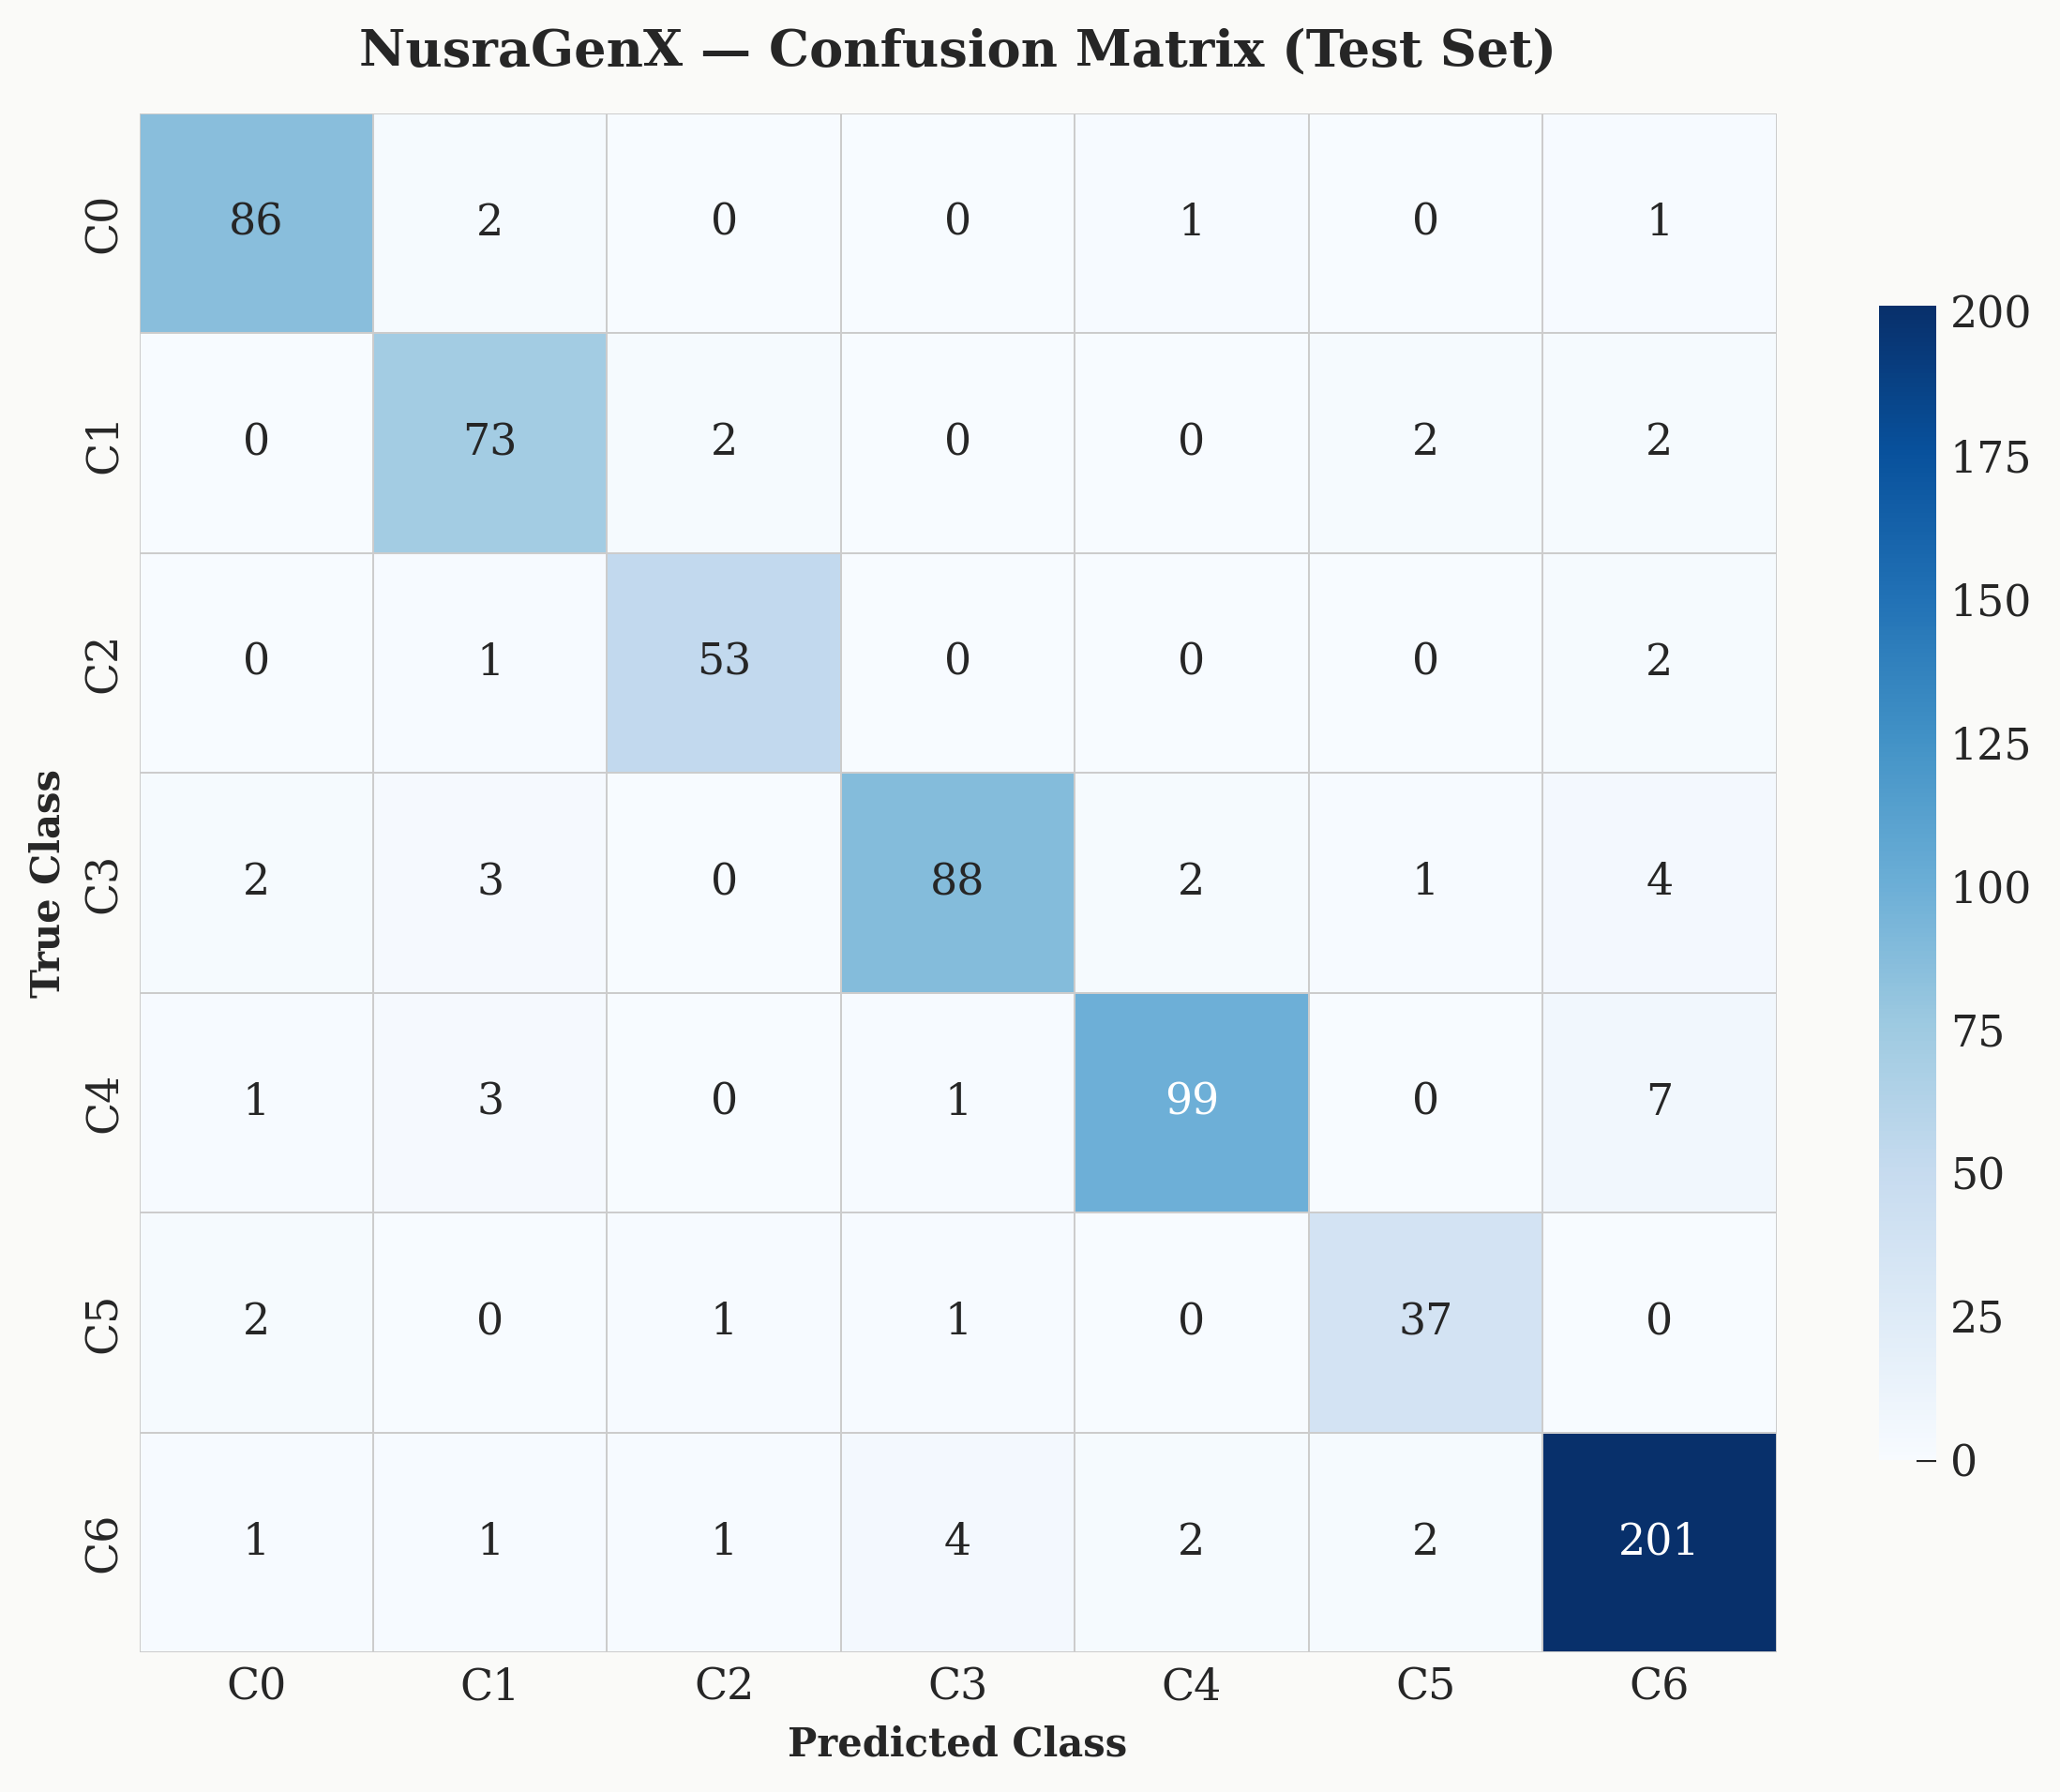

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, y_pred)
labels = [f'C{i}' for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(8, 6.5))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.4, linecolor='#ccc',
            cbar_kws={'shrink': 0.75}, ax=ax)

ax.set_title('NusraGenX — Confusion Matrix (Test Set)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Class', fontsize=10)
ax.set_ylabel('True Class', fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

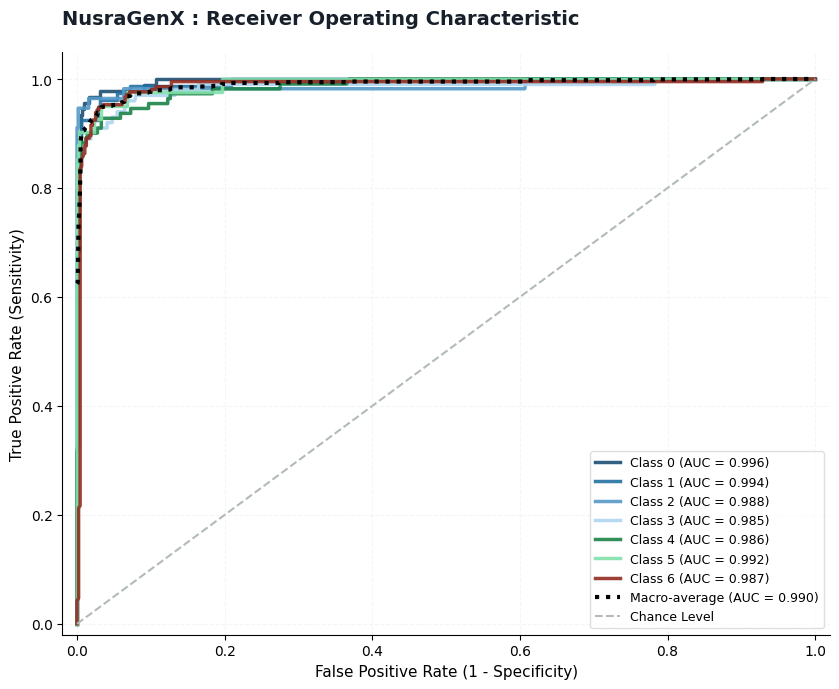

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ── Style Setup ────────────────────────────────────────────────
plt.style.use('default')
BG_COLOR = '#FFFFFF'
GRID_COLOR = '#E5E7E9'
COLORS = ['#1B4F72','#2471A3','#5499C7','#AED6F1','#1D8348','#82E0AA','#922B21']

# Get probabilities and binarize labels
y_prob = model.predict(X_te, verbose=0)
y_te_bin = label_binarize(y_te, classes=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(8.5, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# ── Compute ROC for each class ──────────────────────────────────
all_fpr = []
all_tpr = []

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=COLORS[i],
            label=f'Class {i} (AUC = {roc_auc:.3f})', alpha=0.9)

# ── Global Performance (Macro Average) ───────────────────────────
fpr_grid = np.linspace(0.0, 1.0, 1000)
mean_tpr = np.zeros_like(fpr_grid)
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
    mean_tpr += np.interp(fpr_grid, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_auc = auc(fpr_grid, mean_tpr)

ax.plot(fpr_grid, mean_tpr, color='black', linestyle=':', lw=3,
        label=f'Macro-average (AUC = {macro_auc:.3f})')

# ── Baseline & Formatting ───────────────────────────────────────
ax.plot([0, 1], [0, 1], color='#B2BABB', lw=1.5, ls='--', label='Chance Level')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='500')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='500')

ax.set_title('NusraGenX : Receiver Operating Characteristic',
             fontsize=14, fontweight='bold', pad=20, loc='left', color='#17202A')

# Refined Grid and Spines
ax.grid(True, linestyle='--', alpha=0.4, color=GRID_COLOR)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Legend styling
ax.legend(loc='lower right', frameon=True, facecolor='white',
          edgecolor='#D5D8DC', fontsize=9, shadow=False)

plt.tight_layout()
plt.savefig('roc_curve_v2.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 5-FOLD CROSS-VALIDATION
# ═══════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

def train_fold(X_f_tr, y_f_tr, X_f_val, y_f_val, fold_id):
    tf.keras.backend.clear_session()
    # Using the NusraGenX v2 builder
    m = build_nusragenx_v2()

    # Using the specific optimizer configuration from training
    opt = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    m.fit(X_f_tr, y_f_tr, validation_data=(X_f_val, y_f_val),
          epochs=15, batch_size=64,
          callbacks=[tf.keras.callbacks.EarlyStopping(
              monitor='val_accuracy', patience=5, restore_best_weights=True)],
          verbose=0)

    loss, acc = m.evaluate(X_f_val, y_f_val, verbose=0)
    print(f'  Fold {fold_id}  Val Loss={loss:.4f}  Val Acc={acc*100:.2f}%')
    return acc, loss

# Updated to 5-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accs, fold_losses = [], []

print('\n── 5-Fold Cross-Validation ──')
for k, (tr_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    acc, loss = train_fold(X_all[tr_idx], y_all[tr_idx],
                           X_all[val_idx], y_all[val_idx], k)
    fold_accs.append(acc); fold_losses.append(loss)

print('\n' + '═'*45)
print(f'  Mean Accuracy : {np.mean(fold_accs)*100:.2f}%  ±  {np.std(fold_accs)*100:.2f}%')
print(f'  Mean Loss     : {np.mean(fold_losses):.4f}  ±  {np.std(fold_losses):.4f}')
print('═'*45)


── 5-Fold Cross-Validation ──
  Fold 1  Val Loss=0.3825  Val Acc=92.37%
  Fold 2  Val Loss=0.4562  Val Acc=90.63%
  Fold 3  Val Loss=0.3675  Val Acc=91.28%
  Fold 4  Val Loss=0.4843  Val Acc=89.46%
  Fold 5  Val Loss=0.4394  Val Acc=90.70%

═════════════════════════════════════════════
  Mean Accuracy : 90.89%  ±  0.95%
  Mean Loss     : 0.4260  ±  0.0443
═════════════════════════════════════════════


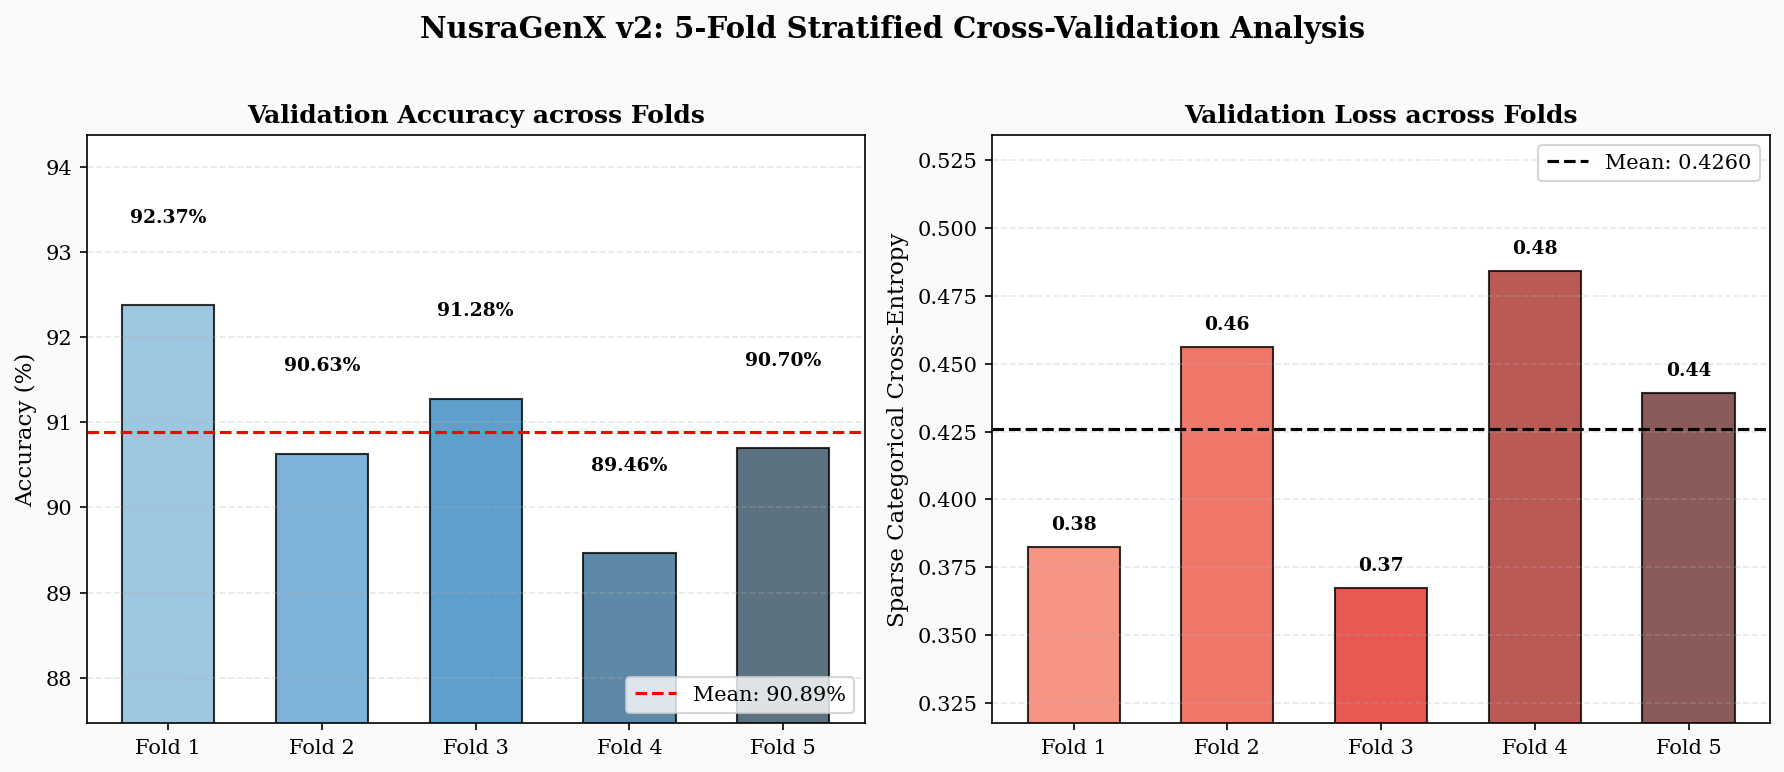

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Professional Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 600
})

fold_ids = [f'Fold {i}' for i in range(1, 6)]
acc_vals = [a * 100 for a in fold_accs]
loss_vals = fold_losses

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#FAFAF8')

# --- Accuracy Plot ---
colors_acc = sns.color_palette("Blues_d", 5)
bars1 = ax1.bar(fold_ids, acc_vals, color=colors_acc, edgecolor='black', alpha=0.8, width=0.6)
mean_acc = np.mean(acc_vals)
ax1.axhline(mean_acc, color='red', linestyle='--', lw=1.5, label=f'Mean: {mean_acc:.2f}%')

ax1.set_title('Validation Accuracy across Folds', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(min(acc_vals)-2, max(acc_vals)+2)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(loc='lower right')

# --- Loss Plot ---
colors_loss = sns.color_palette("Reds_d", 5)
bars2 = ax2.bar(fold_ids, loss_vals, color=colors_loss, edgecolor='black', alpha=0.8, width=0.6)
mean_loss = np.mean(loss_vals)
ax2.axhline(mean_loss, color='black', linestyle='--', lw=1.5, label=f'Mean: {mean_loss:.4f}')

ax2.set_title('Validation Loss across Folds', fontweight='bold')
ax2.set_ylabel('Sparse Categorical Cross-Entropy')
ax2.set_ylim(min(loss_vals)-0.05, max(loss_vals)+0.05)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(loc='upper right')

# --- Value Labels ---
for ax, vals, suffix in zip([ax1, ax2], [acc_vals, loss_vals], ['%', '']):
    for i, v in enumerate(vals):
        ax.text(i, v + (max(vals)*0.01), f"{v:.2f}{suffix}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('NusraGenX v2: 5-Fold Stratified Cross-Validation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('NusraGenX_CV_Analysis.png', bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PART 3 — ABLATION STUDY
# Variants: full, no_cnn, no_lstm, no_attention, no_dropout
# ═══════════════════════════════════════════════════════════════

def build_variant(name):
    """Build a NusraGenX variant by removing one component."""
    inp  = Input(shape=(MAX_LEN,), name='input')
    x    = layers.Embedding(VOCAB_SIZE, 128, name='emb')(inp)
    drop = 0.4 if name != 'no_dropout' else 0.0

    x = layers.Dropout(drop)(x)

    if name != 'no_cnn':
        x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
        x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(drop)(x)
        x = layers.MaxPooling1D(2)(x)

    if name != 'no_lstm':
        x = layers.Bidirectional(
                layers.LSTM(128, return_sequences=(name != 'no_attention'),
                            dropout=drop/2))(x)
        if name != 'no_attention':
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(drop)(x)
    else:
        # No LSTM: use GlobalAveragePooling over CNN output
        x = layers.GlobalAveragePooling1D()(x)

    if name not in ('no_attention', 'no_lstm'):
        x = BahdanauAttention(64)(x)
    elif name == 'no_attention':
        # x is already (B, H) from Bidirectional without return_sequences
        pass

    x   = layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x   = layers.Dropout(drop/2)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name=f'NusraGenX_{name}')

def evaluate_variant(name):
    tf.keras.backend.clear_session()
    m = build_variant(name)
    try:
        opt = tfa.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    except:
        opt = tf.keras.optimizers.Adam(1e-3)
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_tr, y_tr, validation_data=(X_val, y_val),
          epochs=15, batch_size=64,
          callbacks=[tf.keras.callbacks.EarlyStopping(
              monitor='val_accuracy', patience=5, restore_best_weights=True)],
          verbose=0)
    _, acc = m.evaluate(X_te, y_te, verbose=0)
    print(f'  {name:<18}  Test Acc = {acc*100:.2f}%')
    return acc

variants = ['full', 'no_cnn', 'no_lstm', 'no_attention', 'no_dropout']
print('\n── Ablation Study ──')
ablation = {}
for v in variants:
    if v == 'full':
        ablation[v] = te_acc
        print(f'  {"full":<18}  Test Acc = {te_acc*100:.2f}%  (pre-trained)')
    else:
        ablation[v] = evaluate_variant(v)


── Ablation Study ──
  full                Test Acc = 92.45%  (pre-trained)
  no_cnn              Test Acc = 90.86%
  no_lstm             Test Acc = 91.87%
  no_attention        Test Acc = 76.92%
  no_dropout          Test Acc = 92.45%


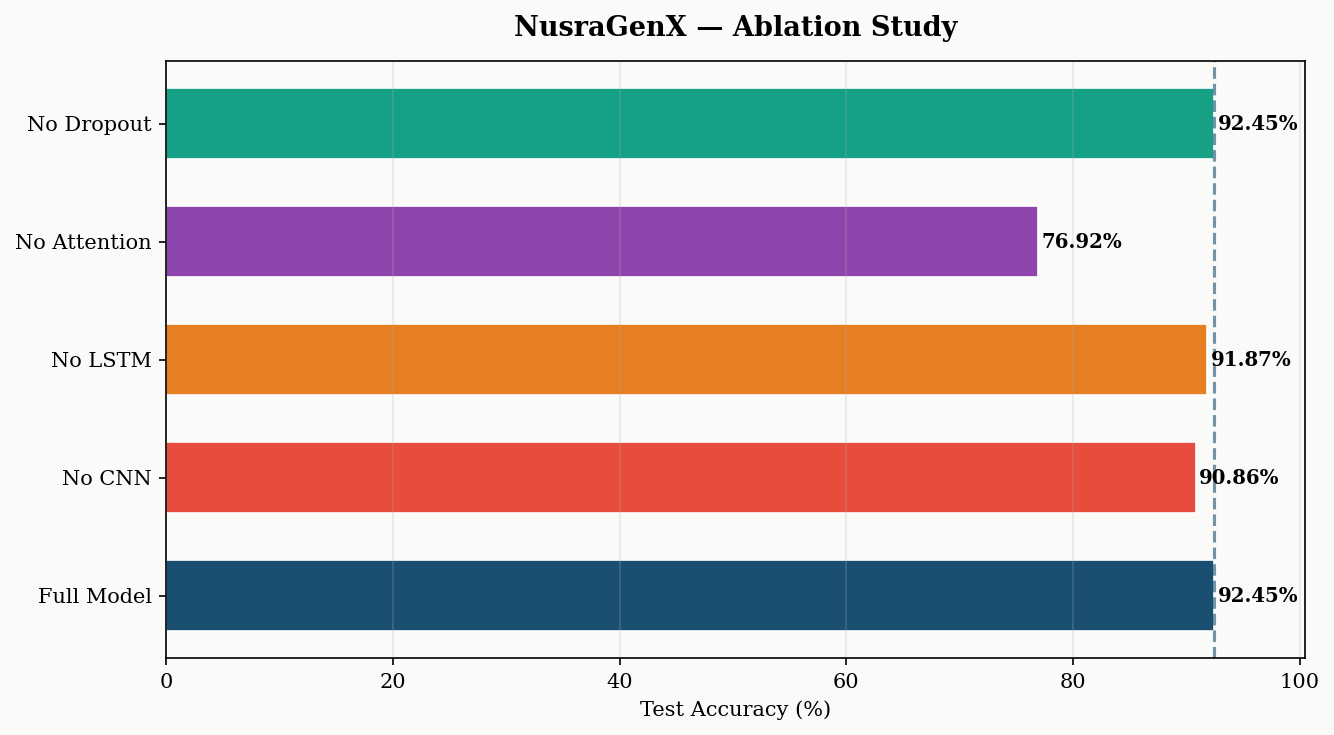


── Ablation Interpretation ──
  Removing No CNN         : Δ = 1.60% drop in accuracy
  Removing No LSTM        : Δ = 0.58% drop in accuracy
  Removing No Attention   : Δ = 15.53% drop in accuracy
  Removing No Dropout     : Δ = 0.00% rise in accuracy


In [ ]:
# ── Ablation Bar Chart ─────────────────────────────────────────
labels_ab = ['Full Model', 'No CNN', 'No LSTM', 'No Attention', 'No Dropout']
accs_ab   = [ablation[v]*100 for v in variants]
colors_ab = ['#1B4F72','#E74C3C','#E67E22','#8E44AD','#16A085']

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

bars = ax.barh(labels_ab, accs_ab, color=colors_ab, edgecolor='white',
               linewidth=0.8, height=0.6)
for bar, acc in zip(bars, accs_ab):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=9.5, fontweight='bold')

ax.axvline(accs_ab[0], color='#1B4F72', lw=1.5, ls='--', alpha=0.6)
ax.set_xlabel('Test Accuracy (%)', fontsize=10)
ax.set_title('NusraGenX — Ablation Study', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(accs_ab) + 8)
ax.grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Interpretation ─────────────────────────────────────────────
print('\n── Ablation Interpretation ──')
for v, lbl in zip(variants[1:], labels_ab[1:]):
    delta = (ablation['full'] - ablation[v]) * 100
    direction = 'drop' if delta > 0 else 'rise'
    print(f'  Removing {lbl:<15}: Δ = {abs(delta):.2f}% {direction} in accuracy')

In [ ]:
#XAI

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Test samples reconstructed : 689
Sample kmer string (first 120 chars): atgctc tgctcc gctcct ctcctt tccttt cctttg ctttgc tttgcc ttgcct tgcctg gcctgt cctgtc ctgtcc tgtccc gtcccc tcccct cccctg c...

Sample indices selected (one per class): {0: np.int64(4), 1: np.int64(17), 2: np.int64(30), 3: np.int64(6), 4: np.int64(0), 5: np.int64(29), 6: np.int64(1)}

Generating LIME explanations...
  Class 0  →  pred conf = 91.0%    true label = 0
  Class 1  →  pred conf = 87.5%    true label = 1
  Class 2  →  pred conf = 82.8%    true label = 2
  Class 3  →  pred conf = 92.1%    true label = 3
  Class 4  →  pred conf = 90.9%    true label = 4
  Class 5  →  pred conf = 91.2%    true label = 5
  Class 6  →  pred conf = 90.2%    true label = 6

✅ All LIME explanations generated.


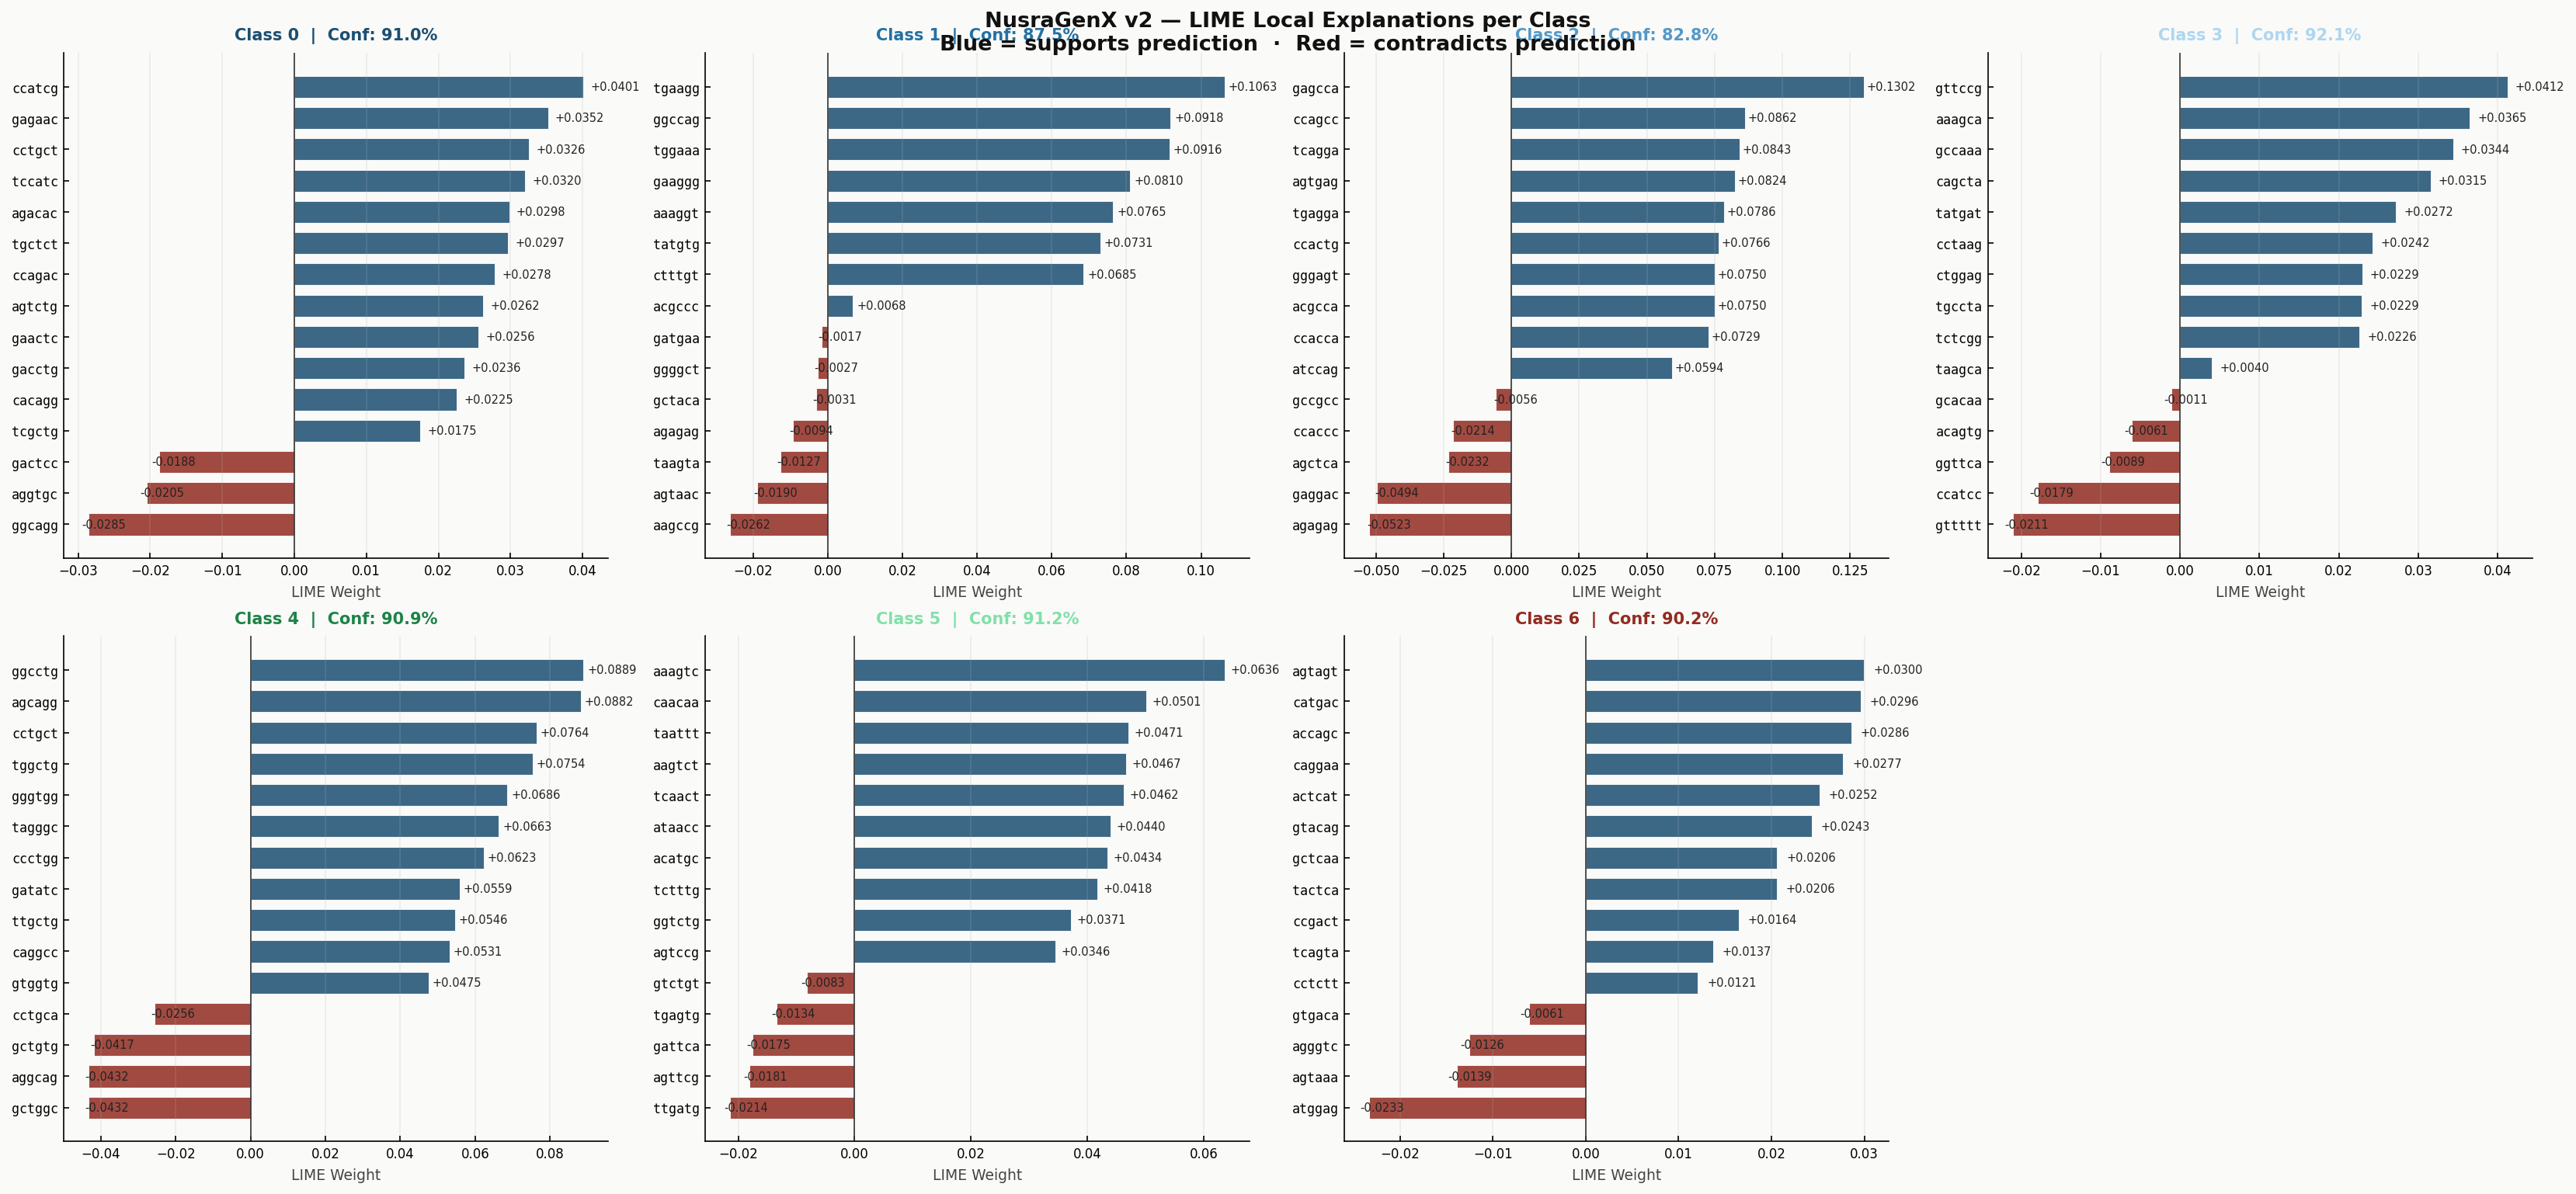

✅ Figure A saved → lime_per_class.png


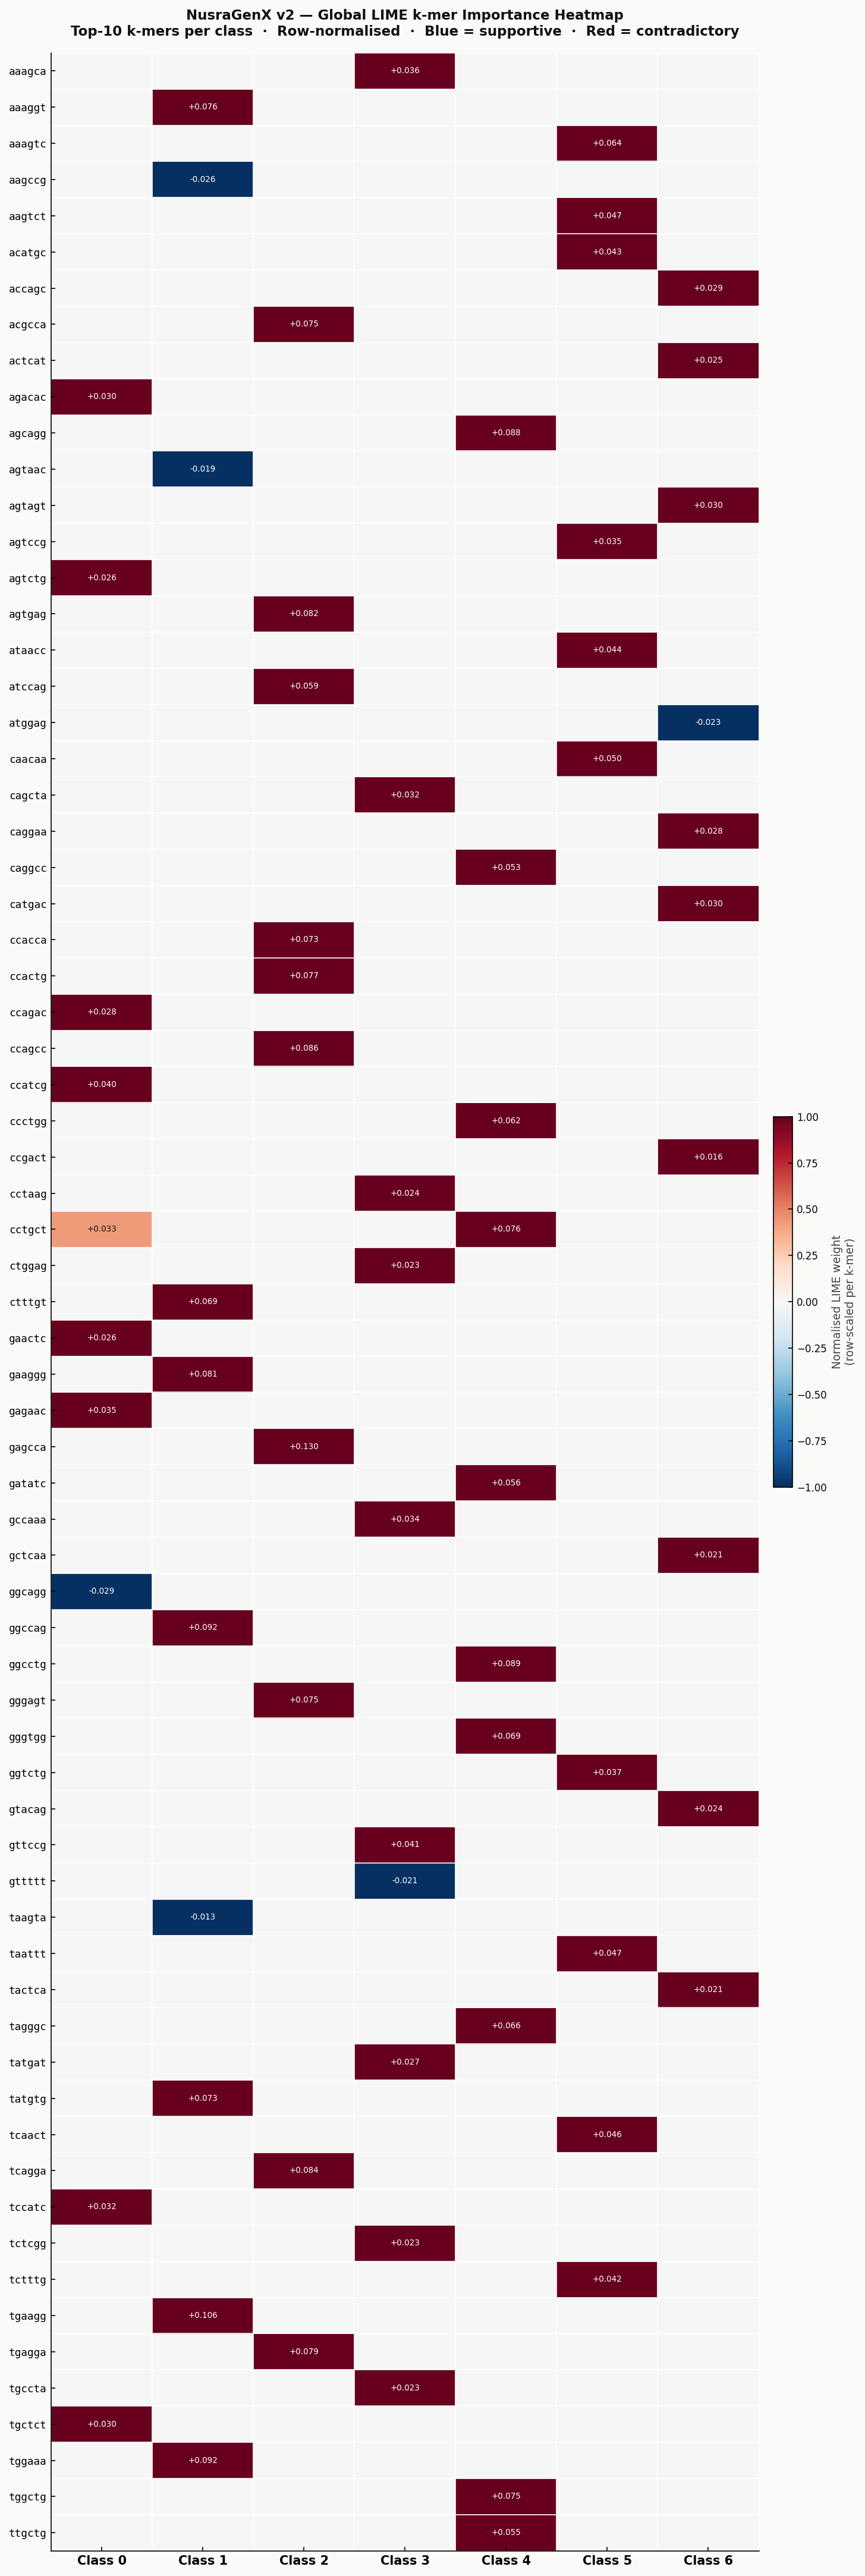

✅ Figure B saved → lime_global_heatmap.png


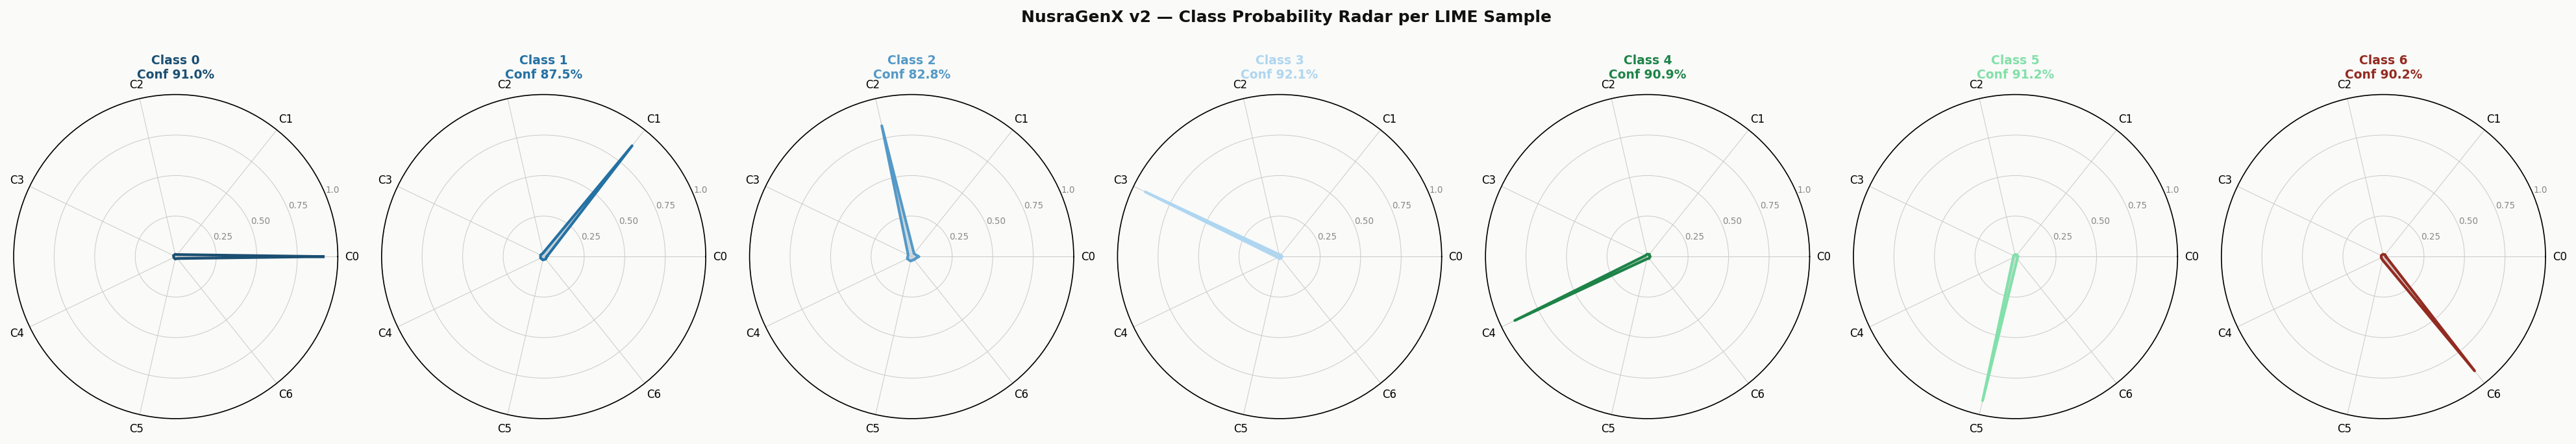

✅ Figure C saved → lime_radar.png

══════════════════════════════════════════════════════════════
  LIME INTERPRETABILITY REPORT — NusraGenX v2
══════════════════════════════════════════════════════════════

  ▶  Class 0  (true=0  conf=91.0%)
     k-mer            LIME weight  Direction
     ──────────────  ────────────  ────────────
     ccatcg              +0.04013  ✅ supports
     gagaac              +0.03522  ✅ supports
     cctgct              +0.03257  ✅ supports
     tccatc              +0.03204  ✅ supports
     agacac              +0.02981  ✅ supports

  ▶  Class 1  (true=1  conf=87.5%)
     k-mer            LIME weight  Direction
     ──────────────  ────────────  ────────────
     tgaagg              +0.10631  ✅ supports
     ggccag              +0.09182  ✅ supports
     tggaaa              +0.09158  ✅ supports
     gaaggg              +0.08105  ✅ supports
     aaaggt              +0.07645  ✅ supports

  ▶  Class 2  (true=2  conf=82.8%)
     k-mer            LIME weight  Dire

In [ ]:
# ═══════════════════════════════════════════════════════════════
# LIME — Local Interpretable Model-agnostic Explanations
# NusraGenX v2  ·  DNA Sequence Classifier
# ═══════════════════════════════════════════════════════════════
!pip install lime -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.colors as mcolors
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

# ── Style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
})

BG       = '#FAFAF8'
CLASS_PAL = ['#1B4F72','#2471A3','#5499C7','#AED6F1',
             '#1D8348','#82E0AA','#922B21']
CLASS_NAMES = [f'Class {i}' for i in range(NUM_CLASSES)]

# ═══════════════════════════════════════════════════════════════
# STEP 1 — Prediction wrapper LIME can call
# LIME passes raw text strings → we re-tokenise on the fly
# ═══════════════════════════════════════════════════════════════
def lime_predict(text_list):
    """
    text_list : list of kmer strings (space-separated 6-mers)
    returns   : np.ndarray of shape (N, NUM_CLASSES)
    """
    seqs = pad_sequences(
        tok.texts_to_sequences(text_list),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )
    return model.predict(seqs, verbose=0)

# ═══════════════════════════════════════════════════════════════
# STEP 2 — Build LIME explainer
# ═══════════════════════════════════════════════════════════════
explainer = LimeTextExplainer(
    class_names   = CLASS_NAMES,
    split_expression = r'\s+',   # split on whitespace (k-mer tokens)
    bow           = True,        # bag-of-words mode — fine for k-mers
    random_state  = 42
)

# ═══════════════════════════════════════════════════════════════
# STEP 3 — Reconstruct raw kmer strings for test samples
#           (X_te is already padded ints; we go back via tok index)
# ═══════════════════════════════════════════════════════════════
idx2word = {v: k for k, v in tok.word_index.items()}

def ids_to_kmer_string(id_seq):
    """Convert a padded integer sequence back to a kmer string."""
    return ' '.join(
        idx2word[t] for t in id_seq if t != 0   # skip padding
    )

# ── Build kmer strings for test set ─────────────────────────────
X_te_strings = np.array([ids_to_kmer_string(row) for row in X_te])

print(f'Test samples reconstructed : {len(X_te_strings)}')
print(f'Sample kmer string (first 120 chars): {X_te_strings[0][:120]}...')

# ═══════════════════════════════════════════════════════════════
# STEP 4 — Pick representative samples
#           One correctly predicted sample per class
# ═══════════════════════════════════════════════════════════════
y_pred_all = np.argmax(lime_predict(X_te_strings.tolist()), axis=1)

sample_indices = {}
for cls in range(NUM_CLASSES):
    correct_mask = (y_te == cls) & (y_pred_all == cls)
    candidates   = np.where(correct_mask)[0]
    if len(candidates) > 0:
        sample_indices[cls] = candidates[0]

print(f'\nSample indices selected (one per class): {sample_indices}')

# ═══════════════════════════════════════════════════════════════
# STEP 5 — Generate LIME explanations
# ═══════════════════════════════════════════════════════════════
explanations = {}
print('\nGenerating LIME explanations...')
for cls, idx in sample_indices.items():
    exp = explainer.explain_instance(
        X_te_strings[idx],
        lime_predict,
        labels        = [cls],
        num_features  = 15,      # top-15 contributing k-mers
        num_samples   = 1500,    # perturbation samples — more = stable
    )
    explanations[cls] = exp
    proba = lime_predict([X_te_strings[idx]])[0]
    print(f'  Class {cls}  →  pred conf = {proba[cls]*100:.1f}%  '
          f'  true label = {y_te[idx]}')

print('\n✅ All LIME explanations generated.')

# ═══════════════════════════════════════════════════════════════
# STEP 6 — FIGURE A : Per-class LIME bar charts (top-15 k-mers)
# ═══════════════════════════════════════════════════════════════
n_cols = 4
n_rows = int(np.ceil(NUM_CLASSES / n_cols))

fig_a, axes = plt.subplots(n_rows, n_cols,
                            figsize=(n_cols * 5.5, n_rows * 5),
                            constrained_layout=True)
fig_a.patch.set_facecolor(BG)
axes_flat = axes.flatten()

for ax_idx, (cls, exp) in enumerate(explanations.items()):
    ax = axes_flat[ax_idx]
    ax.set_facecolor(BG)

    feat_weights = exp.as_list(label=cls)
    feat_weights.sort(key=lambda x: x[1])          # sort ascending

    kmers   = [fw[0] for fw in feat_weights]
    weights = [fw[1] for fw in feat_weights]
    bar_colors = [
        '#1B4F72' if w > 0 else '#922B21' for w in weights
    ]

    bars = ax.barh(range(len(kmers)), weights,
                   color=bar_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5, height=0.7)

    ax.set_yticks(range(len(kmers)))
    ax.set_yticklabels(kmers, fontsize=8, fontfamily='monospace')
    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.set_xlabel('LIME Weight', fontsize=9, color='#444')

    proba_val = lime_predict([X_te_strings[sample_indices[cls]]])[0][cls]
    ax.set_title(
        f'Class {cls}  |  Conf: {proba_val*100:.1f}%',
        fontsize=10, fontweight='bold',
        color=CLASS_PAL[cls % len(CLASS_PAL)], pad=8
    )
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.2)

    # value annotations
    for bar, w in zip(bars, weights):
        ax.text(w + (0.001 if w >= 0 else -0.001),
                bar.get_y() + bar.get_height()/2,
                f'{w:+.4f}', va='center',
                fontsize=7, color='#222')

# hide unused axes
for ax in axes_flat[len(explanations):]:
    ax.set_visible(False)

fig_a.suptitle(
    'NusraGenX v2 — LIME Local Explanations per Class\n'
    'Blue = supports prediction  ·  Red = contradicts prediction',
    fontsize=13, fontweight='bold', color='#111111', y=1.01
)
plt.savefig('lime_per_class.png', dpi=600, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✅ Figure A saved → lime_per_class.png')

# ═══════════════════════════════════════════════════════════════
# STEP 7 — FIGURE B : Global k-mer importance heatmap
#           Aggregate LIME weights across all classes
# ═══════════════════════════════════════════════════════════════

# Collect top-10 k-mers per class into a global weight matrix
top_k      = 10
all_kmers  = set()
class_feat = {}

for cls, exp in explanations.items():
    fw = dict(exp.as_list(label=cls))
    # keep top-10 by absolute weight
    top_fw = dict(sorted(fw.items(),
                         key=lambda x: abs(x[1]),
                         reverse=True)[:top_k])
    class_feat[cls] = top_fw
    all_kmers.update(top_fw.keys())

all_kmers = sorted(all_kmers)
heat_matrix = np.zeros((len(all_kmers), NUM_CLASSES))

for j, cls in enumerate(range(NUM_CLASSES)):
    fw = class_feat.get(cls, {})
    for i, km in enumerate(all_kmers):
        heat_matrix[i, j] = fw.get(km, 0.0)

# normalise rows for visual contrast
row_max = np.abs(heat_matrix).max(axis=1, keepdims=True)
row_max[row_max == 0] = 1
heat_norm = heat_matrix / row_max

fig_b, ax_b = plt.subplots(
    figsize=(max(8, NUM_CLASSES * 1.4), max(8, len(all_kmers) * 0.42))
)
fig_b.patch.set_facecolor(BG)
ax_b.set_facecolor(BG)

im = ax_b.imshow(heat_norm, aspect='auto',
                 cmap='RdBu_r', vmin=-1, vmax=1,
                 interpolation='nearest')

cbar = fig_b.colorbar(im, ax=ax_b, fraction=0.025, pad=0.02)
cbar.set_label('Normalised LIME weight\n(row-scaled per k-mer)',
               fontsize=9, color='#444')
cbar.ax.tick_params(labelsize=8)

ax_b.set_xticks(range(NUM_CLASSES))
ax_b.set_xticklabels(CLASS_NAMES, fontsize=10, fontweight='bold')
ax_b.set_yticks(range(len(all_kmers)))
ax_b.set_yticklabels(all_kmers, fontsize=8.5, fontfamily='monospace')

# minor grid lines
ax_b.set_xticks(np.arange(-.5, NUM_CLASSES, 1), minor=True)
ax_b.set_yticks(np.arange(-.5, len(all_kmers), 1), minor=True)
ax_b.grid(which='minor', color='white', linewidth=0.8)
ax_b.tick_params(which='minor', bottom=False, left=False)

# cell annotations
for i in range(len(all_kmers)):
    for j in range(NUM_CLASSES):
        val = heat_matrix[i, j]
        if abs(val) > 1e-4:
            ax_b.text(j, i, f'{val:+.3f}',
                      ha='center', va='center', fontsize=6.5,
                      color='white' if abs(heat_norm[i,j]) > 0.5 else '#111')

ax_b.set_title(
    'NusraGenX v2 — Global LIME k-mer Importance Heatmap\n'
    'Top-10 k-mers per class  ·  Row-normalised  ·  '
    'Blue = supportive  ·  Red = contradictory',
    fontsize=11, fontweight='bold', color='#111', pad=14
)

plt.tight_layout()
plt.savefig('lime_global_heatmap.png', dpi=600, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✅ Figure B saved → lime_global_heatmap.png')

# ═══════════════════════════════════════════════════════════════
# STEP 8 — FIGURE C : Prediction probability radar + LIME summary
#           One panel per sample
# ═══════════════════════════════════════════════════════════════
from matplotlib.patches import Patch

fig_c, axes_c = plt.subplots(
    1, len(sample_indices),
    figsize=(len(sample_indices) * 3.8, 4.5),
    subplot_kw=dict(polar=True)
)
fig_c.patch.set_facecolor(BG)

if len(sample_indices) == 1:
    axes_c = [axes_c]

angles = np.linspace(0, 2 * np.pi, NUM_CLASSES, endpoint=False).tolist()
angles += angles[:1]

for ax_idx, (cls, idx) in enumerate(sample_indices.items()):
    ax = axes_c[ax_idx]
    proba = lime_predict([X_te_strings[idx]])[0]
    values = proba.tolist() + [proba[0]]

    ax.plot(angles, values, color=CLASS_PAL[cls % len(CLASS_PAL)],
            lw=2, linestyle='-')
    ax.fill(angles, values, color=CLASS_PAL[cls % len(CLASS_PAL)],
            alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f'C{i}' for i in range(NUM_CLASSES)], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.0'], fontsize=6.5,
                       color='#888')
    ax.set_title(f'Class {cls}\nConf {proba[cls]*100:.1f}%',
                 fontsize=9, fontweight='bold', pad=12,
                 color=CLASS_PAL[cls % len(CLASS_PAL)])
    ax.set_facecolor(BG)
    ax.grid(color='#CCCCCC', linewidth=0.5)

fig_c.suptitle(
    'NusraGenX v2 — Class Probability Radar per LIME Sample',
    fontsize=12, fontweight='bold', y=1.03, color='#111'
)
plt.tight_layout()
plt.savefig('lime_radar.png', dpi=600, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Figure C saved → lime_radar.png')

# ═══════════════════════════════════════════════════════════════
# STEP 9 — TEXT REPORT
# ═══════════════════════════════════════════════════════════════
print('\n' + '═'*62)
print('  LIME INTERPRETABILITY REPORT — NusraGenX v2')
print('═'*62)

for cls, exp in explanations.items():
    idx    = sample_indices[cls]
    proba  = lime_predict([X_te_strings[idx]])[0]
    top_fw = sorted(exp.as_list(label=cls),
                    key=lambda x: abs(x[1]), reverse=True)[:5]

    print(f'\n  ▶  Class {cls}  (true={y_te[idx]}  conf={proba[cls]*100:.1f}%)')
    print(f'     {"k-mer":<14}  {"LIME weight":>12}  {"Direction"}')
    print(f'     {"─"*14}  {"─"*12}  {"─"*12}')
    for km, w in top_fw:
        direction = '✅ supports' if w > 0 else '❌ contradicts'
        print(f'     {km:<14}  {w:>+12.5f}  {direction}')

print('\n' + '═'*62)
print('  Figures saved:')
print('    lime_per_class.png      — per-class top-15 k-mer bars')
print('    lime_global_heatmap.png — global k-mer importance matrix')
print('    lime_radar.png          — prediction probability radars')
print('═'*62)

Generating Structured 2x3 LIME Explanations...


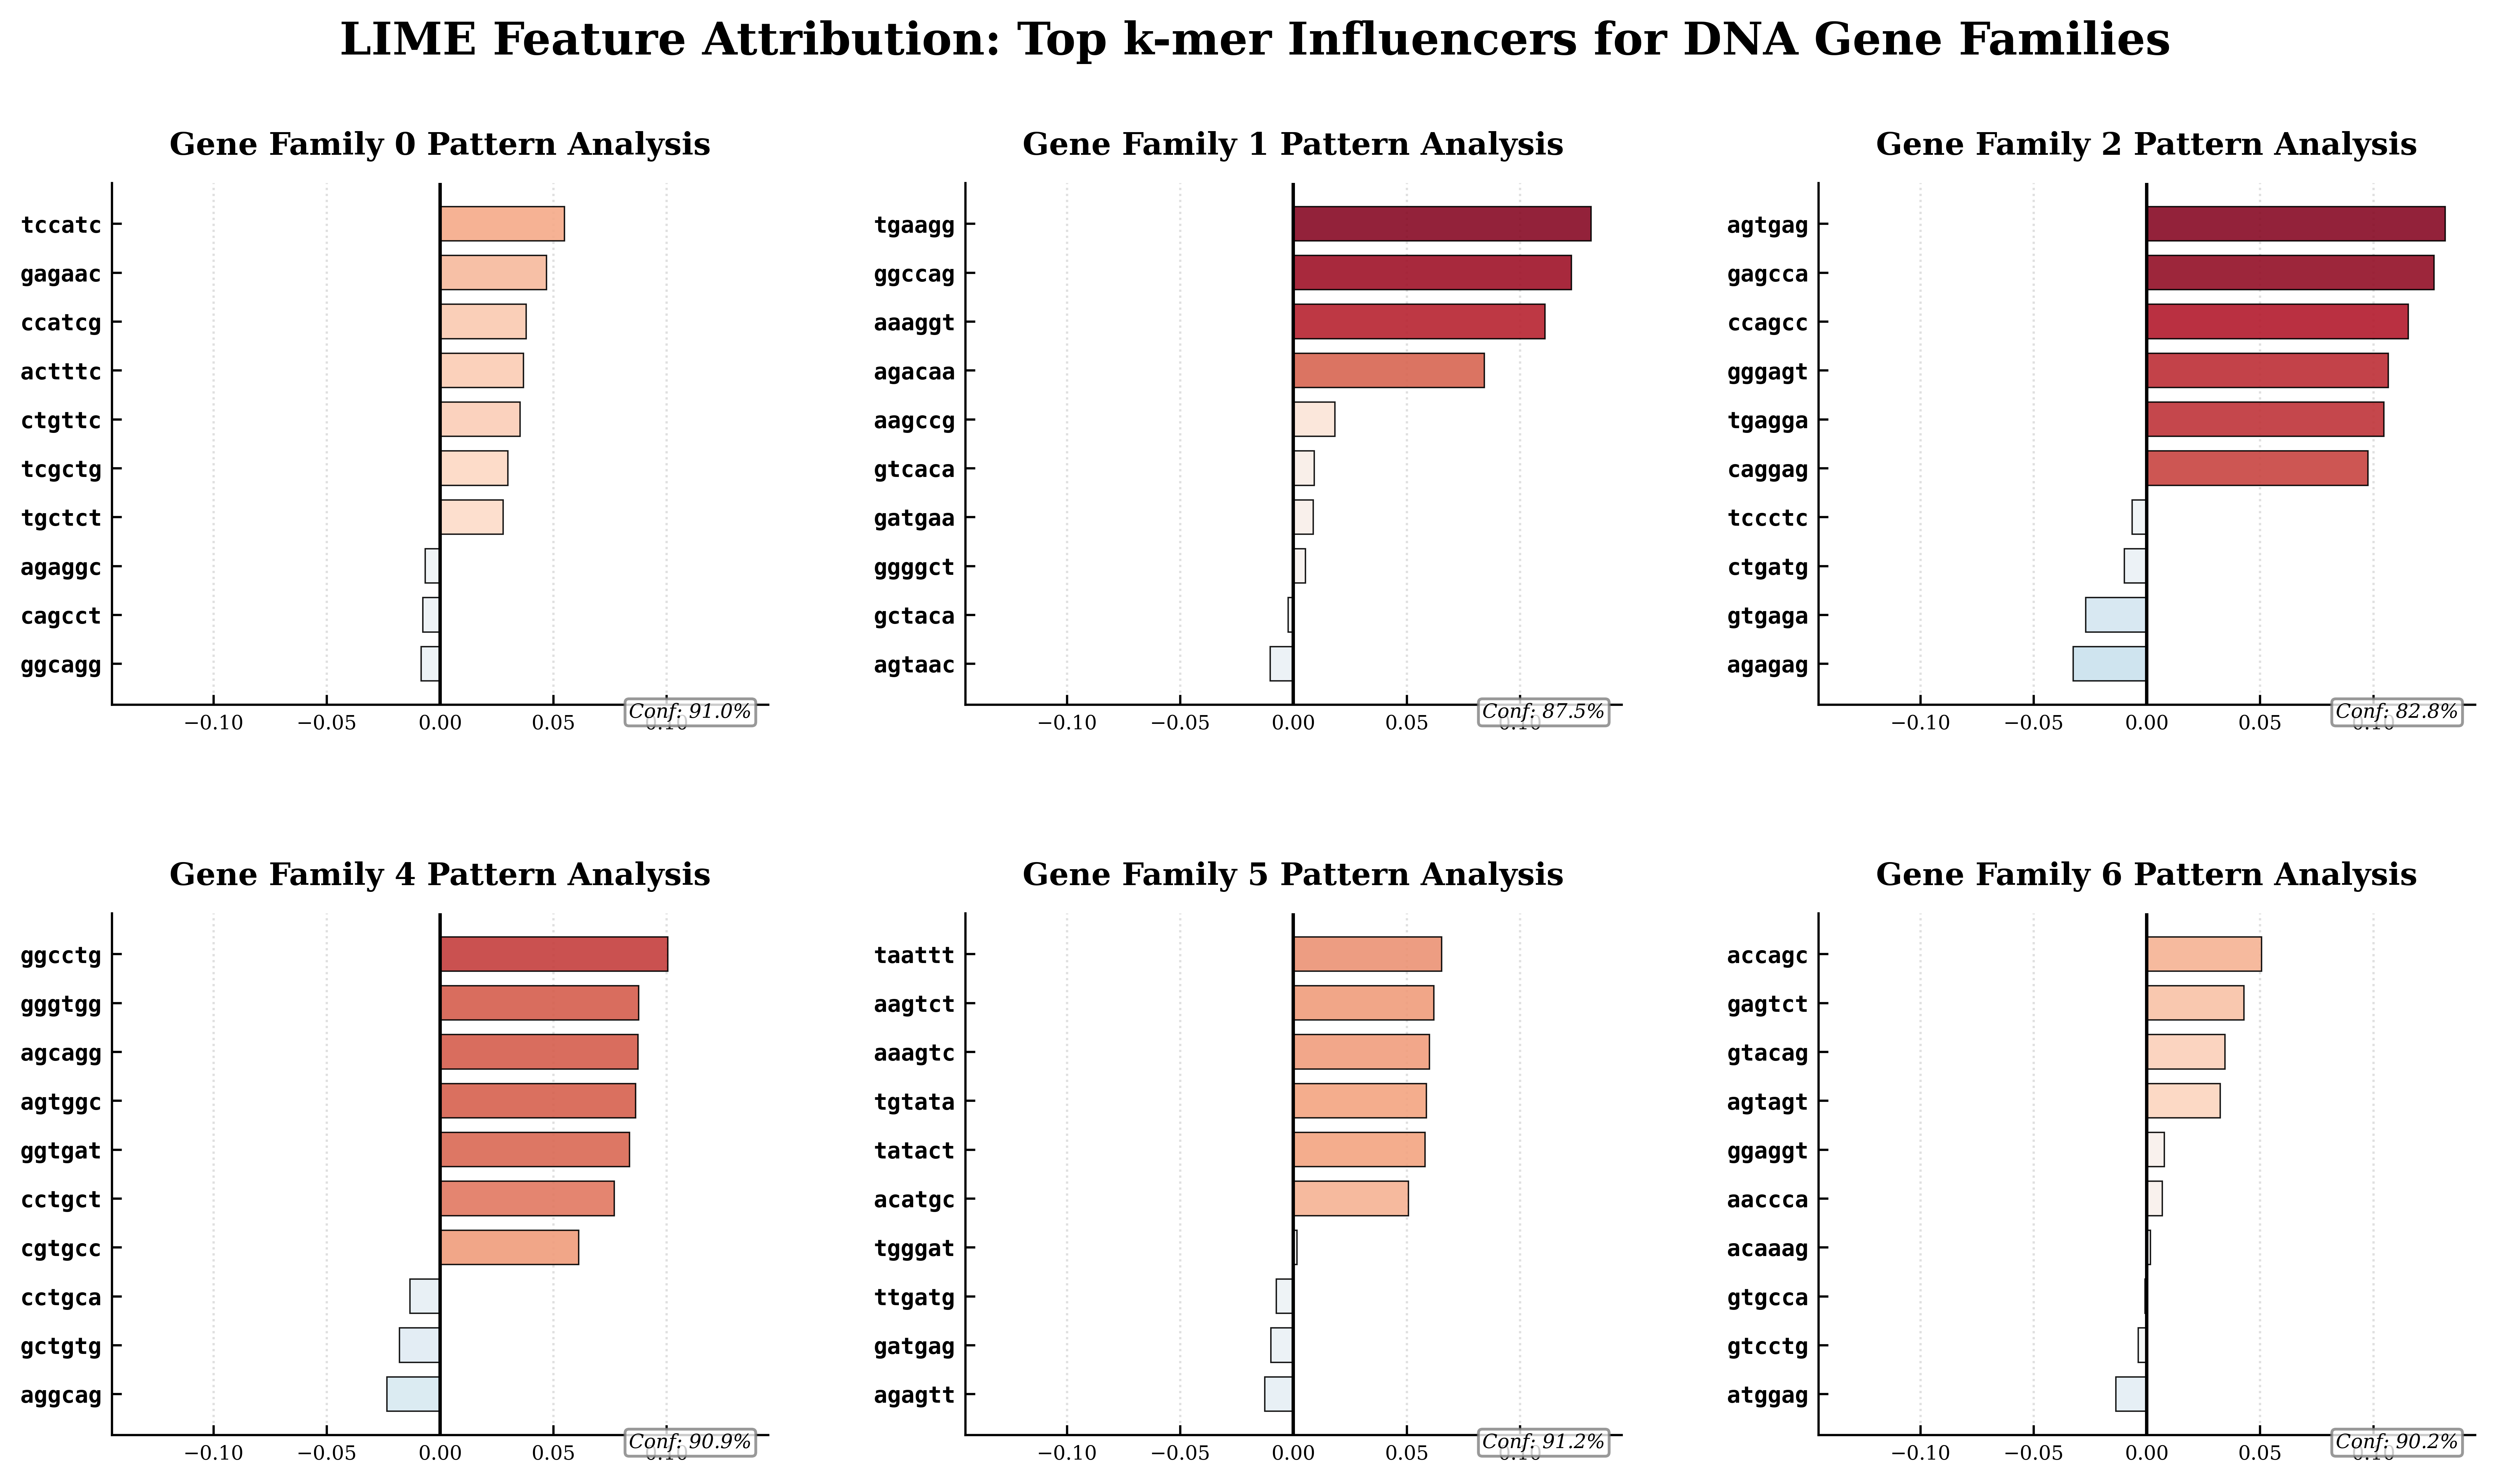

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Journal-Grade Style Configuration ───────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'savefig.dpi': 600
})

# ── Advanced Prediction Wrapper ─────────────────────────────────
def lime_predict(text_list):
    seqs = pad_sequences(tok.texts_to_sequences(text_list), maxlen=MAX_LEN, padding='post', truncating='post')
    return model.predict(seqs, verbose=0)

# ── Data Reconstruction ─────────────────────────────────────────
idx2word = {v: k for k, v in tok.word_index.items()}
X_te_strings = np.array([' '.join(idx2word[t] for t in row if t != 0) for row in X_te])

# ── Explanation Logic ───────────────────────────────────────────
explainer = LimeTextExplainer(class_names=[f'Class {i}' for i in range(NUM_CLASSES)], split_expression=r'\s+', bow=True, random_state=42)

y_pred_all = np.argmax(lime_predict(X_te_strings.tolist()), axis=1)
sample_indices = {cls: np.where((y_te == cls) & (y_pred_all == cls))[0][0] for cls in range(NUM_CLASSES) if len(np.where((y_te == cls) & (y_pred_all == cls))[0]) > 0}

# Generate Explanations
TOP_N = 10
explanations = {}
print("Generating Structured 2x3 LIME Explanations...")
for cls in [0, 1, 2, 4, 5, 6]:
    if cls in sample_indices:
        explanations[cls] = explainer.explain_instance(X_te_strings[sample_indices[cls]], lime_predict, labels=[cls], num_features=TOP_N, num_samples=2500)

# ── Final Visualization Orchestration (2 Rows x 3 Columns) ────────
fig = plt.figure(figsize=(15, 8))
fig.patch.set_facecolor('#FFFFFF')

# Define 2x3 grid
gs = gridspec.GridSpec(2, 3, wspace=0.3, hspace=0.4)

# Global normalization for scale consistency
max_w = max([max(abs(np.array([val for _, val in exp.as_list(label=c)]))) for c, exp in explanations.items()]) * 1.1

# Define placement mapping: Gene Family -> (row, col)
plot_map = {0: (0,0), 1: (0,1), 2: (0,2), 4: (1,0), 5: (1,1), 6: (1,2)}

for cls, (row, col) in plot_map.items():
    if cls not in explanations: continue

    ax = fig.add_subplot(gs[row, col])
    exp = explanations[cls]

    # Sort features by weight
    feat_weights = sorted(exp.as_list(label=cls), key=lambda x: x[1])
    kmers = [fw[0] for fw in feat_weights]
    weights = [fw[1] for fw in feat_weights]

    # Color logic: Support=Blue (RdBu_r), Contradict=Red
    norm = mcolors.TwoSlopeNorm(vmin=-max_w, vcenter=0, vmax=max_w)
    cmap = plt.get_cmap('RdBu_r')
    bar_colors = [cmap(norm(w)) for w in weights]

    bars = ax.barh(range(len(kmers)), weights, color=bar_colors, edgecolor='black', linewidth=0.5, height=0.7, alpha=0.9, zorder=3)

    ax.set_yticks(range(len(kmers)))
    ax.set_yticklabels(kmers, fontfamily='monospace', fontsize=8, fontweight='bold')
    ax.set_xlim(-max_w, max_w)
    ax.axvline(0, color='black', lw=1.2, zorder=4)
    ax.grid(axis='x', linestyle=':', alpha=0.4, zorder=0)

    # Confidence Badge
    conf = lime_predict([X_te_strings[sample_indices[cls]]])[0][cls]
    ax.set_title(f"Gene Family {cls} Pattern Analysis", fontsize=11, fontweight='bold', pad=10)
    ax.text(max_w*0.95, -0.8, f"Conf: {conf*100:.1f}%", ha='right', va='top', fontsize=7, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.2'))

# Master Title
fig.suptitle("LIME Feature Attribution: Top k-mer Influencers for DNA Gene Families", fontsize=16, fontweight='bold', y=0.98)

plt.savefig('NusraGenX_LIME_Rectangular.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
Cross-Species Testing — generalisation across held-out species

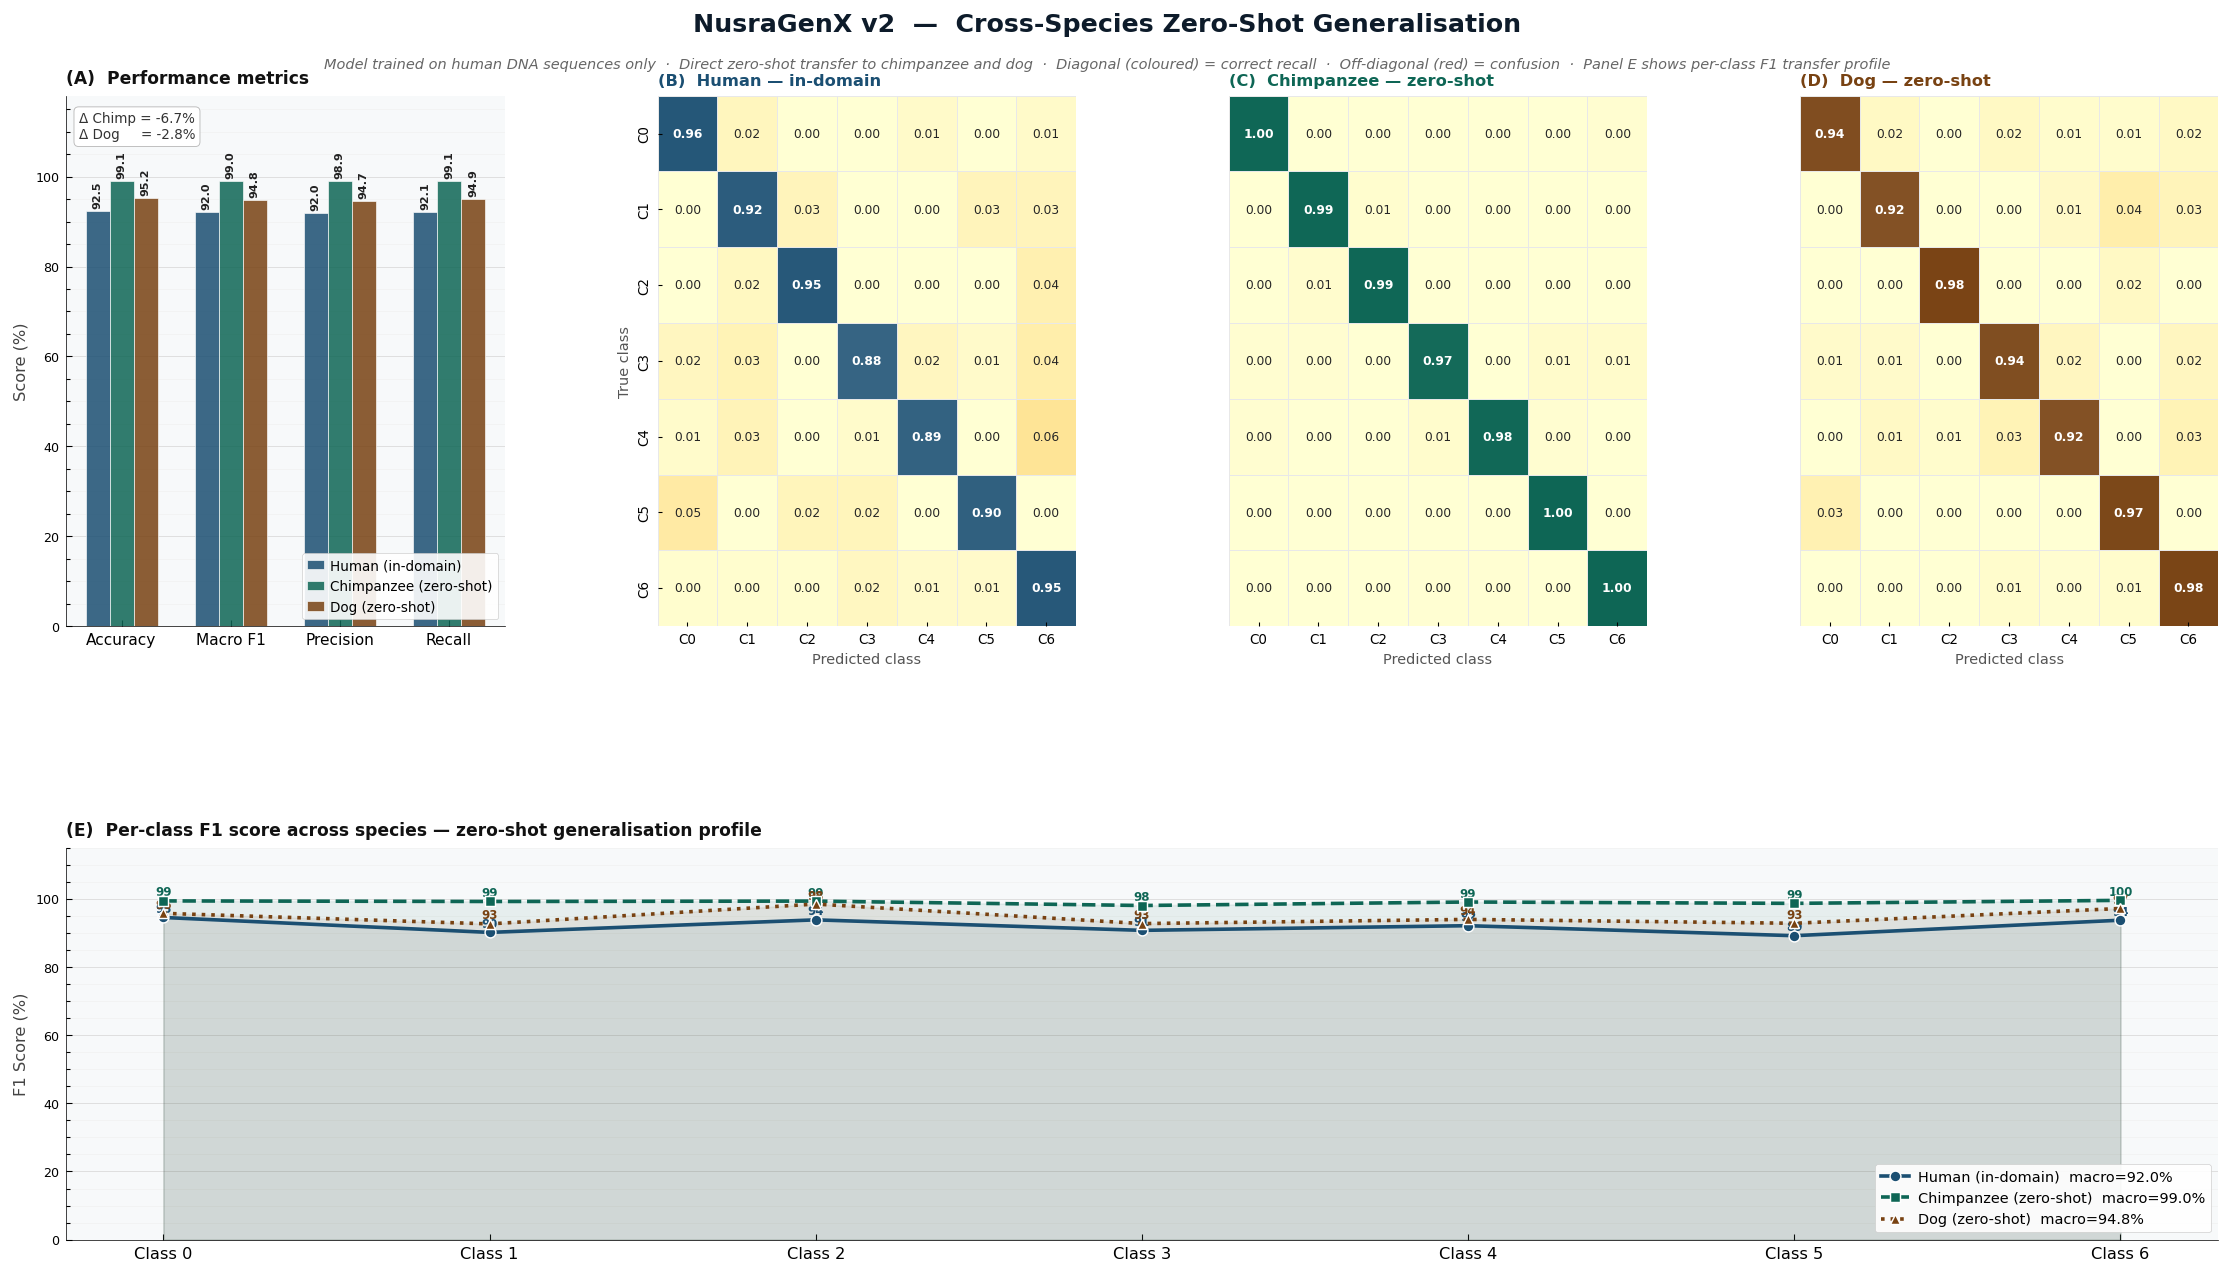

✅ Saved → cross_species_journal.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CROSS-SPECIES GENERALISATION — Premium Journal Figure
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.linewidth'    : 0.6,
    'xtick.major.width' : 0.6,
    'ytick.major.width' : 0.6,
    'xtick.direction'   : 'in',
    'ytick.direction'   : 'in',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'savefig.dpi'       : 600,
    'figure.dpi'        : 130,
})

# ── Palette ─────────────────────────────────────────────────────
C_HU  = '#1B4F72'
C_CH  = '#0E6655'
C_DO  = '#784212'
COLS  = [C_HU, C_CH, C_DO]
BG    = '#FFFFFF'
PANEL = '#F7F9FA'
cls_lbls = [f'C{i}' for i in range(NUM_CLASSES)]

# ── Encode & Predict ────────────────────────────────────────────
def encode(df):
    s = pad_sequences(tok.texts_to_sequences(df['words'].values),
                      maxlen=MAX_LEN, padding='post', truncating='post')
    return s, df['class'].values

X_ch, y_ch = encode(chimp_df)
X_do, y_do = encode(dog_df)

def full_metrics(X, y):
    p    = model.predict(X, verbose=0)
    pred = np.argmax(p, axis=1)
    return dict(
        pred = pred,
        acc  = np.mean(pred == y) * 100,
        f1   = f1_score(y, pred, average='macro') * 100,
        prec = precision_score(y, pred, average='macro', zero_division=0) * 100,
        rec  = recall_score(y, pred, average='macro', zero_division=0) * 100,
        cm   = confusion_matrix(y, pred)
    )

hu = full_metrics(X_te,  y_te)
ch = full_metrics(X_ch,  y_ch)
do = full_metrics(X_do,  y_do)

species_data = [
    ('Human',       'in-domain',  hu, C_HU),
    ('Chimpanzee',  'zero-shot',  ch, C_CH),
    ('Dog',         'zero-shot',  do, C_DO),
]

metrics_keys   = ['acc', 'f1', 'prec', 'rec']
metrics_labels = ['Accuracy', 'Macro F1', 'Precision', 'Recall']

# ═══════════════════════════════════════════════════════════════
# FIGURE LAYOUT
#   Row 0 : [metric bars] [cm_human] [cm_chimp] [cm_dog]
#   Row 1 : [per-class F1 lines spanning all 4 cols]
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(BG)

gs = gridspec.GridSpec(
    2, 4,
    height_ratios = [1.15, 0.85],
    width_ratios  = [1.05, 1, 1, 1],
    hspace = 0.48, wspace = 0.36,
    left=0.055, right=0.975, top=0.885, bottom=0.085
)

# ────────────────────────────────────────────────────────────────
# PANEL A — Grouped metric bars
# ────────────────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor(PANEL)
for spine in ax_a.spines.values():
    spine.set_linewidth(0.4)

n_met  = len(metrics_keys)
x      = np.arange(n_met)
width  = 0.22
offsets= [-width, 0, width]

for (name, tag, mdict, col), off in zip(species_data, offsets):
    vals = [mdict[k] for k in metrics_keys]
    bars = ax_a.bar(x + off, vals, width,
                    color=col, alpha=0.85,
                    edgecolor='white', linewidth=0.4,
                    zorder=3, label=f'{name} ({tag})')
    for bar, v in zip(bars, vals):
        ax_a.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.6,
                  f'{v:.1f}', ha='center', va='bottom',
                  fontsize=6.2, fontweight='bold', color='#222',
                  rotation=90)

ax_a.set_xticks(x)
ax_a.set_xticklabels(metrics_labels, fontsize=8.5)
ax_a.set_ylabel('Score (%)', fontsize=9, color='#444', labelpad=4)
ax_a.set_ylim(0, 118)
ax_a.yaxis.set_minor_locator(MultipleLocator(5))
ax_a.grid(axis='y', which='major', color='#DDDDDD',
          linewidth=0.5, zorder=0)
ax_a.grid(axis='y', which='minor', color='#EEEEEE',
          linewidth=0.3, zorder=0)
ax_a.set_title('(A)  Performance metrics', fontsize=9.5,
               fontweight='bold', color='#111', pad=7, loc='left')

leg = ax_a.legend(fontsize=7.5, frameon=True, framealpha=0.9,
                  edgecolor='#CCCCCC', loc='lower right',
                  handlelength=1.2, handletextpad=0.5)
leg.get_frame().set_linewidth(0.4)

# Δ gap text box
gap_ch = hu['acc'] - ch['acc']
gap_do = hu['acc'] - do['acc']
ax_a.text(0.03, 0.97,
          f'Δ Chimp = {gap_ch:+.1f}%\nΔ Dog     = {gap_do:+.1f}%',
          transform=ax_a.transAxes, va='top', ha='left',
          fontsize=7.5, color='#333',
          bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                    edgecolor='#BBBBBB', linewidth=0.5))

# ────────────────────────────────────────────────────────────────
# PANELS B / C / D — Confusion matrices
# ────────────────────────────────────────────────────────────────
cm_titles = ['(B)  Human — in-domain',
             '(C)  Chimpanzee — zero-shot',
             '(D)  Dog — zero-shot']

for col_idx, (name, tag, mdict, color) in enumerate(species_data):
    ax = fig.add_subplot(gs[0, col_idx + 1])

    cm_n = mdict['cm'].astype(float)
    cm_n = cm_n / cm_n.sum(axis=1, keepdims=True)

    mask_diag = np.eye(NUM_CLASSES, dtype=bool)

    # off-diagonal heatmap
    sns.heatmap(cm_n, ax=ax,
                mask=mask_diag,
                cmap='YlOrRd', vmin=0, vmax=0.3,
                annot=True, fmt='.2f', annot_kws={'size': 6.8},
                linewidths=0.35, linecolor='#E8E8E8',
                cbar=False, alpha=0.85,
                xticklabels=cls_lbls,
                yticklabels=cls_lbls if col_idx == 0 else [])

    # diagonal overlay — species color
    diag_cmap = mcolors.LinearSegmentedColormap.from_list(
        'diag', ['#FFFFFF', color])
    sns.heatmap(cm_n, ax=ax,
                mask=~mask_diag,
                cmap=diag_cmap, vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 6.8,
                                                   'fontweight': 'bold',
                                                   'color': 'white'},
                linewidths=0.35, linecolor='#E8E8E8',
                cbar=False,
                xticklabels=cls_lbls,
                yticklabels=cls_lbls if col_idx == 0 else [])

    ax.set_title(cm_titles[col_idx], fontsize=9,
                 fontweight='bold', color=color, pad=6, loc='left')
    ax.set_xlabel('Predicted class', fontsize=8, color='#555', labelpad=3)
    if col_idx == 0:
        ax.set_ylabel('True class', fontsize=8, color='#555', labelpad=3)
    ax.tick_params(labelsize=7.5, length=2)

# ────────────────────────────────────────────────────────────────
# PANEL E — Per-class F1 across species (line plot, full width)
# ────────────────────────────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, :])
ax_e.set_facecolor(PANEL)
for spine in ax_e.spines.values():
    spine.set_linewidth(0.4)

x_cls = np.arange(NUM_CLASSES)
marks = ['o', 's', '^']
lines_style = ['-', '--', ':']

for (name, tag, mdict, col), mk, ls in zip(species_data, marks, lines_style):
    f1_per = f1_score(
        y_te  if name == 'Human' else
        y_ch  if name == 'Chimpanzee' else y_do,
        mdict['pred'], average=None, zero_division=0
    ) * 100

    ax_e.plot(x_cls, f1_per, color=col, lw=2.0,
              linestyle=ls, marker=mk, markersize=6,
              markeredgecolor='white', markeredgewidth=0.8,
              label=f'{name} ({tag})  macro={mdict["f1"]:.1f}%',
              zorder=4)
    ax_e.fill_between(x_cls, f1_per, alpha=0.07, color=col, zorder=2)

    # annotate each point
    for xi, fi in enumerate(f1_per):
        ax_e.text(xi, fi + 1.5, f'{fi:.0f}',
                  ha='center', fontsize=6.5, color=col, fontweight='bold')

ax_e.set_xticks(x_cls)
ax_e.set_xticklabels([f'Class {i}' for i in range(NUM_CLASSES)], fontsize=9)
ax_e.set_ylabel('F1 Score (%)', fontsize=9, color='#444', labelpad=4)
ax_e.set_ylim(0, 115)
ax_e.yaxis.set_minor_locator(MultipleLocator(5))
ax_e.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.5, zorder=0)
ax_e.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.3, zorder=0)
ax_e.set_title('(E)  Per-class F1 score across species — zero-shot generalisation profile',
               fontsize=9.5, fontweight='bold', color='#111', pad=7, loc='left')

leg_e = ax_e.legend(fontsize=8, frameon=True, framealpha=0.9,
                    edgecolor='#CCCCCC', loc='lower right',
                    handlelength=2.0, handletextpad=0.6)
leg_e.get_frame().set_linewidth(0.4)

# ── Figure-level title & subtitle ───────────────────────────────
fig.text(0.5, 0.930,
         'NusraGenX v2  —  Cross-Species Zero-Shot Generalisation',
         ha='center', fontsize=14, fontweight='bold', color='#0D1B2A')

fig.text(0.5, 0.904,
         'Model trained on human DNA sequences only  ·  '
         'Direct zero-shot transfer to chimpanzee and dog  ·  '
         'Diagonal (coloured) = correct recall  ·  Off-diagonal (red) = confusion  ·  '
         'Panel E shows per-class F1 transfer profile',
         ha='center', fontsize=8, color='#666666', style='italic')

plt.savefig('cross_species_journal.png',
            dpi=600, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Saved → cross_species_journal.png')

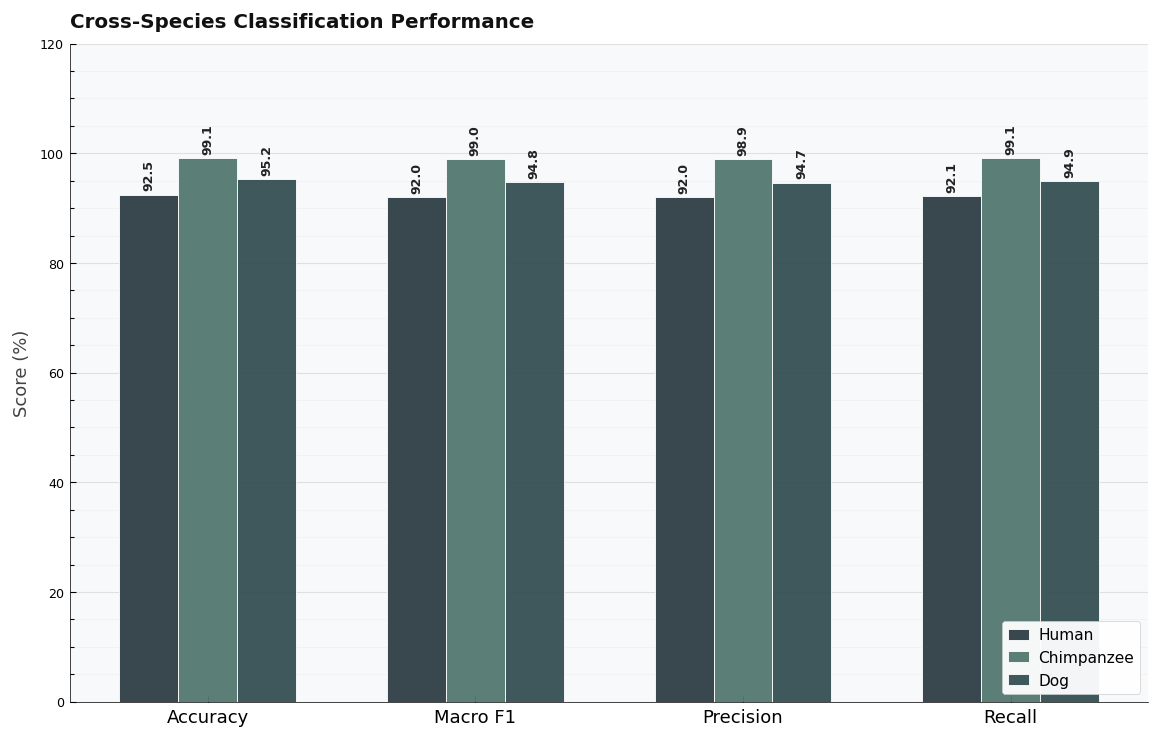

 Fig 1 saved → fig1_metrics_bar.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CROSS-SPECIES — FIGURE 1 : Performance Metrics Bar Chart
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':'DejaVu Sans','axes.linewidth':0.7,
    'xtick.direction':'in','ytick.direction':'in',
    'axes.spines.top':False,'axes.spines.right':False,
    'savefig.dpi':600,'figure.dpi':130,
})

# ── Formal Academic Color Palette ───────────────────────────────
C_HU = '#2F3E46'
C_CH = '#52796F'
C_DO = '#354F52'

BG = '#FFFFFF'
PANEL = '#F8F9FA'

cls_lbls=[f'C{i}' for i in range(NUM_CLASSES)]

# ── Encode ──────────────────────────────────────────────────────
def encode(df):
    s = pad_sequences(tok.texts_to_sequences(df['words'].values),
                      maxlen=MAX_LEN, padding='post', truncating='post')
    return s, df['class'].values

X_ch,y_ch = encode(chimp_df)
X_do,y_do = encode(dog_df)

def full_metrics(X,y):
    p=model.predict(X,verbose=0)
    pred=np.argmax(p,axis=1)
    return dict(
        pred=pred,
        acc=np.mean(pred==y)*100,
        f1=f1_score(y,pred,average='macro')*100,
        prec=precision_score(y,pred,average='macro',zero_division=0)*100,
        rec=recall_score(y,pred,average='macro',zero_division=0)*100,
        cm=confusion_matrix(y,pred)
    )

hu=full_metrics(X_te,y_te)
ch=full_metrics(X_ch,y_ch)
do=full_metrics(X_do,y_do)

species_data=[
    ('Human',hu,C_HU),
    ('Chimpanzee',ch,C_CH),
    ('Dog',do,C_DO)
]

metrics_keys  =['acc','f1','prec','rec']
metrics_labels=['Accuracy','Macro F1','Precision','Recall']

# ── Figure 1 ────────────────────────────────────────────────────
fig1,ax=plt.subplots(figsize=(9,6))
fig1.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

for sp in ax.spines.values():
    sp.set_linewidth(0.4)

x=np.arange(len(metrics_keys))
width=0.22
offsets=[-width,0,width]

for (name,mdict,col),off in zip(species_data,offsets):
    vals=[mdict[k] for k in metrics_keys]
    bars=ax.bar(x+off,vals,width,color=col,alpha=0.95,
                edgecolor='white',linewidth=0.5,zorder=3,
                label=name)

    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.7,f'{v:.1f}',
                ha='center',va='bottom',fontsize=7,
                fontweight='bold',color='#222',rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels,fontsize=10)
ax.set_ylabel('Score (%)',fontsize=10,color='#444',labelpad=5)
ax.set_ylim(0,120)

ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.grid(axis='y',which='major',color='#E0E0E0',lw=0.6,zorder=0)
ax.grid(axis='y',which='minor',color='#F0F0F0',lw=0.4,zorder=0)

ax.set_title('Cross-Species Classification Performance',
             fontsize=11,fontweight='bold',color='#111',pad=9,loc='left')

leg=ax.legend(fontsize=8.5,frameon=True,framealpha=0.95,
              edgecolor='#CCCCCC',loc='lower right',
              handlelength=1.4,handletextpad=0.6)
leg.get_frame().set_linewidth(0.4)

plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig('fig1_metrics_bar.png',dpi=600,bbox_inches='tight',facecolor=BG)
plt.show()

print(' Fig 1 saved → fig1_metrics_bar.png')


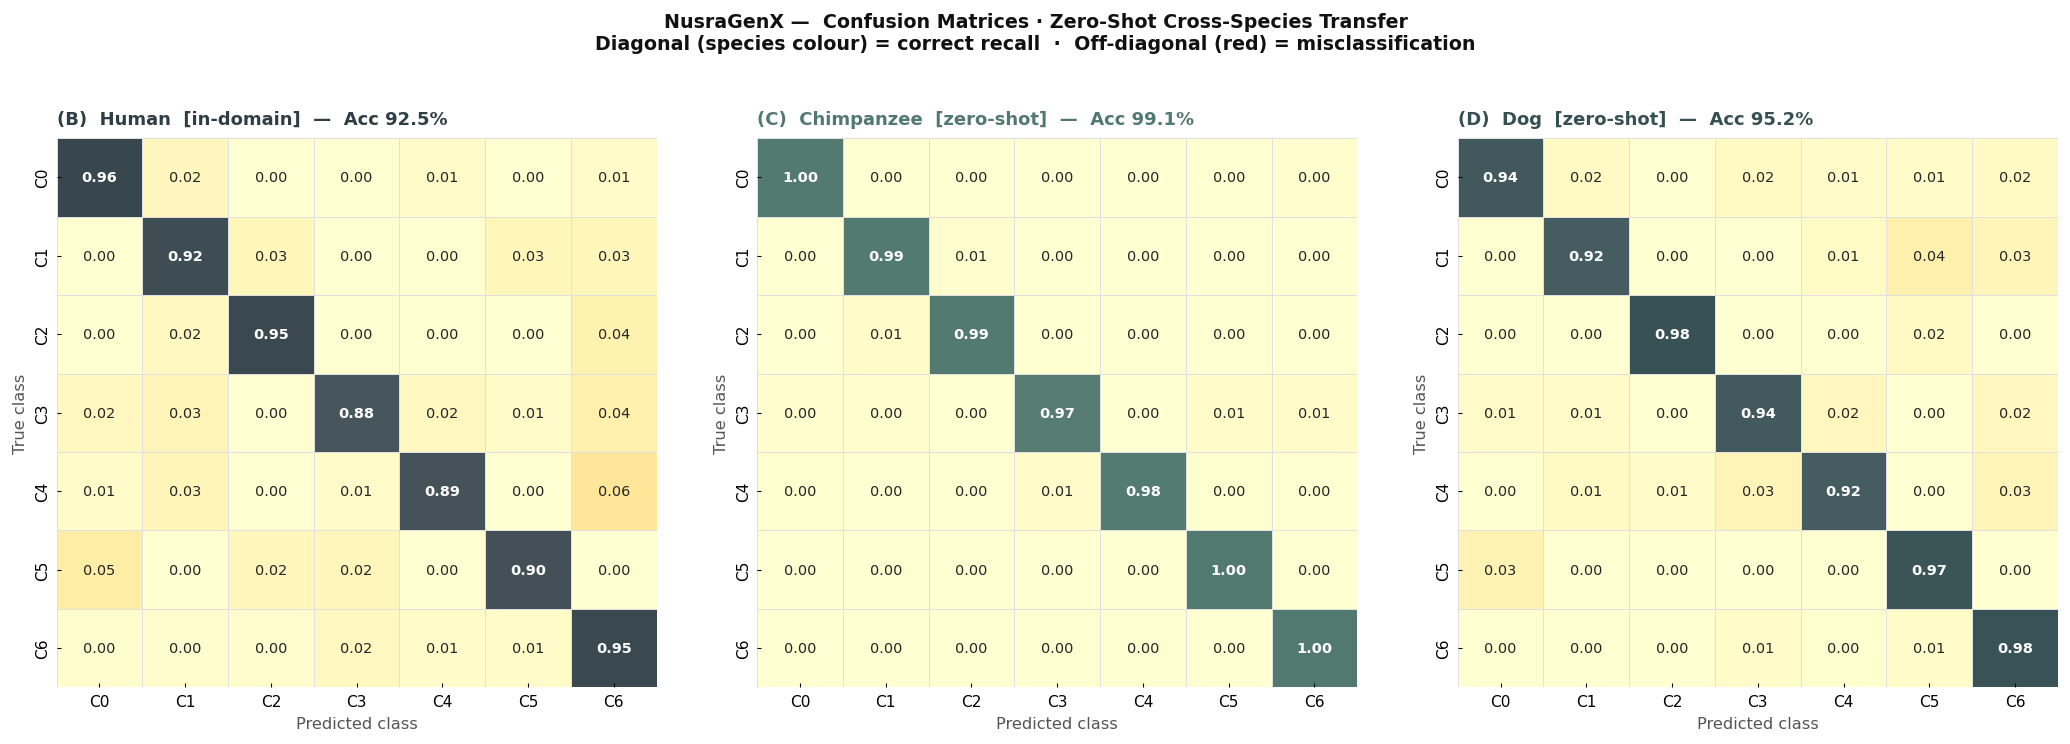

 Fig 2 saved → fig2_confusion_matrices.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 2 : Confusion Matrices — side by side, dual-layer style
# ═══════════════════════════════════════════════════════════════
fig2,axes=plt.subplots(1,3,figsize=(16,5.5))
fig2.patch.set_facecolor(BG)

cm_meta=[('Human','in-domain',hu,C_HU,'B'),
         ('Chimpanzee','zero-shot',ch,C_CH,'C'),
         ('Dog','zero-shot',do,C_DO,'D')]

for ax,(name,tag,mdict,color,lbl) in zip(axes,cm_meta):
    cm_n=mdict['cm'].astype(float)
    cm_n=cm_n/cm_n.sum(axis=1,keepdims=True)
    mask_diag=np.eye(NUM_CLASSES,dtype=bool)

    # off-diagonal — red scale
    sns.heatmap(cm_n,ax=ax,mask=mask_diag,
                cmap='YlOrRd',vmin=0,vmax=0.35,
                annot=True,fmt='.2f',annot_kws={'size':8},
                linewidths=0.4,linecolor='#E0E0E0',
                cbar=False,alpha=0.9,
                xticklabels=cls_lbls,yticklabels=cls_lbls)

    # diagonal — species color
    dcmap=mcolors.LinearSegmentedColormap.from_list('d',['#FFFFFF',color])
    sns.heatmap(cm_n,ax=ax,mask=~mask_diag,
                cmap=dcmap,vmin=0,vmax=1,
                annot=True,fmt='.2f',
                annot_kws={'size':8,'fontweight':'bold','color':'white'},
                linewidths=0.4,linecolor='#E0E0E0',
                cbar=False,
                xticklabels=cls_lbls,yticklabels=cls_lbls)

    ax.set_title(f'({lbl})  {name}  [{tag}]  —  Acc {mdict["acc"]:.1f}%',
                 fontsize=10,fontweight='bold',color=color,pad=8,loc='left')
    ax.set_xlabel('Predicted class',fontsize=9,color='#555',labelpad=4)
    ax.set_ylabel('True class',fontsize=9,color='#555',labelpad=4)
    ax.tick_params(labelsize=8.5,length=2)

fig2.suptitle(
    'NusraGenX —  Confusion Matrices · Zero-Shot Cross-Species Transfer\n'
    'Diagonal (species colour) = correct recall  ·  Off-diagonal (red) = misclassification',
    fontsize=10.5,fontweight='bold',color='#111',y=1.03)

plt.tight_layout(w_pad=3.5)
plt.savefig('fig2_confusion_matrices.png',dpi=600,bbox_inches='tight',facecolor=BG)
plt.show()
print(' Fig 2 saved → fig2_confusion_matrices.png')

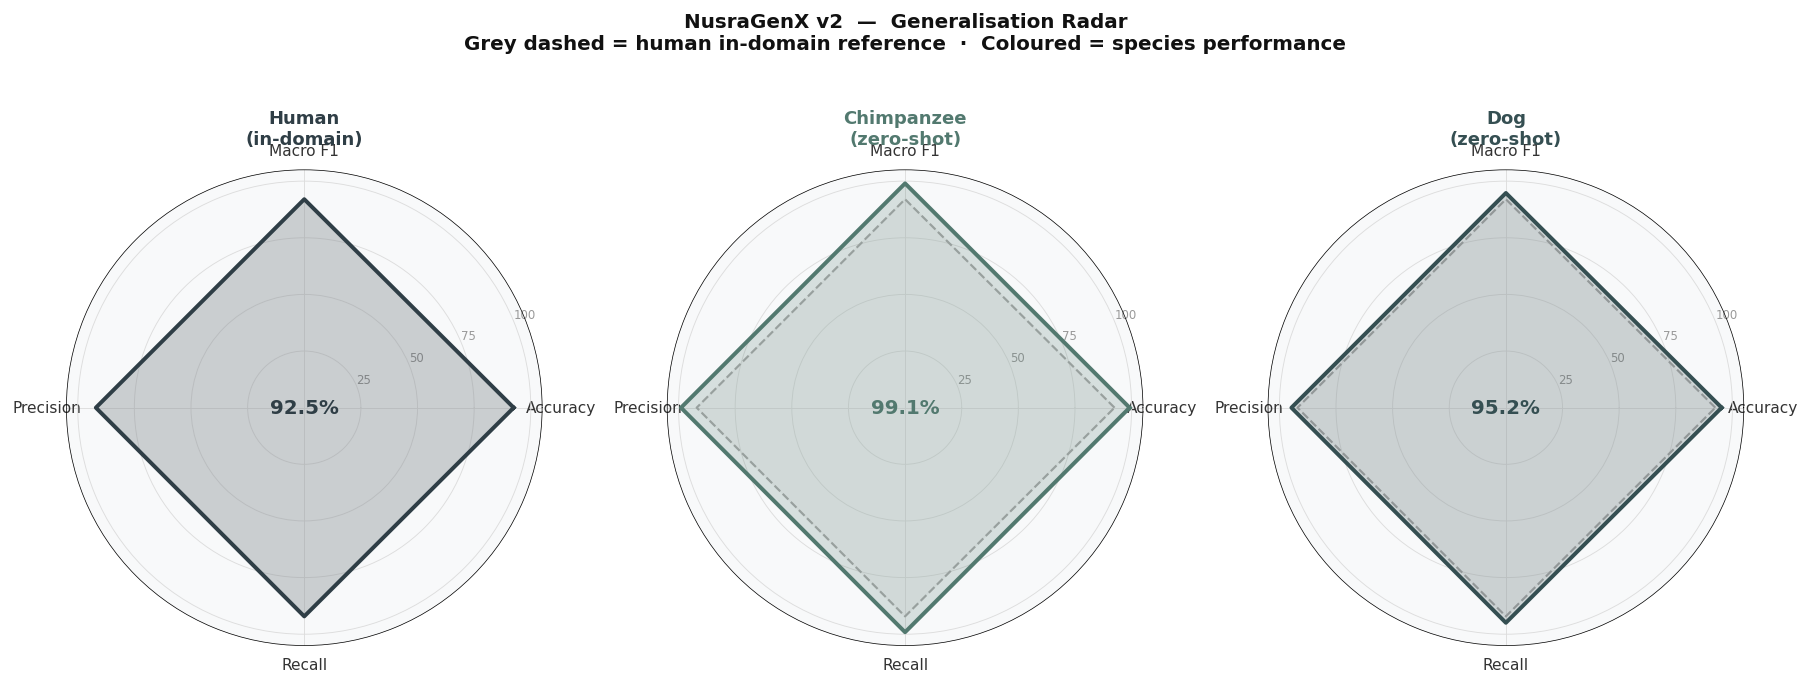

Fig 4 saved → fig4_radar.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 4 : Generalisation Gap Radar
# ═══════════════════════════════════════════════════════════════
from matplotlib.patches import FancyBboxPatch

metric_lbls_rad=['Accuracy','Macro F1','Precision','Recall']
angles=np.linspace(0,2*np.pi,len(metric_lbls_rad),endpoint=False).tolist()
angles+=angles[:1]

fig4,axes4=plt.subplots(1,3,figsize=(14,5),
                         subplot_kw=dict(polar=True))
fig4.patch.set_facecolor(BG)

# Mapping tags since they aren't in the species_data tuple
tags = {'Human': 'in-domain', 'Chimpanzee': 'zero-shot', 'Dog': 'zero-shot'}

for ax,(name,mdict,col) in zip(axes4,species_data):
    tag = tags.get(name, 'zero-shot')
    vals=[mdict[k] for k in metrics_keys]+[mdict[metrics_keys[0]]]
    hu_vals=[hu[k] for k in metrics_keys]+[hu[metrics_keys[0]]]

    # human reference (grey)
    ax.plot(angles,hu_vals,color='#AAAAAA',lw=1.2,ls='--',zorder=2)
    ax.fill(angles,hu_vals,color='#AAAAAA',alpha=0.08,zorder=1)

    # species
    ax.plot(angles,vals,color=col,lw=2.2,zorder=4)
    ax.fill(angles,vals,color=col,alpha=0.20,zorder=3)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_lbls_rad,fontsize=8.5,color='#333')
    ax.set_ylim(0,105)
    ax.set_yticks([25,50,75,100])
    ax.set_yticklabels(['25','50','75','100'],fontsize=6.5,color='#999')
    ax.grid(color='#DDDDDD',lw=0.5)
    ax.spines['polar'].set_linewidth(0.4)
    ax.set_facecolor(PANEL)

    ax.set_title(f'{name}\n({tag})',fontsize=10,fontweight='bold',
                 color=col,pad=14)

    # acc badge
    ax.text(0,0,f'{mdict["acc"]:.1f}%',ha='center',va='center',
            fontsize=11,fontweight='bold',color=col,transform=ax.transData)

fig4.suptitle(
    'NusraGenX v2  —  Generalisation Radar\n'
    'Grey dashed = human in-domain reference  ·  Coloured = species performance',
    fontsize=11,fontweight='bold',color='#111',y=1.05)

plt.tight_layout()
plt.savefig('fig4_radar.png',dpi=600,bbox_inches='tight',facecolor=BG)
plt.show()
print('Fig 4 saved → fig4_radar.png')